# Final Project – Identifying Learner Personas from Platform Usage


## 1. Project Description
This project aims to analyze interaction data from a digital learning platform (Lernnavi) to uncover patterns in student engagement and behavior over time. By processing event-level data such as session frequency, timing, and duration, we seek to go beyond surface-level usage and model deeper behavioral tendencies.

The ultimate goal is to group students into distinct learner profiles (or personas), which can help inform personalized educational strategies and improve platform design.

We focus on temporal and interaction-based features that reflect how, when, and how regularly students engage with the learning platform. These data-driven insights can support better understanding of student needs and engagement patterns.

## 2. Research Questions

1. **What distinct learning behaviors can be identified based on platform usage and time-based interaction patterns?**
2. **How do students’ learning behaviors evolve over time, and can we identify common trajectories among different learner types?**
3. **What can be said on future performances of a student based on his/her current actions**


In [10]:
%load_ext autoreload
%autoreload 2

In [11]:
# Import the tables of the data set as dataframes.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import HDBSCAN
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
import seaborn as sns
import colorcet as cc
import gc
import pickle
from utils.memory_usage import see_memory_usage
from functools import reduce
from tslearn.metrics import cdist_dtw
from scipy.stats import linregress
from utils.clustering_eval_utils import evaluate_model
from utils.clustering import *
from utils.feature_processing import *

DATA_DIR = './data/Lernnavi' # You may change the directory

## 3. Preprocessing


### 3.1 Data Segmentation into Time Windows


In [12]:
users = pd.read_csv('{}/users.csv.gz'.format(DATA_DIR))
events = pd.read_csv('{}/events.csv.gz'.format(DATA_DIR))
transactions = pd.read_csv('{}/transactions.csv.gz'.format(DATA_DIR))

In [13]:
events['action'].value_counts()


action
PAGE_VISIT              2113982
REVIEW_TASK             1734632
SUBMIT_ANSWER           1404142
NAVIGATE_DASHBOARD      1093791
NEXT                     907521
WINDOW_VISIBLE_FALSE     851634
WINDOW_VISIBLE_TRUE      705679
VIEW_QUESTION            451981
OPEN_FEEDBACK            281632
CLOSE_FEEDBACK           251044
GO_TO_THEORY             211418
SUBMIT_SEARCH            162067
VIEW_SESSION_END         159925
SKIP                     158420
WINDOW_OPEN              150781
CLOSE                    131124
WINDOW_CLOSE             122121
LOGIN                    105144
SURVEY_BANNER             68655
SELECT_STATISTICS         57119
ACCEPT_PROGRESS           30996
GO_TO_COMMENTS            12158
GO_TO_BUG_REPORT           9772
LOGOUT                     6821
SHARE_SESSION              3320
REJECT_PROGRESS            3257
PRETEST                    1709
NAVIGATE_SURVEY            1111
GO_TO_SESSION               563
REQUEST_HINT                562
SHARE                        90
N

To focus on meaningful engagement, we filter the events table to retain only actions that reflect actual learning behavior. These include starting tasks (`REVIEW_TASK`), submitting answers (`SUBMIT_ANSWER`), progressing between tasks (`NEXT`, `SKIP`), reviewing results (`OPEN_FEEDBACK`), and accessing theory content (`GO_TO_THEORY`). This selection removes passive or technical events like page visits or tab visibility changes, which do not contribute to behavioral modeling.


In [14]:
# Define relevant learning-related actions
relevant_actions = [
    "REVIEW_TASK",
    "SUBMIT_ANSWER",
    "NEXT",
    "SKIP",
    "OPEN_FEEDBACK",
    "GO_TO_THEORY"
]

# Filter the events table to keep only these
filtered_events = events[events['action'].isin(relevant_actions)].copy()

In [15]:
# Convert timestamp to weekly buckets
filtered_events['event_date'] = pd.to_datetime(filtered_events['event_date'], errors='coerce')
filtered_events['week'] = filtered_events['event_date'].dt.isocalendar().week
filtered_events['year'] = filtered_events['event_date'].dt.isocalendar().year

# Combine year + week to ensure correct ordering across years
filtered_events['year_week'] = filtered_events['event_date'].dt.strftime('%Y-%U')

# Preview: group activity per user-week
weekly_activity = (
    filtered_events.groupby(['user_id', 'year_week'])
    .agg(
        session_count=('session_id', 'nunique'),
        action_count=('event_id', 'count'),
        unique_actions=('action', 'nunique')
    )
    .reset_index()
)

weekly_activity.head()

,user_id,year_week,session_count,action_count,unique_actions
0,387604,2021-26,2,7,1
1,387604,2021-33,1,19,2
2,387604,2021-34,0,50,1
3,387604,2021-35,3,146,4
4,387604,2021-36,2,30,2


#### Merging Transactions Data

We enrich the events with outcome data from the `transactions` table by merging on the `transaction_token`. This allows us to compute weekly metrics like correctness ratio and average task duration, providing a more complete picture of each student's engagement.

#### Weekly Aggregation of Learning Behavior

We group each user's learning events into weekly buckets to extract temporal patterns. For each user-week, we compute summary statistics including the number of sessions, actions, unique activity types, average task duration, and answer correctness. These features provide a compact, time-aligned representation of engagement behavior over time.


In [16]:
# Ensure datetime in transactions
transactions['start_time'] = pd.to_datetime(transactions['start_time'], errors='coerce')
transactions['commit_time'] = pd.to_datetime(transactions['commit_time'], errors='coerce')

# Compute task duration in seconds
transactions['task_duration'] = (transactions['commit_time'] - transactions['start_time']).dt.total_seconds()

# Clean invalid rows
transactions = transactions.dropna(subset=['transaction_token', 'evaluation', 'task_duration'])

# Merge events with transactions
events_tx = filtered_events.merge(
    transactions[['transaction_token', 'evaluation', 'task_duration']],
    on='transaction_token',
    how='left'
)

# Drop events without evaluation (no meaningful outcome)
events_tx = events_tx.dropna(subset=['evaluation'])

# Regenerate year_week if needed
events_tx['year_week'] = events_tx['event_date'].dt.strftime('%Y-%U')

# Weekly aggregation (basic features)
weekly_activity = (
    events_tx.groupby(['user_id', 'year_week']).agg(
        session_count=('session_id', 'nunique'),
        action_count=('event_id', 'count'),
        unique_actions=('action', 'nunique'),
        avg_task_duration=('task_duration', 'mean'),
        correct_ratio=('evaluation', lambda x: (x == 'CORRECT').sum() / x.count())
    )
    .reset_index()
)

# Add skip ratio
skip_ratio = (
    events_tx.assign(skip=(events_tx['action'] == 'SKIP').astype(int))
    .groupby(['user_id', 'year_week'])
    .agg(skip_count=('skip', 'sum'),
         total_actions=('event_id', 'count'))
    .assign(skip_ratio=lambda df: df['skip_count'] / df['total_actions'])
    .reset_index()
)

# Add go_to_theory ratio
go_theory_ratio = (
    events_tx.assign(theory=(events_tx['action'] == 'GO_TO_THEORY').astype(int))
    .groupby(['user_id', 'year_week'])
    .agg(theory_count=('theory', 'sum'),
         total_actions=('event_id', 'count'))
    .assign(go_theory_ratio=lambda df: df['theory_count'] / df['total_actions'])
    .reset_index()
)

# Merge new ratios
weekly_activity = weekly_activity.merge(skip_ratio[['user_id', 'year_week', 'skip_ratio']],
                                        on=['user_id', 'year_week'], how='left')
weekly_activity = weekly_activity.merge(go_theory_ratio[['user_id', 'year_week', 'go_theory_ratio']],
                                        on=['user_id', 'year_week'], how='left')

# Final preview
weekly_activity.head()


,user_id,year_week,session_count,action_count,unique_actions,avg_task_duration,correct_ratio,skip_ratio,go_theory_ratio
0,387604,2021-35,1,2,2,16.5440,0.0,0.0,0.0
1,387604,2021-38,0,8,2,14.5365,0.0,0.0,0.0
2,387604,2021-39,0,4,2,14.6480,0.5,0.0,0.0
3,387604,2021-40,0,2,2,10.0670,0.0,0.0,0.0
4,387604,2021-42,0,2,2,27.1630,0.0,0.0,0.0


#### Sequence Transformation (Wide Format)

We convert the long-format weekly table into wide-format sequences, where each row represents a user and each column corresponds to a specific week. This transformation aligns all users along a common timeline, enabling time-series modeling using DTW, LSTM, or classical ML approaches.

In [17]:
# Filter users with at least N weeks of activity
min_weeks = 5
valid_users = weekly_activity['user_id'].value_counts()
valid_users = valid_users[valid_users >= min_weeks].index
weekly_filtered = weekly_activity[weekly_activity['user_id'].isin(valid_users)]

# Pivot to wide format for 'action_count'
action_seq = weekly_filtered.pivot(index='user_id', columns='year_week', values='action_count')

# Fill missing weeks with 0
action_seq = action_seq.fillna(0)

# Sort weeks chronologically
action_seq = action_seq.reindex(sorted(action_seq.columns), axis=1)

# Preview
action_seq.head()


year_week,2021-20,2021-21,2021-22,2021-23,2021-24,2021-25,2021-26,2021-27,2021-28,2021-29,...,2022-49,2022-50,2022-51,2022-52,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06
user_id,,,,,,,,,,,,,,,,,,,,,
387604,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,34.0,0.0,0.0,0.0
387605,0.0,6.0,0.0,0.0,2.0,0.0,0.0,43.0,24.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
387608,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
387643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,88.0,0.0,0.0,0.0,0.0,37.0,0.0,0.0,0.0
387644,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,136.0,0.0


In [18]:
# feature_list now includes 6 features
features = ['action_count', 'correct_ratio', 'avg_task_duration',
                'skip_ratio', 'go_theory_ratio']
seq_dict = {}

for feat in features:
    df = weekly_activity.pivot(index='user_id', columns='year_week', values=feat).fillna(0)
    df = df.reindex(sorted(df.columns), axis=1)
    seq_dict[feat] = df


users = list(seq_dict[features[0]].index)
sequence_tensor = np.stack([seq_dict[feat].loc[users].values for feat in features], axis=-1)


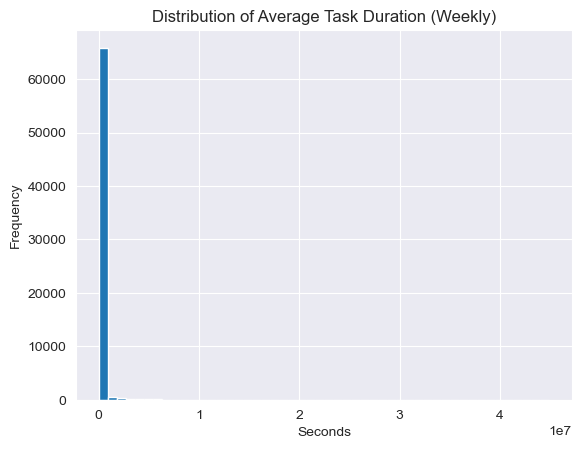

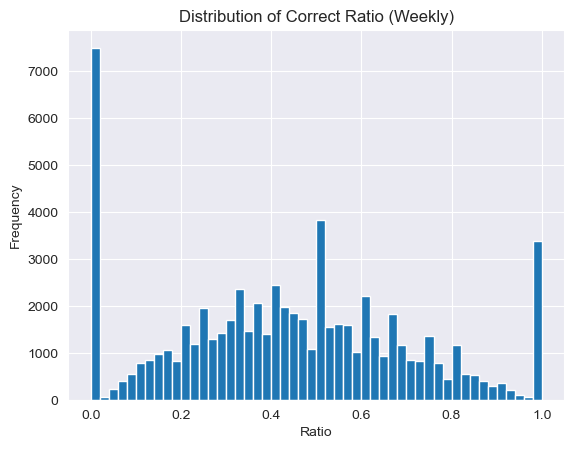

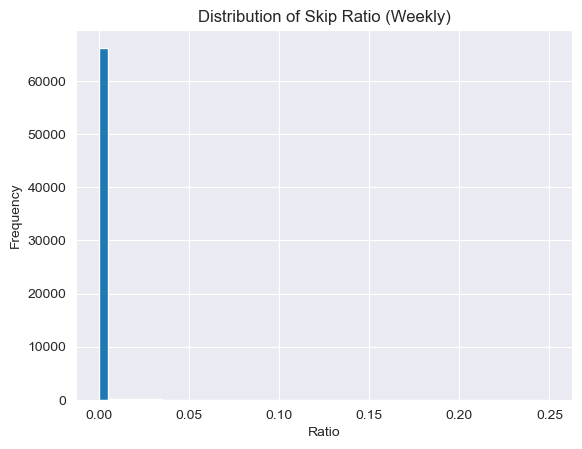

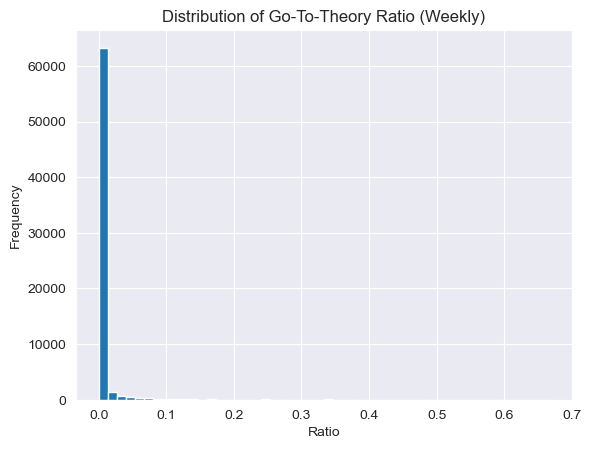

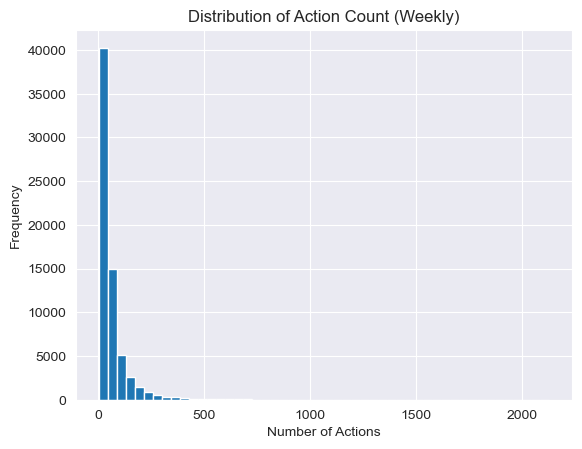

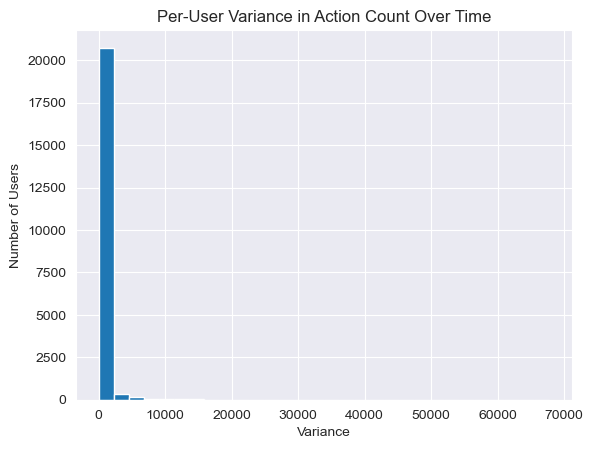

In [19]:
import matplotlib.pyplot as plt

# Plot: avg_task_duration
weekly_activity['avg_task_duration'].hist(bins=50)
plt.title("Distribution of Average Task Duration (Weekly)")
plt.xlabel("Seconds")
plt.ylabel("Frequency")
plt.show()

# Plot: correct_ratio
weekly_activity['correct_ratio'].hist(bins=50)
plt.title("Distribution of Correct Ratio (Weekly)")
plt.xlabel("Ratio")
plt.ylabel("Frequency")
plt.show()

# Plot: skip_ratio
weekly_activity['skip_ratio'].hist(bins=50)
plt.title("Distribution of Skip Ratio (Weekly)")
plt.xlabel("Ratio")
plt.ylabel("Frequency")
plt.show()

# Plot: go_to_theory_ratio
weekly_activity['go_theory_ratio'].hist(bins=50)
plt.title("Distribution of Go-To-Theory Ratio (Weekly)")
plt.xlabel("Ratio")
plt.ylabel("Frequency")
plt.show()

# Plot: action_count
weekly_activity['action_count'].hist(bins=50)
plt.title("Distribution of Action Count (Weekly)")
plt.xlabel("Number of Actions")
plt.ylabel("Frequency")
plt.show()

# Check per-user variance in action count over time
action_seq = weekly_activity.pivot(index='user_id', columns='year_week', values='action_count').fillna(0)
action_var = action_seq.var(axis=1)
action_var.hist(bins=30)
plt.title("Per-User Variance in Action Count Over Time")
plt.xlabel("Variance")
plt.ylabel("Number of Users")
plt.show()


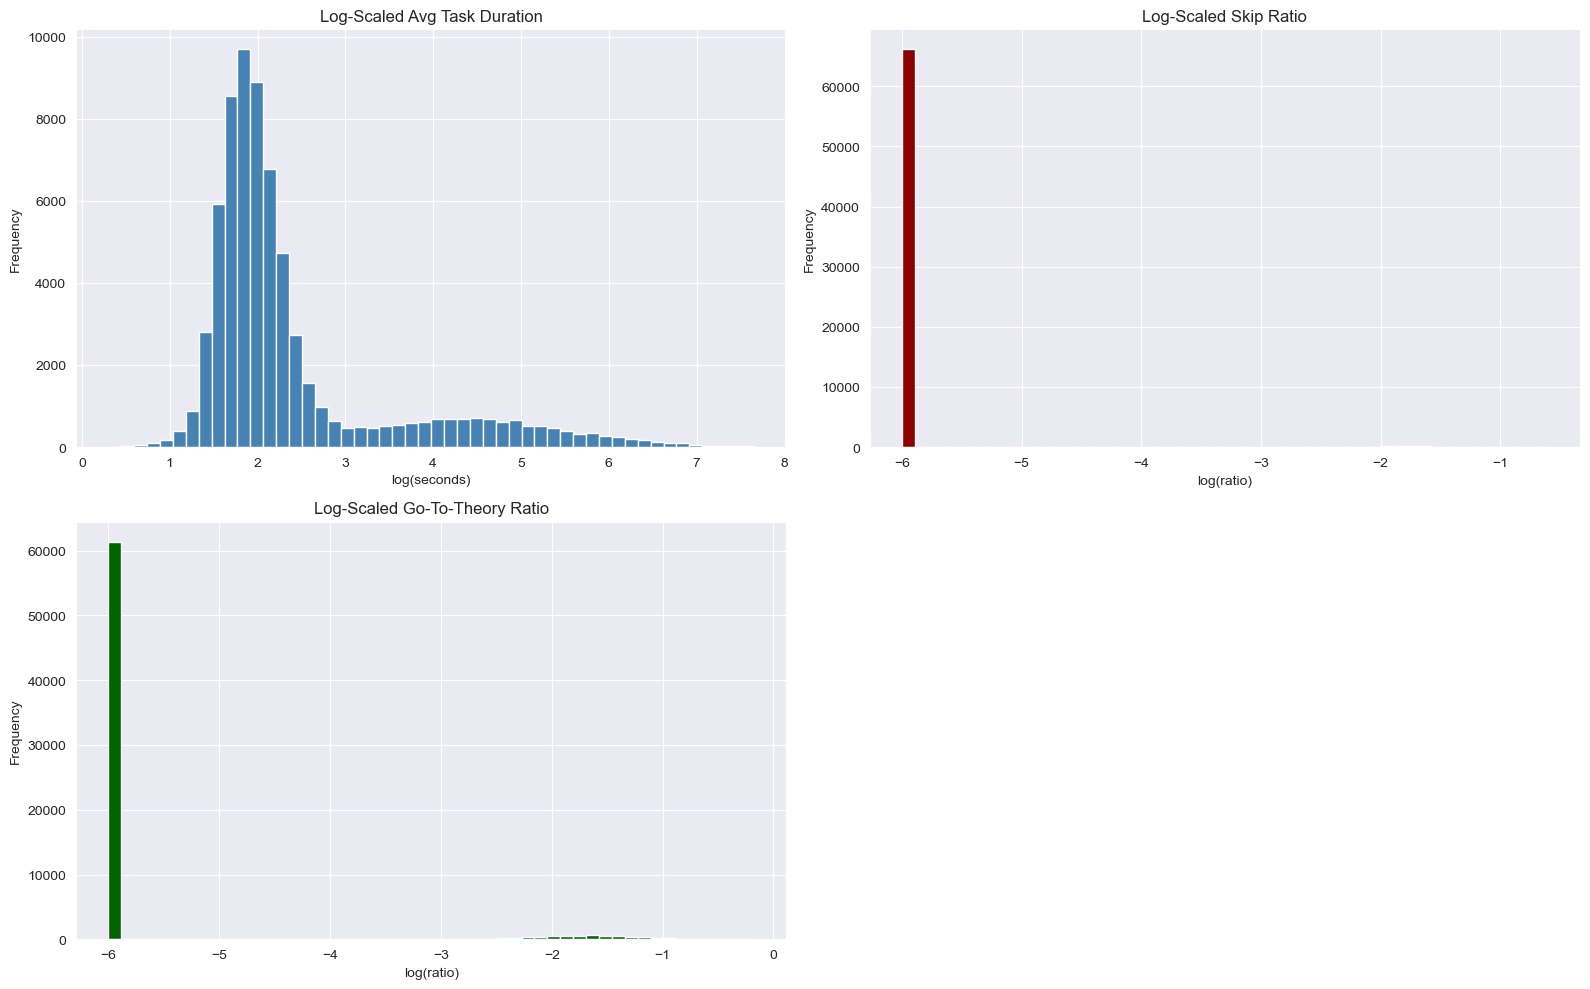

In [20]:

# Helper: safely apply log with small constant to avoid log(0)
def safe_log(x):
    return np.log10(x + 1e-6)

plt.figure(figsize=(16, 10))

# Avg task duration
plt.subplot(2, 2, 1)
plt.hist(safe_log(weekly_activity['avg_task_duration'].dropna()), bins=50, color='steelblue')
plt.title("Log-Scaled Avg Task Duration")
plt.xlabel("log(seconds)")
plt.ylabel("Frequency")

# Skip ratio
plt.subplot(2, 2, 2)
plt.hist(safe_log(weekly_activity['skip_ratio'].dropna()), bins=50, color='darkred')
plt.title("Log-Scaled Skip Ratio")
plt.xlabel("log(ratio)")
plt.ylabel("Frequency")

# Go-to-theory ratio
plt.subplot(2, 2, 3)
plt.hist(safe_log(weekly_activity['go_theory_ratio'].dropna()), bins=50, color='darkgreen')
plt.title("Log-Scaled Go-To-Theory Ratio")
plt.xlabel("log(ratio)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


#### Outlier Handling and Sequence Quality Filtering

We observed extreme values in task duration and low behavioral variance in many user sequences. To ensure robust modeling, we cap average task durations and remove users with flat sequences that offer little temporal signal.

In [21]:
# Cap task durations at 1 hour (3600 seconds)
weekly_activity['avg_task_duration'] = weekly_activity['avg_task_duration'].clip(upper=3600)

# Pivot action_count again after cleaning
action_seq = weekly_activity.pivot(index='user_id', columns='year_week', values='action_count').fillna(0)
action_seq = action_seq.fillna(0)
action_seq = action_seq.reindex(sorted(action_seq.columns), axis=1)

# Compute per-user variance
user_variance = action_seq.var(axis=1)

# Filter users with variance > threshold (e.g., 5 actions)
min_var = 5
valid_users = user_variance[user_variance > min_var].index
action_seq = action_seq.loc[valid_users]


### 3.2 Feature Engineering (RQ1)

### Session-based Features

#### Step 1 — Session-level features

In [22]:
# Example for session features
df_events = events.copy()
df_events['event_date'] = pd.to_datetime(df_events['event_date'])

In [23]:
session_features = df_events.groupby(['user_id', 'session_id']).agg(
    num_events_in_session=('event_date', 'count'),
    session_duration_min=('event_date', lambda x: (x.max() - x.min()).total_seconds() / 60),
    session_closed=('session_closed', 'max'),  # should be 0 or 1
    session_accepted=('session_accepted', 'max'),
    unique_topics_in_session=('topic_id', 'nunique')
).reset_index()

#### Step 2 — User-level aggregations from session_features


In [24]:
user_session_features = session_features.groupby('user_id').agg(
    total_sessions=('session_id', 'nunique'),
    total_num_events=('num_events_in_session', 'sum'),
    avg_session_duration_min=('session_duration_min', 'mean'),
    median_session_duration_min=('session_duration_min', 'median'),
    std_session_duration_min=('session_duration_min', 'std'),
    max_session_duration_min=('session_duration_min', 'max'),
    min_session_duration_min=('session_duration_min', 'min'),
    avg_num_events_per_session=('num_events_in_session', 'mean'),
    avg_unique_topics_per_session=('unique_topics_in_session', 'mean'),
    pct_sessions_closed=('session_closed', 'mean'),
    pct_sessions_accepted=('session_accepted', 'mean')
).reset_index()

#### Step 3 — Time between sessions

In [25]:
# Sort by user and session start
session_features = session_features.sort_values(['user_id', 'session_id'])  # we need to know time order
df_events['event_date'] = pd.to_datetime(df_events['event_date'])

# Calculate session start date
session_starts = df_events.groupby(['user_id', 'session_id'])['event_date'].min().reset_index()
session_starts = session_starts.sort_values(['user_id', 'event_date'])

# Calculate time differences
session_starts['time_since_last_session_hr'] = session_starts.groupby('user_id')['event_date'].diff().dt.total_seconds() / 3600

# Aggregate per user
temporal_features = session_starts.groupby('user_id').agg(
    avg_time_between_sessions_hr=('time_since_last_session_hr', 'mean'),
    std_time_between_sessions_hr=('time_since_last_session_hr', 'std'),
    max_inactivity_period_hr=('time_since_last_session_hr', 'max')
).reset_index()

#### Step 4 — Active days & average sessions per active day

In [26]:
df_events['event_date_only'] = df_events['event_date'].dt.date
days_active = df_events.groupby('user_id')['event_date_only'].nunique().reset_index(name='days_active')

# Sessions per day
sessions_per_day = session_starts.copy()
sessions_per_day['session_day'] = sessions_per_day['event_date'].dt.date
sessions_per_day = sessions_per_day.groupby(['user_id', 'session_day']).size().reset_index(name='sessions_per_day')
avg_sessions_per_active_day = sessions_per_day.groupby('user_id')['sessions_per_day'].mean().reset_index(name='avg_sessions_per_active_day')

#### Step 5 — Final merge: Session Features

In [27]:
final_session_features = user_session_features \
    .merge(temporal_features, on='user_id', how='left') \
    .merge(days_active, on='user_id', how='left') \
    .merge(avg_sessions_per_active_day, on='user_id', how='left')

In [28]:
final_session_features

,user_id,total_sessions,total_num_events,avg_session_duration_min,median_session_duration_min,std_session_duration_min,max_session_duration_min,min_session_duration_min,avg_num_events_per_session,avg_unique_topics_per_session,pct_sessions_closed,pct_sessions_accepted,avg_time_between_sessions_hr,std_time_between_sessions_hr,max_inactivity_period_hr,days_active,avg_sessions_per_active_day
0,387604,61,1105,12963.096278,1.331083,64843.133625,492921.146800,0.000000,18.114754,0.918033,0.982143,0.826087,229.595889,425.555724,1676.341603,100,2.103448
1,387605,67,742,29595.661530,3.315933,98793.615011,531286.253133,0.000000,11.074627,0.955224,0.984375,1.000000,187.273808,464.944778,3120.276084,54,2.913043
2,387608,31,469,11904.947317,3.627667,40661.940478,217246.262683,0.000000,15.129032,0.548387,1.000000,1.000000,407.203174,787.446374,3049.412006,87,2.214286
3,387613,4,31,1.019733,0.923208,0.581060,1.766600,0.465917,7.750000,1.000000,0.750000,1.000000,439.497068,548.218223,1053.816563,5,1.333333
4,387615,2,48,9.675450,9.675450,0.642996,10.130117,9.220783,24.000000,1.000000,1.000000,1.000000,0.172846,NaN,0.172846,12,2.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19625,431999,4,21,4.107954,2.271158,4.881144,11.189883,0.699617,5.250000,1.000000,0.750000,NaN,0.084585,0.091561,0.190299,1,4.000000
19626,432001,1,7,13.184783,13.184783,NaN,13.184783,13.184783,7.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,1,1.000000
19627,432014,2,25,7.975892,7.975892,4.141560,10.904417,5.047367,12.500000,1.000000,1.000000,1.000000,0.092280,NaN,0.092280,1,2.000000
19628,432016,2,4,0.564775,0.564775,0.644304,1.020367,0.109183,2.000000,1.000000,0.500000,NaN,0.006462,NaN,0.006462,1,2.000000


In [29]:
# Step 1: Fill standard deviation and time-based NaNs with 0
std_cols = ['std_time_between_sessions_hr', 'std_session_duration_min']
time_cols = ['avg_time_between_sessions_hr', 'max_inactivity_period_hr']

final_session_features[std_cols + time_cols] = final_session_features[std_cols + time_cols].fillna(0)

# Step 2: Fill acceptance ratio with 0 (means no acceptance events)
final_session_features['pct_sessions_accepted'] = final_session_features['pct_sessions_accepted'].fillna(0)

# Step 3: Fill pct_sessions_closed with median (only 3 missing values)
final_session_features['pct_sessions_closed'] = final_session_features['pct_sessions_closed'].fillna(final_session_features['pct_sessions_closed'].median())

# Step 4: Double check
print(final_session_features.isnull().sum())

user_id                          0
total_sessions                   0
total_num_events                 0
avg_session_duration_min         0
median_session_duration_min      0
std_session_duration_min         0
max_session_duration_min         0
min_session_duration_min         0
avg_num_events_per_session       0
avg_unique_topics_per_session    0
pct_sessions_closed              0
pct_sessions_accepted            0
avg_time_between_sessions_hr     0
std_time_between_sessions_hr     0
max_inactivity_period_hr         0
days_active                      0
avg_sessions_per_active_day      0
dtype: int64


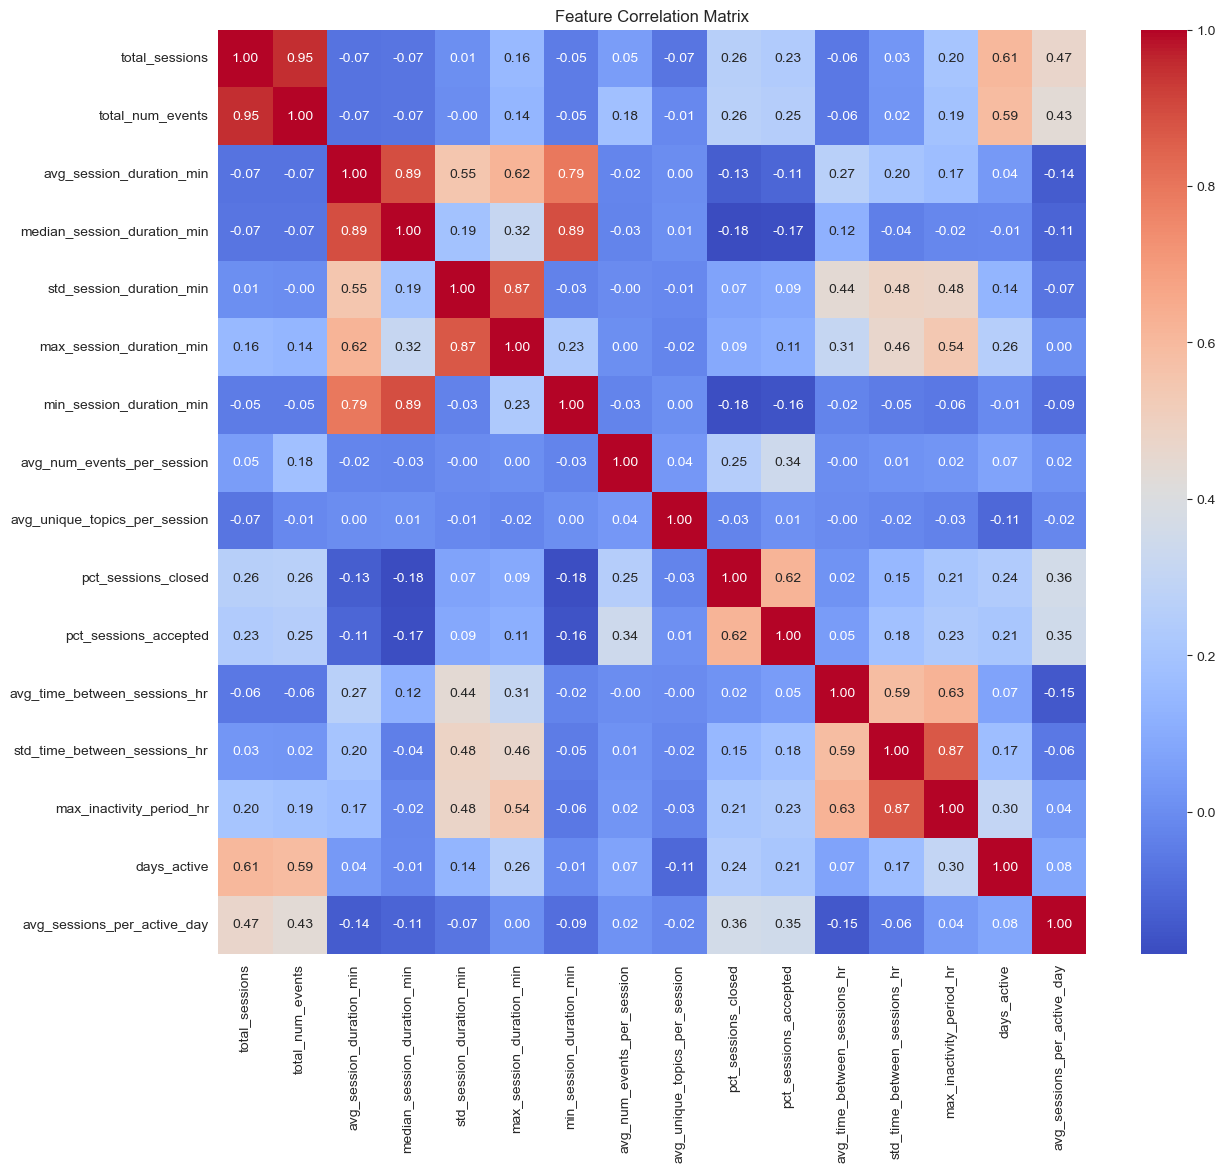

In [30]:
# Drop user_id (keep it somewhere safe if you need to track students later)
X = final_session_features.drop(columns=['user_id'])

# Correlation matrix
plt.figure(figsize=(14,12))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

## Correlation Analysis of Session-Based Features

To ensure we avoid redundancy in the feature space and maintain meaningful dimensions for clustering, we performed a correlation analysis on the session-based features.

Key observations:
- **total_sessions** and **total_num_events** were highly correlated (0.95). We decided to keep **total_sessions** (more interpretable) and drop **total_num_events**.
- **median_session_duration_min** and **max_session_duration_min** were highly correlated (0.89). We kept **median_session_duration_min** (more robust to outliers).
- **avg_time_between_sessions_hr** and **max_inactivity_period_hr** were also highly correlated (0.86). We chose to retain **avg_time_between_sessions_hr** to better capture regularity.

Other features showed moderate or low correlation and were retained to preserve richness in behavioral descriptions.

After pruning, we kept a diverse, minimally redundant set of features. Scaling will be applied next before moving to dimensionality reduction and clustering.

In [31]:
# 1. Drop user_id to work only with features
X = final_session_features.drop(columns=['user_id'])

# 2. Drop highly correlated features
X = X.drop(columns=[
    'total_num_events',          # because of high correlation with total_sessions
    'max_session_duration_min',  # because of high correlation with median session duration
    'max_inactivity_period_hr'    # because of high correlation with avg_time_between_sessions
])

# 3. Attach back user_id if needed (useful to track students after clustering)
final_session_features_clean = pd.concat([final_session_features[['user_id']], X], axis=1)

# 4. Quick check
final_session_features_clean.head()

,user_id,total_sessions,avg_session_duration_min,median_session_duration_min,std_session_duration_min,min_session_duration_min,avg_num_events_per_session,avg_unique_topics_per_session,pct_sessions_closed,pct_sessions_accepted,avg_time_between_sessions_hr,std_time_between_sessions_hr,days_active,avg_sessions_per_active_day
0,387604,61,12963.096278,1.331083,64843.133625,0.000000,18.114754,0.918033,0.982143,0.826087,229.595889,425.555724,100,2.103448
1,387605,67,29595.661530,3.315933,98793.615011,0.000000,11.074627,0.955224,0.984375,1.000000,187.273808,464.944778,54,2.913043
2,387608,31,11904.947317,3.627667,40661.940478,0.000000,15.129032,0.548387,1.000000,1.000000,407.203174,787.446374,87,2.214286
3,387613,4,1.019733,0.923208,0.581060,0.465917,7.750000,1.000000,0.750000,1.000000,439.497068,548.218223,5,1.333333
4,387615,2,9.675450,9.675450,0.642996,9.220783,24.000000,1.000000,1.000000,1.000000,0.172846,0.000000,12,2.000000


In [32]:
final_session_features.columns

Index(['user_id', 'total_sessions', 'total_num_events',
       'avg_session_duration_min', 'median_session_duration_min',
       'std_session_duration_min', 'max_session_duration_min',
       'min_session_duration_min', 'avg_num_events_per_session',
       'avg_unique_topics_per_session', 'pct_sessions_closed',
       'pct_sessions_accepted', 'avg_time_between_sessions_hr',
       'std_time_between_sessions_hr', 'max_inactivity_period_hr',
       'days_active', 'avg_sessions_per_active_day'],
      dtype='object')

### Performance-based Features

#### Step 1 — Accuracy by Question Type


In [33]:
df_transactions = transactions.copy()

In [34]:
# 1. Check if evaluation exists
print('evaluation' in df_transactions.columns)

# 2. Check if type exists
print('type' in df_transactions.columns)

# 3. See a sample of transactions
df_transactions.head()

# 4. Check if evaluation values are NaN
print(df_transactions['evaluation'].isnull().mean())

# 5. Check if type values are NaN
print(df_transactions['type'].isnull().mean())

True
True
0.0
0.0


#### Step 2 — Median Response Time by Question Type


In [35]:
# Compute response time
df_transactions['start_time'] = pd.to_datetime(df_transactions['start_time'])
df_transactions['commit_time'] = pd.to_datetime(df_transactions['commit_time'])

df_transactions['response_time_sec'] = (df_transactions['commit_time'] - df_transactions['start_time']).dt.total_seconds()

# Median response time per user and question type
median_response_time = df_transactions.groupby(['user_id', 'type'])['response_time_sec'].median().unstack()

# Check
median_response_time.head()

type,CLOZE_MATH,CLOZE_TEXT,CLOZE_TEXT_DROPDOWN,DND_GROUP,DND_IN_TEXT,DND_ORDER,DND_PAIRS,FIX_TEXT,GRAPH_CLICK_POINTS,GRAPH_SELECT_SHAPE,GRAPH_SOLUTION_FIELD,HIGHLIGHT,MATH_STEP_BY_STEP,MULTIPLE_CHOICE,MULTI_COLOR_HIGHLIGHT,OPEN_TASK,SEPARATE_TEXT,SOLUTION_FIELD
user_id,,,,,,,,,,,,,,,,,,
387604,NaN,19.5185,20.7750,11.2100,19.081,27.560,18.8735,19.9335,NaN,NaN,NaN,36.010,NaN,14.7965,30.144,26.138,15.2045,NaN
387605,32.646,24.7470,15.7585,57.8570,27.930,19.688,31.7535,35.0460,74.3065,11.921,107.6295,95.275,69.994,15.1780,44.618,18.241,8.1910,32.6680
387608,27.009,NaN,13.3600,55.5665,NaN,30.129,29.1065,NaN,8.3795,14.589,NaN,NaN,61.063,19.5045,NaN,NaN,NaN,19.0135
387613,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.331,NaN,NaN,NaN,NaN,20.9145
387615,NaN,NaN,51.6140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.7200,NaN,NaN,14.6040,NaN


In [36]:
# Drop users with all NaNs in response time
median_response_time_clean = median_response_time.dropna(how='all')
median_response_time_clean = median_response_time_clean.fillna(0)

# Check
print(f"Remaining users: {len(median_response_time_clean)} / {len(median_response_time)}")
median_response_time_clean.head()

Remaining users: 21433 / 21433


type,CLOZE_MATH,CLOZE_TEXT,CLOZE_TEXT_DROPDOWN,DND_GROUP,DND_IN_TEXT,DND_ORDER,DND_PAIRS,FIX_TEXT,GRAPH_CLICK_POINTS,GRAPH_SELECT_SHAPE,GRAPH_SOLUTION_FIELD,HIGHLIGHT,MATH_STEP_BY_STEP,MULTIPLE_CHOICE,MULTI_COLOR_HIGHLIGHT,OPEN_TASK,SEPARATE_TEXT,SOLUTION_FIELD
user_id,,,,,,,,,,,,,,,,,,
387604,0.000,19.5185,20.7750,11.2100,19.081,27.560,18.8735,19.9335,0.0000,0.000,0.0000,36.010,0.000,14.7965,30.144,26.138,15.2045,0.0000
387605,32.646,24.7470,15.7585,57.8570,27.930,19.688,31.7535,35.0460,74.3065,11.921,107.6295,95.275,69.994,15.1780,44.618,18.241,8.1910,32.6680
387608,27.009,0.0000,13.3600,55.5665,0.000,30.129,29.1065,0.0000,8.3795,14.589,0.0000,0.000,61.063,19.5045,0.000,0.000,0.0000,19.0135
387613,0.000,0.0000,0.0000,0.0000,0.000,0.000,0.0000,0.0000,0.0000,0.000,0.0000,0.000,41.331,0.0000,0.000,0.000,0.0000,20.9145
387615,0.000,0.0000,51.6140,0.0000,0.000,0.000,0.0000,0.0000,0.0000,0.000,0.0000,0.000,0.000,21.7200,0.000,0.000,14.6040,0.0000


- Students who did not attempt any tasks were removed from the dataset.

- For students who missed some task types, missing median response times were filled with 0,
meaning "no recorded interaction" for that task type.

#### Step 3 — Task Diversity


In [37]:
task_diversity = df_transactions.groupby('user_id')['type'].nunique().reset_index()
task_diversity.columns = ['user_id', 'task_type_diversity']

# Check
task_diversity.head()

,user_id,task_type_diversity
0,387604,12
1,387605,18
2,387608,10
3,387613,2
4,387615,3


#### Step 4 — Preferred Task Type


In [38]:
def safe_mode(series):
    mode = series.mode()
    return mode.iloc[0] if not mode.empty else np.nan

preferred_task_type = df_transactions.groupby('user_id')['type'].agg(safe_mode).reset_index()
preferred_task_type.columns = ['user_id', 'preferred_task_type']

# Check
preferred_task_type.head()

,user_id,preferred_task_type
0,387604,CLOZE_TEXT_DROPDOWN
1,387605,SOLUTION_FIELD
2,387608,MULTIPLE_CHOICE
3,387613,MATH_STEP_BY_STEP
4,387615,MULTIPLE_CHOICE


#### Step 5 — Topic Diversity

In [39]:
topic_diversity = df_events.groupby('user_id')['topic_id'].nunique().reset_index()
topic_diversity.columns = ['user_id', 'topic_diversity']

# Check
topic_diversity.head()

,user_id,topic_diversity
0,387604,14
1,387605,27
2,387608,12
3,387613,4
4,387615,1


#### Step 6 - Clean merging of all performance features

In [40]:
# 1. Clean median_response_time
# Drop users with all NaN
median_response_time_clean = median_response_time.dropna(how='all')

# Fill missing response times with 0
median_response_time_clean = median_response_time_clean.fillna(0)

# Ensure user_id is a column
median_response_time_clean['user_id'] = median_response_time_clean.index
median_response_time_clean = median_response_time_clean.reset_index(drop=True)

# 2. Merge all performance features
performance_features = median_response_time_clean.merge(task_diversity, on='user_id', how='left')
performance_features = performance_features.merge(preferred_task_type, on='user_id', how='left')
performance_features = performance_features.merge(topic_diversity, on='user_id', how='left')

# 3. Check the result
print(f"Shape of performance_features: {performance_features.shape}")
performance_features.head()

Shape of performance_features: (21433, 22)


,CLOZE_MATH,CLOZE_TEXT,CLOZE_TEXT_DROPDOWN,DND_GROUP,DND_IN_TEXT,DND_ORDER,DND_PAIRS,FIX_TEXT,GRAPH_CLICK_POINTS,GRAPH_SELECT_SHAPE,...,MATH_STEP_BY_STEP,MULTIPLE_CHOICE,MULTI_COLOR_HIGHLIGHT,OPEN_TASK,SEPARATE_TEXT,SOLUTION_FIELD,user_id,task_type_diversity,preferred_task_type,topic_diversity
0,0.000,19.5185,20.7750,11.2100,19.081,27.560,18.8735,19.9335,0.0000,0.000,...,0.000,14.7965,30.144,26.138,15.2045,0.0000,387604,12,CLOZE_TEXT_DROPDOWN,14
1,32.646,24.7470,15.7585,57.8570,27.930,19.688,31.7535,35.0460,74.3065,11.921,...,69.994,15.1780,44.618,18.241,8.1910,32.6680,387605,18,SOLUTION_FIELD,27
2,27.009,0.0000,13.3600,55.5665,0.000,30.129,29.1065,0.0000,8.3795,14.589,...,61.063,19.5045,0.000,0.000,0.0000,19.0135,387608,10,MULTIPLE_CHOICE,12
3,0.000,0.0000,0.0000,0.0000,0.000,0.000,0.0000,0.0000,0.0000,0.000,...,41.331,0.0000,0.000,0.000,0.0000,20.9145,387613,2,MATH_STEP_BY_STEP,4
4,0.000,0.0000,51.6140,0.0000,0.000,0.000,0.0000,0.0000,0.0000,0.000,...,0.000,21.7200,0.000,0.000,14.6040,0.0000,387615,3,MULTIPLE_CHOICE,1


## Performance-Based Features Construction

We selected the following performance features:
- Median response time per question type
- Task type diversity (number of task types attempted)
- Preferred task type (most frequent task type)
- Topic diversity (number of unique topics worked on)

The features were merged into a single table for further cleaning and analysis.

In [41]:
# Check missing values
missing_report = performance_features.isnull().sum()

# Display columns with missing values
missing_report[missing_report > 0]

Series([], dtype: int64)

In [42]:
# Handle missing preferred task type (if any)
performance_features['preferred_task_type'] = performance_features['preferred_task_type'].fillna('UNKNOWN')

# One-Hot Encode preferred_task_type
performance_features = pd.get_dummies(performance_features, columns=['preferred_task_type'])

# Check
performance_features.head()

,CLOZE_MATH,CLOZE_TEXT,CLOZE_TEXT_DROPDOWN,DND_GROUP,DND_IN_TEXT,DND_ORDER,DND_PAIRS,FIX_TEXT,GRAPH_CLICK_POINTS,GRAPH_SELECT_SHAPE,...,preferred_task_type_GRAPH_CLICK_POINTS,preferred_task_type_GRAPH_SELECT_SHAPE,preferred_task_type_GRAPH_SOLUTION_FIELD,preferred_task_type_HIGHLIGHT,preferred_task_type_MATH_STEP_BY_STEP,preferred_task_type_MULTIPLE_CHOICE,preferred_task_type_MULTI_COLOR_HIGHLIGHT,preferred_task_type_OPEN_TASK,preferred_task_type_SEPARATE_TEXT,preferred_task_type_SOLUTION_FIELD
0,0.000,19.5185,20.7750,11.2100,19.081,27.560,18.8735,19.9335,0.0000,0.000,...,False,False,False,False,False,False,False,False,False,False
1,32.646,24.7470,15.7585,57.8570,27.930,19.688,31.7535,35.0460,74.3065,11.921,...,False,False,False,False,False,False,False,False,False,True
2,27.009,0.0000,13.3600,55.5665,0.000,30.129,29.1065,0.0000,8.3795,14.589,...,False,False,False,False,False,True,False,False,False,False
3,0.000,0.0000,0.0000,0.0000,0.000,0.000,0.0000,0.0000,0.0000,0.000,...,False,False,False,False,True,False,False,False,False,False
4,0.000,0.0000,51.6140,0.0000,0.000,0.000,0.0000,0.0000,0.0000,0.000,...,False,False,False,False,False,True,False,False,False,False


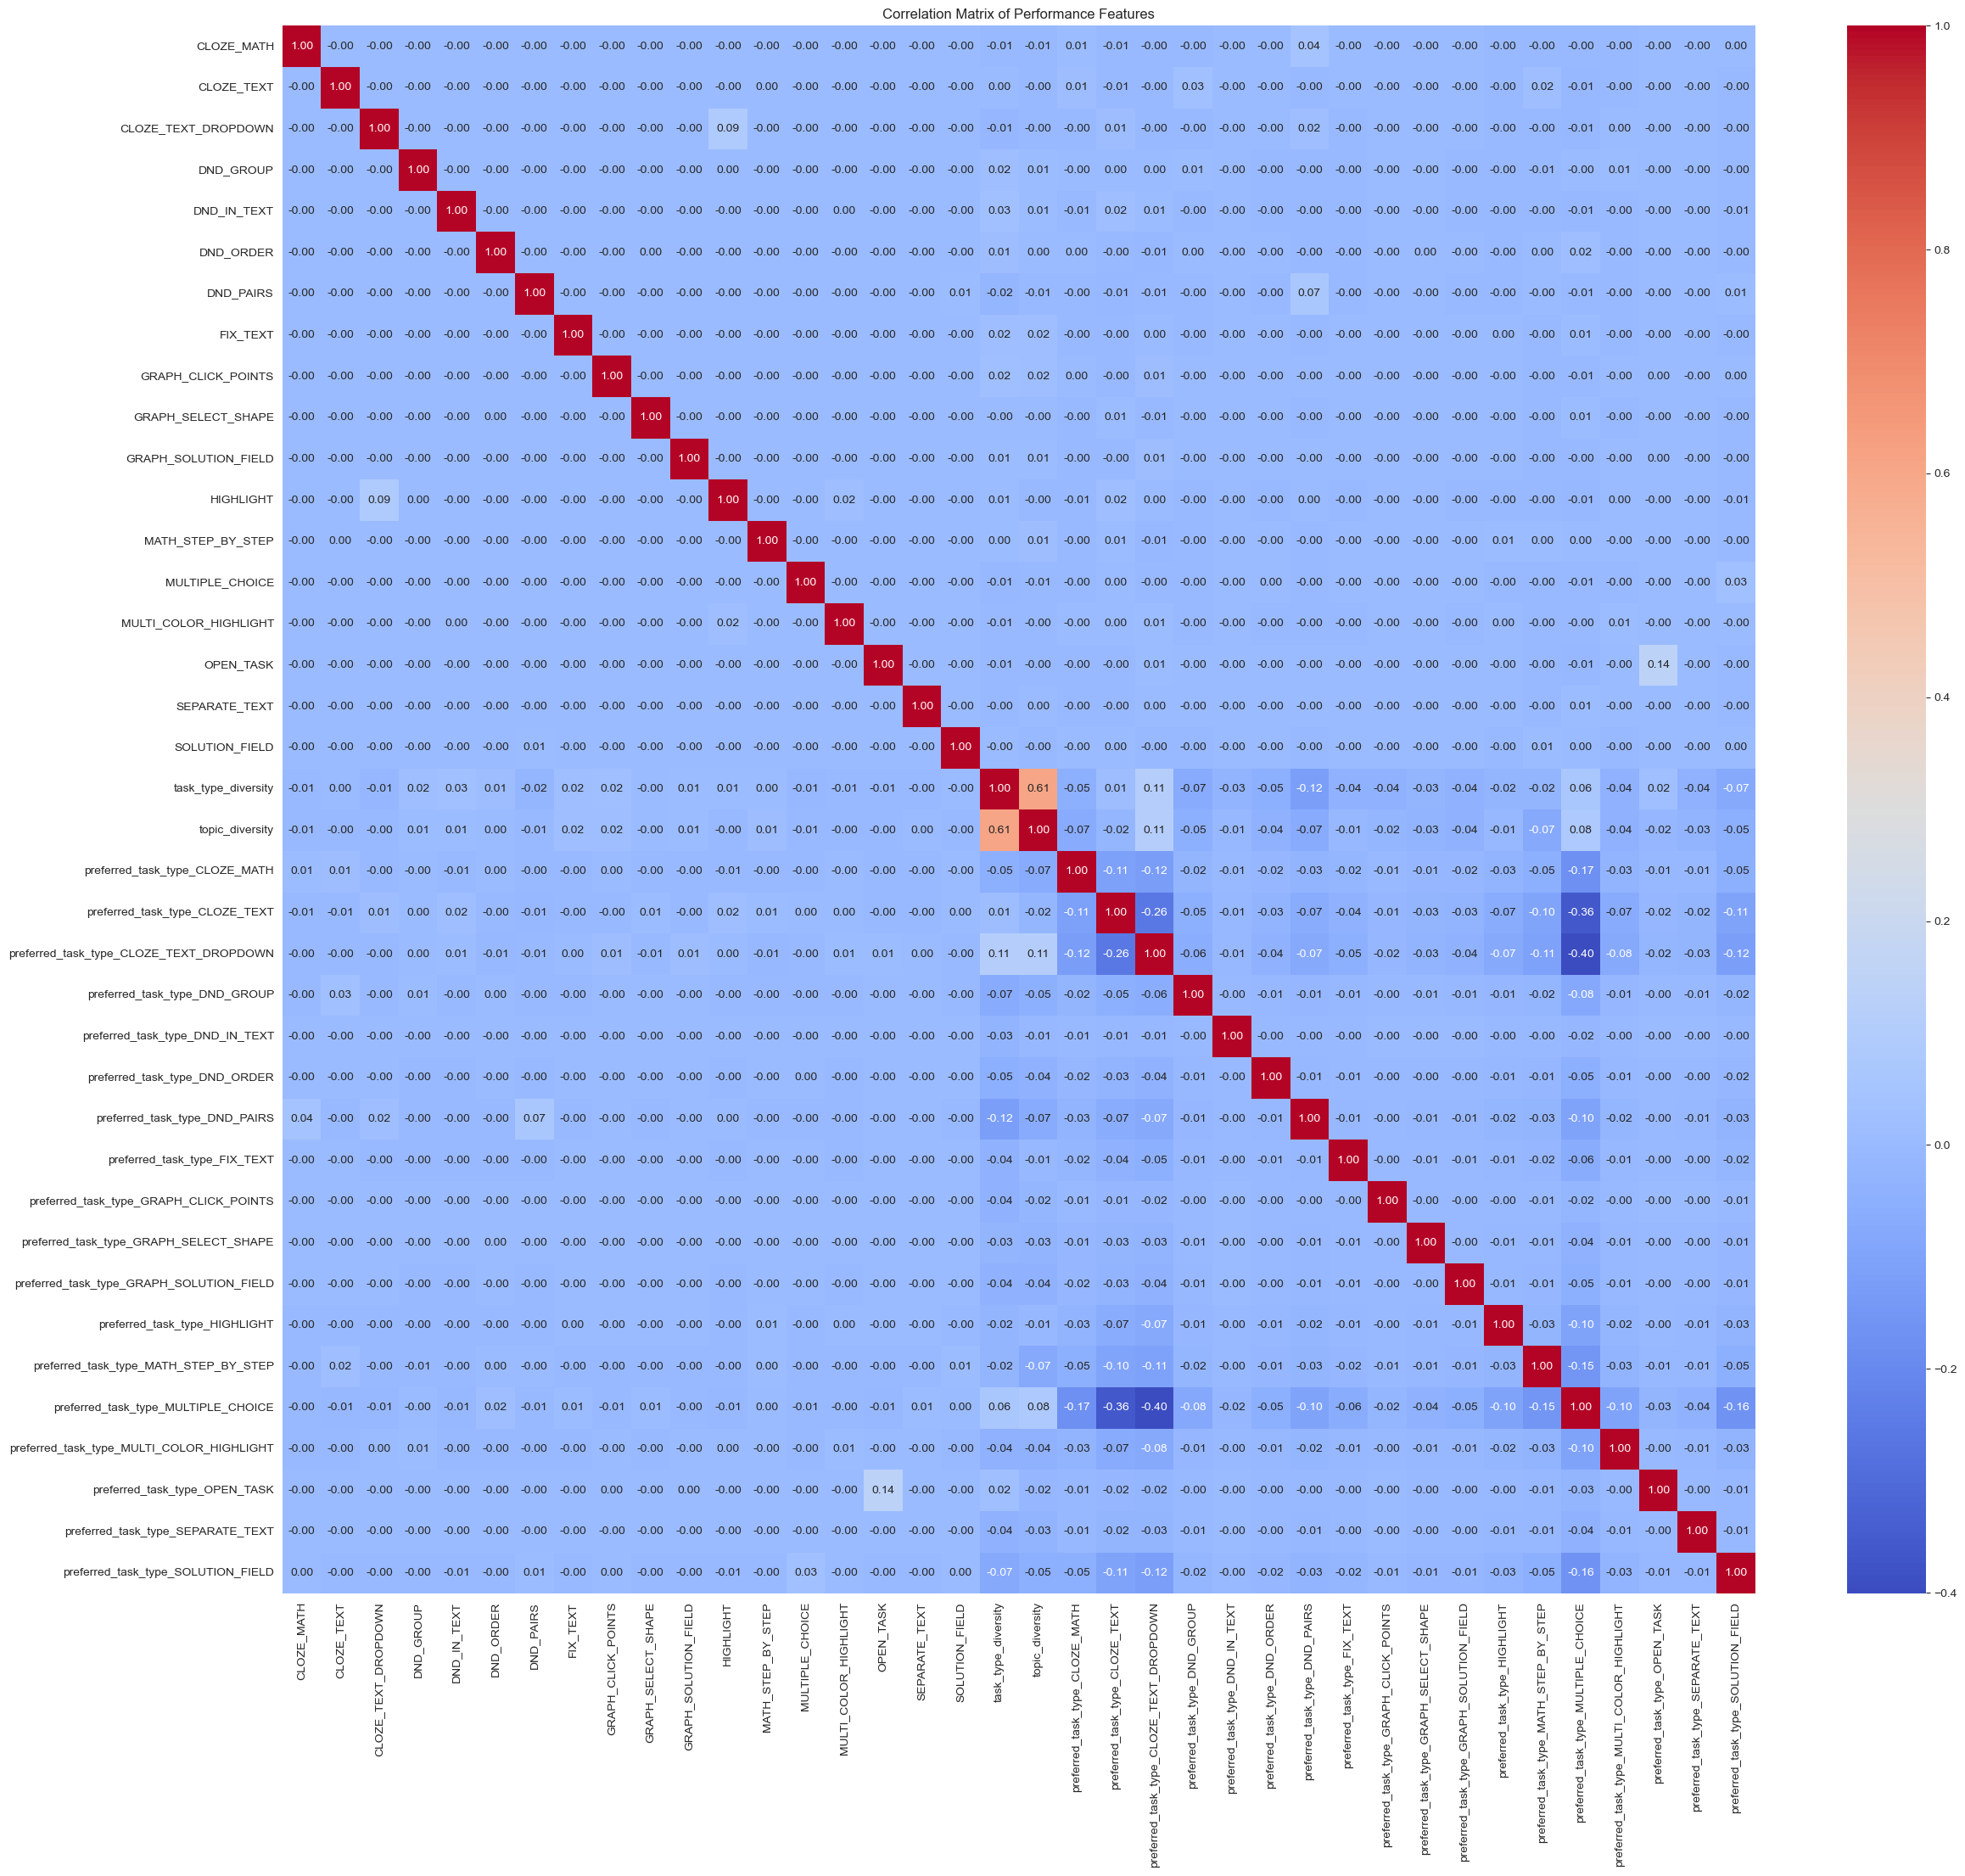

In [43]:
# Plot correlation matrix
plt.figure(figsize=(28, 24))
sns.heatmap(performance_features.drop('user_id', axis=1).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix of Performance Features')
plt.show()

In [44]:
# Remove user_id column before scaling
X = performance_features.drop(columns=['user_id'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save scaled dataframe if we want
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

,CLOZE_MATH,CLOZE_TEXT,CLOZE_TEXT_DROPDOWN,DND_GROUP,DND_IN_TEXT,DND_ORDER,DND_PAIRS,FIX_TEXT,GRAPH_CLICK_POINTS,GRAPH_SELECT_SHAPE,...,preferred_task_type_GRAPH_CLICK_POINTS,preferred_task_type_GRAPH_SELECT_SHAPE,preferred_task_type_GRAPH_SOLUTION_FIELD,preferred_task_type_HIGHLIGHT,preferred_task_type_MATH_STEP_BY_STEP,preferred_task_type_MULTIPLE_CHOICE,preferred_task_type_MULTI_COLOR_HIGHLIGHT,preferred_task_type_OPEN_TASK,preferred_task_type_SEPARATE_TEXT,preferred_task_type_SOLUTION_FIELD
0,-0.015730,-0.020035,-0.020152,-0.024745,-0.023364,-0.021056,-0.023565,-0.014761,-0.009598,-0.010863,...,-0.028174,-0.058861,-0.067775,-0.136138,-0.206675,-0.747050,-0.140517,-0.034173,-0.051182,-0.219128
1,-0.015473,-0.020022,-0.020171,-0.024069,-0.023272,-0.021162,-0.023522,-0.014683,-0.007722,-0.010767,...,-0.028174,-0.058861,-0.067775,-0.136138,-0.206675,-0.747050,-0.140517,-0.034173,-0.051182,4.563537
2,-0.015518,-0.020084,-0.020180,-0.024102,-0.023562,-0.021021,-0.023531,-0.014864,-0.009387,-0.010746,...,-0.028174,-0.058861,-0.067775,-0.136138,-0.206675,1.338598,-0.140517,-0.034173,-0.051182,-0.219128
3,-0.015730,-0.020084,-0.020231,-0.024907,-0.023562,-0.021427,-0.023629,-0.014864,-0.009598,-0.010863,...,-0.028174,-0.058861,-0.067775,-0.136138,4.838508,-0.747050,-0.140517,-0.034173,-0.051182,-0.219128
4,-0.015730,-0.020084,-0.020035,-0.024907,-0.023562,-0.021427,-0.023629,-0.014864,-0.009598,-0.010863,...,-0.028174,-0.058861,-0.067775,-0.136138,-0.206675,1.338598,-0.140517,-0.034173,-0.051182,-0.219128


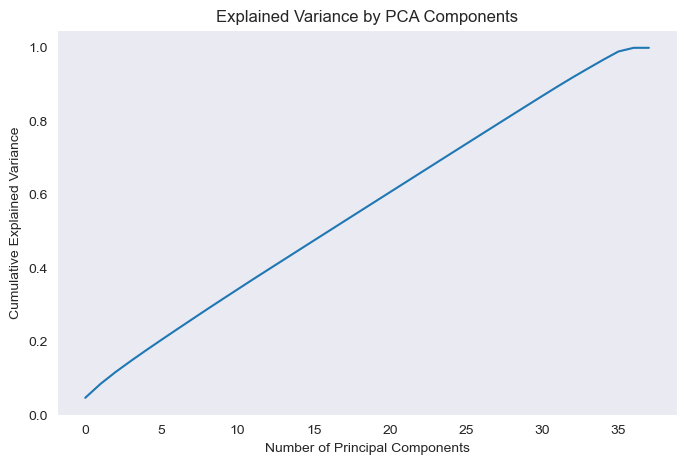

In [45]:
# Apply PCA keeping all components
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Plot explained variance
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid()
plt.show()

## Correlation and Dimensionality Analysis of Performance Features

We first analyzed the correlation matrix of the performance-based features:

- No strong correlations were detected (all below 0.9).
- Each feature provides distinct behavioral information.
- Therefore, we decided to keep all performance features for the clustering step.

We then performed a PCA to explore the possibility of dimensionality reduction:

- The cumulative explained variance increased steadily without a clear "elbow".
- A large number of components would be needed to capture sufficient variance.
- As a result, we decided to cluster directly on the full set of scaled features without applying dimensionality reduction.

### Temporal Behavior Features

#### Step 1: Prepare daily activity

In [46]:
from functools import reduce

events['event_date'] = pd.to_datetime(events['event_date'])
events = events.sort_values(by=['user_id', 'event_date'])

daily_activity = events.groupby(['user_id', pd.Grouper(key='event_date', freq='D')])['event_id'].count().unstack(fill_value=0)

# Calculate temporal features
temporal_features = daily_activity.apply(lambda x: {
    'active_days': (x > 0).sum(),
    'mean_events': x.mean(),
    'time_var': x.std(),
    'weekend_ratio': x[x.index.weekday >= 5].sum() / x.sum() if x.sum() > 0 else 0
}, axis=1)

# Convert Series of dicts to dataframe
temporal_df = pd.DataFrame(temporal_features.tolist(), index=temporal_features.index).reset_index()
temporal_df = temporal_df.rename(columns={'index': 'user_id'})

#### Step 2: Time between events

In [47]:
events['time_diff'] = events.groupby('user_id')['event_date'].diff().dt.total_seconds()

event_time_stats = events.groupby('user_id')['time_diff'].agg(['mean', 'std']).reset_index()
event_time_stats.columns = ['user_id', 'avg_time_between_events', 'std_time_between_events']

#### Step 3: Merge temporal features

In [48]:
temporal_final = temporal_df.merge(event_time_stats, on='user_id', how='left')

# Check
temporal_final.head()

,user_id,active_days,mean_events,time_var,weekend_ratio,avg_time_between_events,std_time_between_events
0,387604,100,8.113238,33.566561,0.045606,10424.632556,1.237126e+05
1,387605,54,5.748006,34.340947,0.185905,12543.136260,1.852490e+05
2,387608,87,3.762360,14.224332,0.130140,18650.922512,1.588434e+05
3,387613,5,0.339713,4.971908,0.089202,192817.528580,2.493983e+06
4,387615,12,0.853270,8.696562,0.145794,84626.140627,1.073315e+06


In [49]:
# Check missing values
temporal_final.isnull().sum()

user_id                    0
active_days                0
mean_events                0
time_var                   0
weekend_ratio              0
avg_time_between_events    2
std_time_between_events    2
dtype: int64

In [50]:
# Fill missing time differences with 0 (meaning: no info about time gaps)
temporal_final['avg_time_between_events'] = temporal_final['avg_time_between_events'].fillna(0)
temporal_final['std_time_between_events'] = temporal_final['std_time_between_events'].fillna(0)

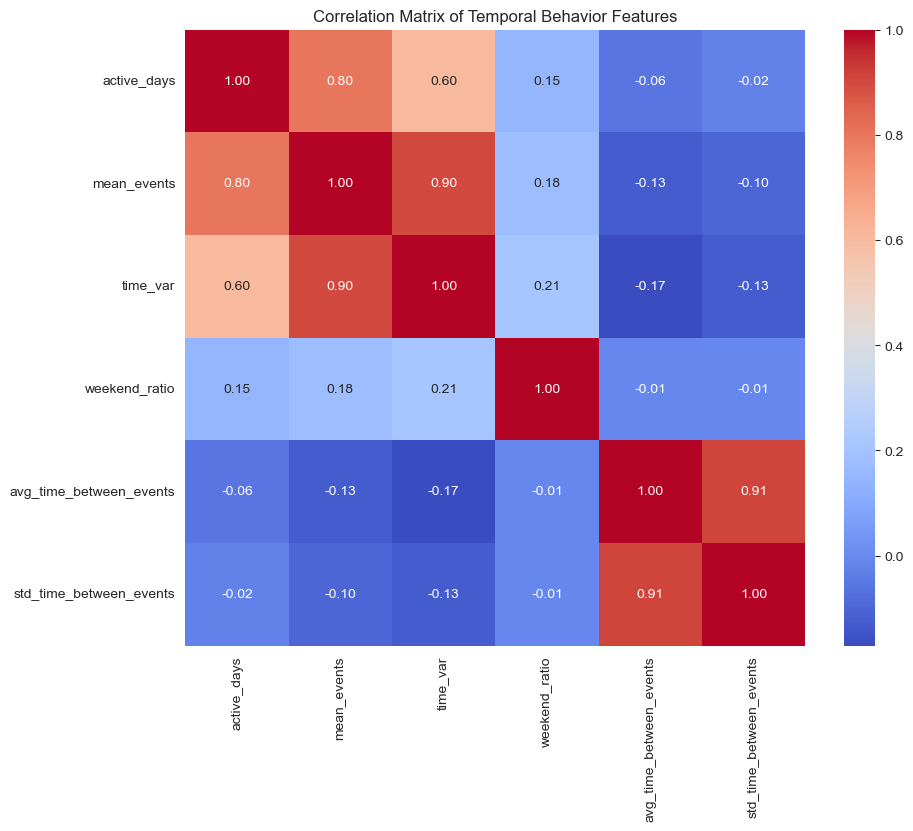

In [51]:
# Plot correlation heatmap for temporal features
plt.figure(figsize=(10,8))
sns.heatmap(temporal_final.drop(columns='user_id').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix of Temporal Behavior Features')
plt.show()

In [52]:
# Keep only selected columns
temporal_final_clean = temporal_final[['user_id',
                                       'active_days',
                                       'mean_events',
                                       'weekend_ratio',
                                       'avg_time_between_events']]

# Check
temporal_final_clean.head()

,user_id,active_days,mean_events,weekend_ratio,avg_time_between_events
0,387604,100,8.113238,0.045606,10424.632556
1,387605,54,5.748006,0.185905,12543.136260
2,387608,87,3.762360,0.130140,18650.922512
3,387613,5,0.339713,0.089202,192817.528580
4,387615,12,0.853270,0.145794,84626.140627


## Cleaning and Feature Selection for Temporal Behavior

We analyzed the correlation matrix of temporal behavior features.

- `mean_events` and `time_var` were highly correlated (0.90).
- `avg_time_between_events` and `std_time_between_events` were also highly correlated (0.91).

To avoid redundancy, we kept:
- `active_days`
- `mean_events`
- `weekend_ratio`
- `avg_time_between_events`

This ensures a diverse set of temporal behavior indicators without multicollinearity.

### Consistensy Features

#### Step 1 - Number of weeks active

In [53]:
# Extract week number
events['week'] = events['event_date'].dt.isocalendar().week

# Number of unique weeks active
weeks_active = events.groupby('user_id')['week'].nunique().reset_index()
weeks_active.columns = ['user_id', 'weeks_active']
weeks_active.head()

,user_id,weeks_active
0,387604,38
1,387605,29
2,387608,41
3,387613,4
4,387615,8


#### Step 2 - Number of "silent periods" (>7 days no activity)

In [54]:
# Time difference between consecutive events
events['event_gap_days'] = events.groupby('user_id')['event_date'].diff().dt.days

# Count how many times there is a gap >7 days
silent_periods = events.groupby('user_id')['event_gap_days'].apply(lambda x: (x > 7).sum()).reset_index()
silent_periods.columns = ['user_id', 'silent_periods']
silent_periods.head()

,user_id,silent_periods
0,387604,17
1,387605,22
2,387608,18
3,387613,3
4,387615,4


#### Step 3 - Merge Consistency Features

In [55]:
# Merge weeks_active and silent_periods
consistency_features = weeks_active.merge(silent_periods, on='user_id', how='left')

# Check
consistency_features.head()

,user_id,weeks_active,silent_periods
0,387604,38,17
1,387605,29,22
2,387608,41,18
3,387613,4,3
4,387615,8,4


In [56]:
# Check missing values
consistency_features.isnull().sum()

user_id           0
weeks_active      0
silent_periods    0
dtype: int64

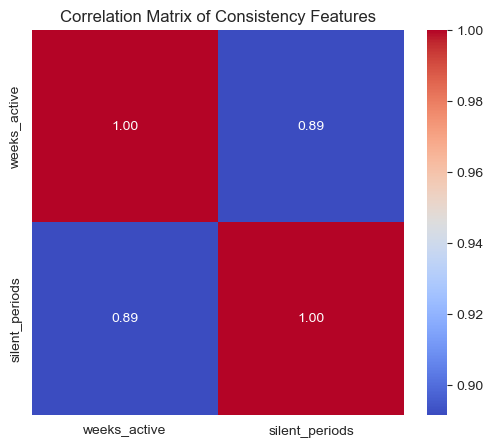

In [57]:
# Plot correlation matrix for consistency features
plt.figure(figsize=(6,5))
sns.heatmap(consistency_features.drop(columns='user_id').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix of Consistency Features')
plt.show()

## Consistency Features Analysis

We created two consistency features:
- `weeks_active`: number of weeks the user was active
- `silent_periods`: number of inactivity gaps longer than 7 days

Their correlation was 0.89, indicating some relation but capturing complementary aspects of consistency.
Thus, both features were retained for clustering.

## Merge and Correlation Analysis

In [58]:
# List of dataframes to merge
dfs_to_merge = [final_session_features, performance_features, temporal_final_clean, consistency_features]

# Merge all on user_id
features_final = reduce(lambda left, right: pd.merge(left, right, on='user_id', how='outer'), dfs_to_merge)

# Check
print(f"Shape of features_final: {features_final.shape}")
features_final.head()

Shape of features_final: (22470, 61)


,user_id,total_sessions,total_num_events,avg_session_duration_min,median_session_duration_min,std_session_duration_min,max_session_duration_min,min_session_duration_min,avg_num_events_per_session,avg_unique_topics_per_session,...,preferred_task_type_MULTI_COLOR_HIGHLIGHT,preferred_task_type_OPEN_TASK,preferred_task_type_SEPARATE_TEXT,preferred_task_type_SOLUTION_FIELD,active_days,mean_events,weekend_ratio,avg_time_between_events,weeks_active,silent_periods
0,387604,61.0,1105.0,12963.096278,1.331083,64843.133625,492921.146800,0.000000,18.114754,0.918033,...,False,False,False,False,100,8.113238,0.045606,10424.632556,38,17
1,387605,67.0,742.0,29595.661530,3.315933,98793.615011,531286.253133,0.000000,11.074627,0.955224,...,False,False,False,True,54,5.748006,0.185905,12543.136260,29,22
2,387608,31.0,469.0,11904.947317,3.627667,40661.940478,217246.262683,0.000000,15.129032,0.548387,...,False,False,False,False,87,3.762360,0.130140,18650.922512,41,18
3,387613,4.0,31.0,1.019733,0.923208,0.581060,1.766600,0.465917,7.750000,1.000000,...,False,False,False,False,5,0.339713,0.089202,192817.528580,4,3
4,387615,2.0,48.0,9.675450,9.675450,0.642996,10.130117,9.220783,24.000000,1.000000,...,False,False,False,False,12,0.853270,0.145794,84626.140627,8,4


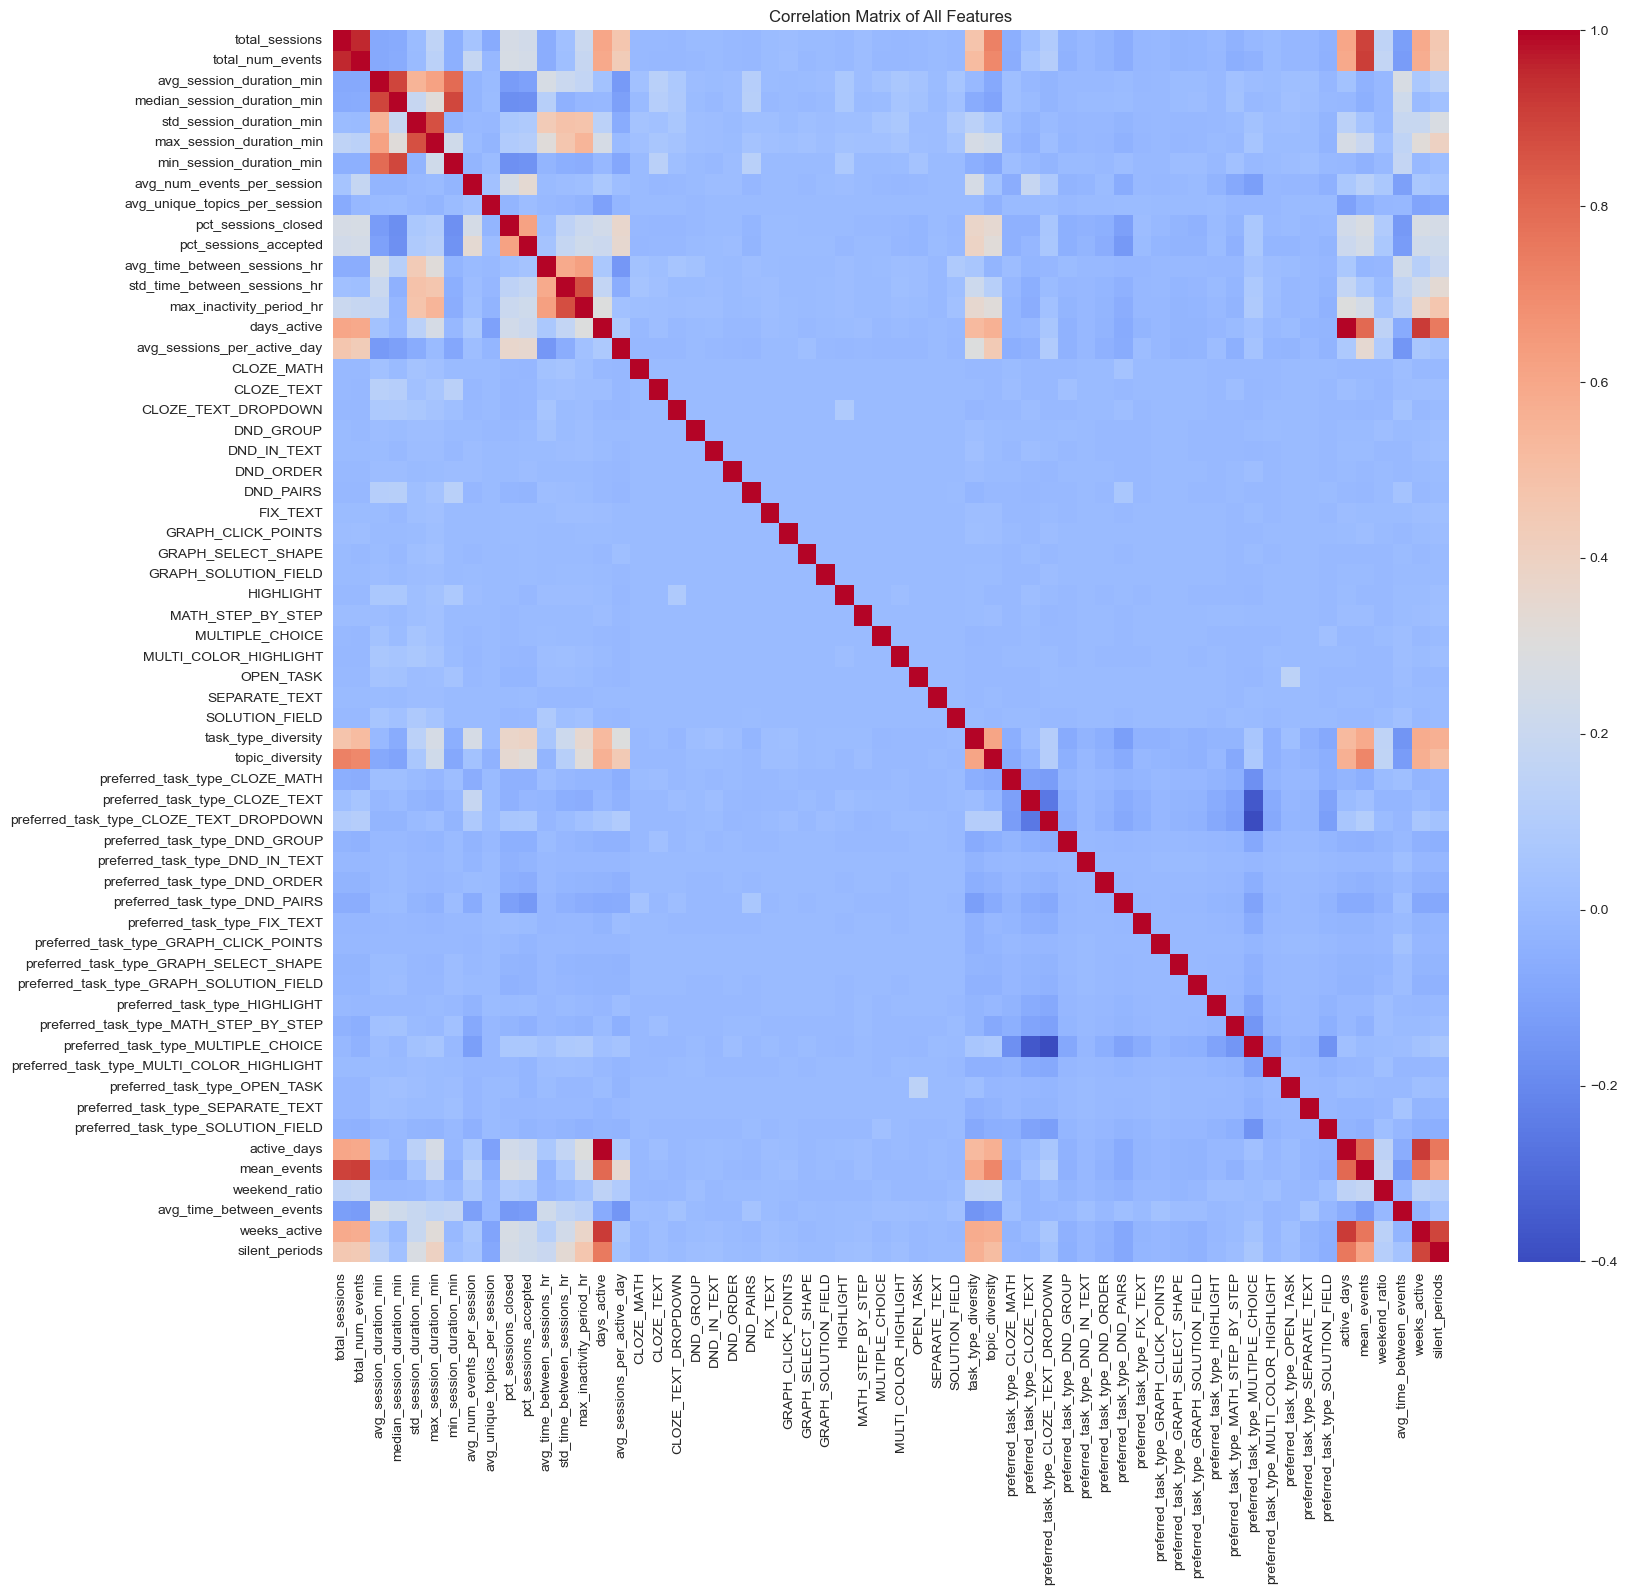

In [59]:
# Drop user_id for correlation
plt.figure(figsize=(18, 16))
sns.heatmap(features_final.drop(columns='user_id').corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of All Features')
plt.show()

## Correlation Analysis and Feature Selection

We analyzed the full correlation matrix across session, performance, temporal, and consistency features.

- Within session-based features, high correlations were observed between `total_sessions` and `total_num_events`, as well as among session duration statistics.
- To avoid redundancy, we dropped `total_num_events` and `min_session_duration_min`.

Performance, temporal, and consistency features showed acceptable levels of correlation, and all were retained.

This feature selection ensures a diverse and independent set of behavioral indicators for clustering.

In [60]:
# Columns to drop based on correlation analysis
columns_to_drop = [
    'total_num_events',          # Highly correlated with total_sessions
    'min_session_duration_min',  # Low info + correlated with other durations
    'median_session_duration_min'  # Optional: we can comment this line if you we to keep it
]

# Drop them
features_final_clean = features_final.drop(columns=columns_to_drop)

# Check the new shape
print(f"Shape after dropping redundant features: {features_final_clean.shape}")
features_final_clean.head()

Shape after dropping redundant features: (22470, 58)


,user_id,total_sessions,avg_session_duration_min,std_session_duration_min,max_session_duration_min,avg_num_events_per_session,avg_unique_topics_per_session,pct_sessions_closed,pct_sessions_accepted,avg_time_between_sessions_hr,...,preferred_task_type_MULTI_COLOR_HIGHLIGHT,preferred_task_type_OPEN_TASK,preferred_task_type_SEPARATE_TEXT,preferred_task_type_SOLUTION_FIELD,active_days,mean_events,weekend_ratio,avg_time_between_events,weeks_active,silent_periods
0,387604,61.0,12963.096278,64843.133625,492921.146800,18.114754,0.918033,0.982143,0.826087,229.595889,...,False,False,False,False,100,8.113238,0.045606,10424.632556,38,17
1,387605,67.0,29595.661530,98793.615011,531286.253133,11.074627,0.955224,0.984375,1.000000,187.273808,...,False,False,False,True,54,5.748006,0.185905,12543.136260,29,22
2,387608,31.0,11904.947317,40661.940478,217246.262683,15.129032,0.548387,1.000000,1.000000,407.203174,...,False,False,False,False,87,3.762360,0.130140,18650.922512,41,18
3,387613,4.0,1.019733,0.581060,1.766600,7.750000,1.000000,0.750000,1.000000,439.497068,...,False,False,False,False,5,0.339713,0.089202,192817.528580,4,3
4,387615,2.0,9.675450,0.642996,10.130117,24.000000,1.000000,1.000000,1.000000,0.172846,...,False,False,False,False,12,0.853270,0.145794,84626.140627,8,4


In [61]:
# Remove very low-variance features (threshold = 0.01 is common)
selector = VarianceThreshold(threshold=0.01)
features_selected = selector.fit_transform(features_final_clean.drop(columns='user_id'))

print(f"Original shape: {features_final_clean.drop(columns='user_id').shape}")
print(f"After Variance Threshold: {features_selected.shape}")


# Recover the column names that were kept
selected_columns = features_final_clean.drop(columns=['user_id']).columns[selector.get_support()]

# Check
print(f"Selected {len(selected_columns)} features:")
print(selected_columns.tolist())

Original shape: (22470, 57)
After Variance Threshold: (22470, 48)
Selected 48 features:
['total_sessions', 'avg_session_duration_min', 'std_session_duration_min', 'max_session_duration_min', 'avg_num_events_per_session', 'pct_sessions_closed', 'pct_sessions_accepted', 'avg_time_between_sessions_hr', 'std_time_between_sessions_hr', 'max_inactivity_period_hr', 'days_active', 'avg_sessions_per_active_day', 'CLOZE_MATH', 'CLOZE_TEXT', 'CLOZE_TEXT_DROPDOWN', 'DND_GROUP', 'DND_IN_TEXT', 'DND_ORDER', 'DND_PAIRS', 'FIX_TEXT', 'GRAPH_CLICK_POINTS', 'GRAPH_SELECT_SHAPE', 'GRAPH_SOLUTION_FIELD', 'HIGHLIGHT', 'MATH_STEP_BY_STEP', 'MULTIPLE_CHOICE', 'MULTI_COLOR_HIGHLIGHT', 'OPEN_TASK', 'SEPARATE_TEXT', 'SOLUTION_FIELD', 'task_type_diversity', 'topic_diversity', 'preferred_task_type_CLOZE_MATH', 'preferred_task_type_CLOZE_TEXT', 'preferred_task_type_CLOZE_TEXT_DROPDOWN', 'preferred_task_type_DND_GROUP', 'preferred_task_type_DND_PAIRS', 'preferred_task_type_HIGHLIGHT', 'preferred_task_type_MATH_STEP

## Prepare Final Feature Table

After merging and cleaning all feature families, we applied a Variance Threshold analysis with a threshold of 0.01.

- 57 features were initially available.
- 48 features were retained after removing near-constant features.

This step ensures that only informative and varying features are used for clustering.

In [62]:
# Rebuild clean dataframe
X_selected_df = pd.DataFrame(features_selected, columns=selected_columns)

# Add user_id back
X_selected_df['user_id'] = features_final_clean['user_id'].values

# Check
X_selected_df.head()


,total_sessions,avg_session_duration_min,std_session_duration_min,max_session_duration_min,avg_num_events_per_session,pct_sessions_closed,pct_sessions_accepted,avg_time_between_sessions_hr,std_time_between_sessions_hr,max_inactivity_period_hr,...,preferred_task_type_MULTIPLE_CHOICE,preferred_task_type_MULTI_COLOR_HIGHLIGHT,preferred_task_type_SOLUTION_FIELD,active_days,mean_events,weekend_ratio,avg_time_between_events,weeks_active,silent_periods,user_id
0,61.0,12963.096278,64843.133625,492921.1468,18.114754,0.982143,0.826087,229.595889,425.555724,1676.341603,...,False,False,False,100,8.113238,0.045606,10424.632556,38,17,387604
1,67.0,29595.66153,98793.615011,531286.253133,11.074627,0.984375,1.0,187.273808,464.944778,3120.276084,...,False,False,True,54,5.748006,0.185905,12543.13626,29,22,387605
2,31.0,11904.947317,40661.940478,217246.262683,15.129032,1.0,1.0,407.203174,787.446374,3049.412006,...,True,False,False,87,3.76236,0.13014,18650.922512,41,18,387608
3,4.0,1.019733,0.58106,1.7666,7.75,0.75,1.0,439.497068,548.218223,1053.816563,...,False,False,False,5,0.339713,0.089202,192817.52858,4,3,387613
4,2.0,9.67545,0.642996,10.130117,24.0,1.0,1.0,0.172846,0.0,0.172846,...,True,False,False,12,0.85327,0.145794,84626.140627,8,4,387615


In [63]:
# Separate user_id and features
X_features_final = X_selected_df.drop(columns=['user_id'])
user_ids_final = X_selected_df['user_id']

# Apply scaling
scaler = StandardScaler()
X_scaled_final_clustering = scaler.fit_transform(X_features_final)
X_scaled_final_clustering = pd.DataFrame(X_scaled_final_clustering, columns=X_features_final.columns)

# Wrap back into a DataFrame for easier analysis
X_scaled_final_df = X_scaled_final_clustering.copy()
X_scaled_final_df['user_id'] = user_ids_final.values

# Check
X_scaled_final_df.head()

,total_sessions,avg_session_duration_min,std_session_duration_min,max_session_duration_min,avg_num_events_per_session,pct_sessions_closed,pct_sessions_accepted,avg_time_between_sessions_hr,std_time_between_sessions_hr,max_inactivity_period_hr,...,preferred_task_type_MULTIPLE_CHOICE,preferred_task_type_MULTI_COLOR_HIGHLIGHT,preferred_task_type_SOLUTION_FIELD,active_days,mean_events,weekend_ratio,avg_time_between_events,weeks_active,silent_periods,user_id
0,2.178260,0.040976,1.091944,3.761500,0.114304,0.591600,0.156031,-0.027532,0.017587,0.189341,...,-0.747050,-0.140517,-0.219128,11.997447,5.806972,-0.183118,-0.325153,8.649997,6.477566,387604
1,2.445658,0.468185,1.881149,4.092042,-0.519263,0.598772,0.574557,-0.088120,0.066162,0.865307,...,-0.747050,-0.140517,4.563537,6.115191,3.930310,0.603994,-0.304138,6.354716,8.630960,387605
2,0.841269,0.013797,0.529834,1.386367,-0.154392,0.648977,0.574557,0.226730,0.463874,0.832133,...,1.338598,-0.140517,-0.219128,10.335071,2.354826,0.291138,-0.243549,9.415091,6.908245,387608
3,-0.362023,-0.291957,-0.415370,-0.485347,-0.818458,-0.154303,0.574557,0.272961,0.168855,-0.102089,...,-0.747050,-0.140517,-0.219128,-0.150690,-0.360828,0.061465,1.484182,-0.021065,0.448063,387613
4,-0.451156,-0.291734,-0.415368,-0.485275,0.643939,0.648977,0.574557,-0.355972,-0.507214,-0.595344,...,1.338598,-0.140517,-0.219128,0.744436,0.046646,0.378964,0.410925,0.999060,0.878742,387615


In [64]:
# Quick statistical summary
X_scaled_final_df.describe()

,total_sessions,avg_session_duration_min,std_session_duration_min,max_session_duration_min,avg_num_events_per_session,pct_sessions_closed,pct_sessions_accepted,avg_time_between_sessions_hr,std_time_between_sessions_hr,max_inactivity_period_hr,...,preferred_task_type_MULTIPLE_CHOICE,preferred_task_type_MULTI_COLOR_HIGHLIGHT,preferred_task_type_SOLUTION_FIELD,active_days,mean_events,weekend_ratio,avg_time_between_events,weeks_active,silent_periods,user_id
count,1.963000e+04,1.963000e+04,1.963000e+04,19630.000000,1.963000e+04,1.963000e+04,1.963000e+04,19630.000000,1.963000e+04,1.963000e+04,...,2.143300e+04,2.143300e+04,2.143300e+04,2.247000e+04,2.247000e+04,2.247000e+04,22470.000000,2.247000e+04,22470.000000,22470.000000
mean,2.316594e-17,1.158297e-17,-2.316594e-17,0.000000,1.151058e-16,-4.633187e-17,8.108078e-17,0.000000,-1.158297e-17,-4.633187e-17,...,-3.182574e-17,2.652145e-17,5.569504e-17,-2.023798e-17,-2.023798e-17,1.011899e-17,0.000000,6.071393e-17,0.000000,407695.489542
std,1.000025e+00,1.000025e+00,1.000025e+00,1.000025,1.000025e+00,1.000025e+00,1.000025e+00,1.000025,1.000025e+00,1.000025e+00,...,1.000023e+00,1.000023e+00,1.000023e+00,1.000022e+00,1.000022e+00,1.000022e+00,1.000022,1.000022e+00,1.000022,11800.847723
min,-4.957220e-01,-2.919828e-01,-4.153834e-01,-0.485362,-1.425915e+00,-2.564143e+00,-1.831966e+00,-0.356219,-5.072139e-01,-5.954253e-01,...,-7.470500e-01,-1.405168e-01,-2.191283e-01,-6.621906e-01,-6.291035e-01,-4.389829e-01,-0.428566,-7.861591e-01,-0.843973,387604.000000
25%,-4.511556e-01,-2.918388e-01,-4.153320e-01,-0.485270,-5.409774e-01,-1.543032e-01,1.233336e-01,-0.356127,-5.072139e-01,-5.953802e-01,...,-7.470500e-01,-1.405168e-01,-2.191283e-01,-5.343154e-01,-4.937004e-01,-4.389829e-01,-0.406918,-5.311278e-01,-0.843973,398001.250000
50%,-3.174565e-01,-2.850633e-01,-4.086639e-01,-0.470655,-1.283093e-01,4.883207e-01,5.745565e-01,-0.316087,-4.527768e-01,-5.167953e-01,...,-7.470500e-01,-1.405168e-01,-2.191283e-01,-2.785652e-01,-3.152721e-01,-4.389829e-01,-0.276284,-2.760966e-01,-0.413294,406203.500000
75%,3.907447e-02,-1.253779e-01,-7.101247e-02,-0.013252,3.019629e-01,6.489766e-01,5.745565e-01,-0.037022,9.610756e-02,1.856635e-01,...,1.338598e+00,-1.405168e-01,-2.191283e-01,1.050602e-01,6.815906e-02,-1.792739e-01,-0.003940,2.339659e-01,0.448063,415909.750000
max,2.789306e+01,1.893648e+01,1.386980e+01,7.002381,1.432297e+01,6.489766e-01,5.745565e-01,20.379959,1.056108e+01,6.185469e+00,...,1.338598e+00,7.116585e+00,4.563537e+00,3.041147e+01,1.968769e+01,5.171297e+00,28.156110,1.196540e+01,8.630960,432020.000000


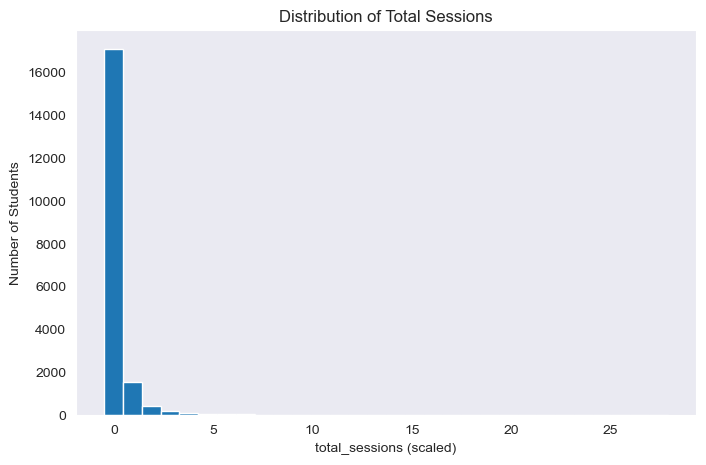

In [65]:
# Distribution of total_sessions
plt.figure(figsize=(8,5))
plt.hist(X_scaled_final_df['total_sessions'], bins=30)
plt.title('Distribution of Total Sessions')
plt.xlabel('total_sessions (scaled)')
plt.ylabel('Number of Students')
plt.grid()
plt.show()

## Save for Clustering

In [66]:
# 1. Save scaled features
X_scaled_final_df.to_csv('final_scaled_features_with_userid.csv', index=False)

# 2. Save clean feature matrix for clustering
X_scaled_final_clustering.to_csv('final_features_for_clustering.csv', index=False)

# 3. Save scaler (optional but good)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Saved all files for clustering.")

✅ Saved all files for clustering.


## Cleaning and Feature Selection for Temporal Behavior

We analyzed the correlation matrix of temporal behavior features.

- `mean_events` and `time_var` were highly correlated (0.90).
- `avg_time_between_events` and `std_time_between_events` were also highly correlated (0.91).

To avoid redundancy, we kept:
- `active_days`
- `mean_events`
- `weekend_ratio`
- `avg_time_between_events`

This ensures a diverse set of temporal behavior indicators without multicollinearity.### 3.3 Feature Engineering (RQ2): Temporal Behavior Vectors

#### Constructing Multivariate Sequences

To capture multiple dimensions of learning behavior over time, we build multivariate sequences for each user. Each sequence includes weekly values of selected features such as action count, correctness ratio, and average task duration. These sequences will serve as input to our clustering and prediction models.

In [67]:
weekly_activity.columns


Index(['user_id', 'year_week', 'session_count', 'action_count',
       'unique_actions', 'avg_task_duration', 'correct_ratio', 'skip_ratio',
       'go_theory_ratio'],
      dtype='object')

In [68]:
# Feature list to include in the sequence
feature_list = ['action_count', 'correct_ratio', 'avg_task_duration']

# Prepare empty dict to store wide-format DataFrames
seq_dict = {}

# Ensure consistent users and weeks
weekly_activity['year_week'] = weekly_activity['year_week'].astype(str)
common_users = set(weekly_activity['user_id'])

# Create pivot tables for each feature
for feat in feature_list:
    df = weekly_activity.pivot(index='user_id', columns='year_week', values=feat).fillna(0)
    df = df.reindex(sorted(df.columns), axis=1)
    df = df.loc[df.index.isin(common_users)]
    seq_dict[feat] = df

# Stack into a 3D array: (n_users, n_weeks, n_features)
import numpy as np

users = list(seq_dict[feature_list[0]].index)
weeks = list(seq_dict[feature_list[0]].columns)

sequence_tensor = np.stack([seq_dict[feat].loc[users].values for feat in feature_list], axis=-1)

# Check shape
print("Sequence tensor shape (users, weeks, features):", sequence_tensor.shape)


Sequence tensor shape (users, weeks, features): (21433, 92, 3)


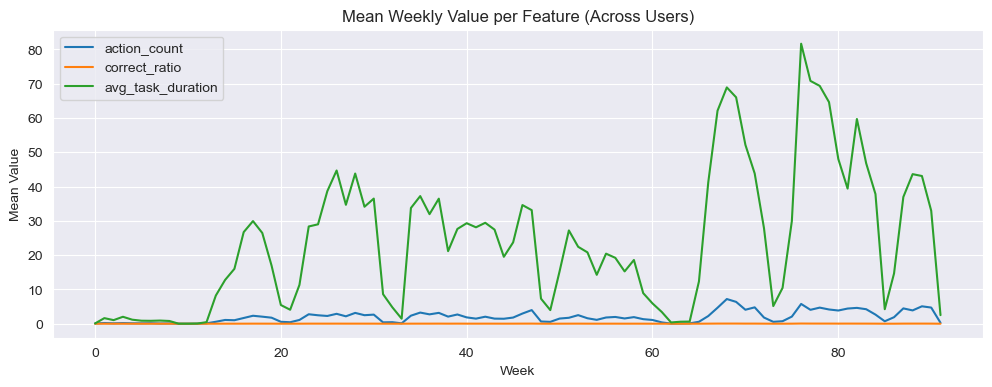

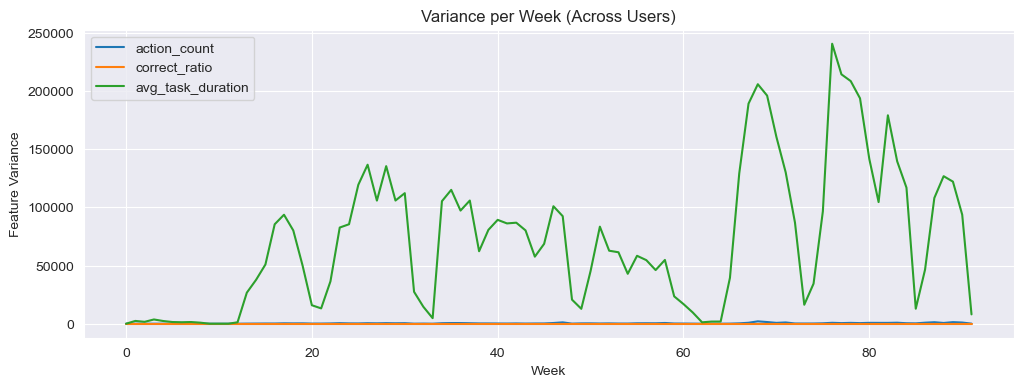

In [69]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = ['action_count', 'correct_ratio', 'avg_task_duration']

# Mean over users (axis=0) -> shape (weeks, features)
mean_over_users = sequence_tensor.mean(axis=0)
var_over_users = sequence_tensor.var(axis=0)

# Plot means per feature across weeks
plt.figure(figsize=(12, 4))
for i, name in enumerate(feature_names):
    plt.plot(mean_over_users[:, i], label=name)
plt.title("Mean Weekly Value per Feature (Across Users)")
plt.xlabel("Week")
plt.ylabel("Mean Value")
plt.legend()
plt.grid(True)
plt.show()

# Plot variance per feature across users
plt.figure(figsize=(12, 4))
for i, name in enumerate(feature_names):
    plt.plot(var_over_users[:, i], label=name)
plt.title("Variance per Week (Across Users)")
plt.xlabel("Week")
plt.ylabel("Feature Variance")
plt.legend()
plt.grid(True)
plt.show()


#### Slope Features (Trend Over Time)

To capture how student behavior changes, we compute the slope (trend) of each time series feature using linear regression. This helps distinguish students with increasing engagement, stable behavior, or decreasing activity over time.


In [70]:
feature_names = ['action_count', 'correct_ratio', 'avg_task_duration']

# Use the same user index that was used to construct sequence_tensor
user_ids = seq_dict['action_count'].index
slope_df = pd.DataFrame(index=user_ids)

# Define slope function
def compute_slope(seq):
    x = np.arange(len(seq))
    return linregress(x, seq).slope

# Compute all slopes in one loop
for i, name in enumerate(feature_names):
    slope_df[f'slope_{name}'] = np.apply_along_axis(compute_slope, 1, sequence_tensor[:, :, i])

#### Dropout Signal (Inactivity Weeks)

We compute the number of trailing weeks with no activity to capture potential disengagement. Students with long inactivity gaps toward the end may reflect dropout behavior.

In [71]:
# Dropout signal: number of trailing weeks with 0 activity (based on action_count)
def trailing_zeros(seq):
    return len(seq) - np.argmax(seq[::-1] > 0) if np.any(seq > 0) else len(seq)

dropout_signal = np.apply_along_axis(trailing_zeros, 1, sequence_tensor[:, :, 0])  # action_count = index 0
slope_df['inactivity_weeks'] = pd.Series(dropout_signal, index=user_ids)

# Preview result
slope_df.head()

,slope_action_count,slope_correct_ratio,slope_avg_task_duration,inactivity_weeks
user_id,,,,
387604,0.079597,0.000277,0.153053,89
387605,-0.180016,-0.002199,-3.722887,77
387608,0.001734,-0.000042,-0.073236,84
387613,0.005826,0.000909,0.026943,80
387615,-0.019797,-0.000687,-0.049371,18


In [72]:
# Optional: Keep only users with < 80 weeks of inactivity
slope_df = slope_df[slope_df['inactivity_weeks'] < 80]

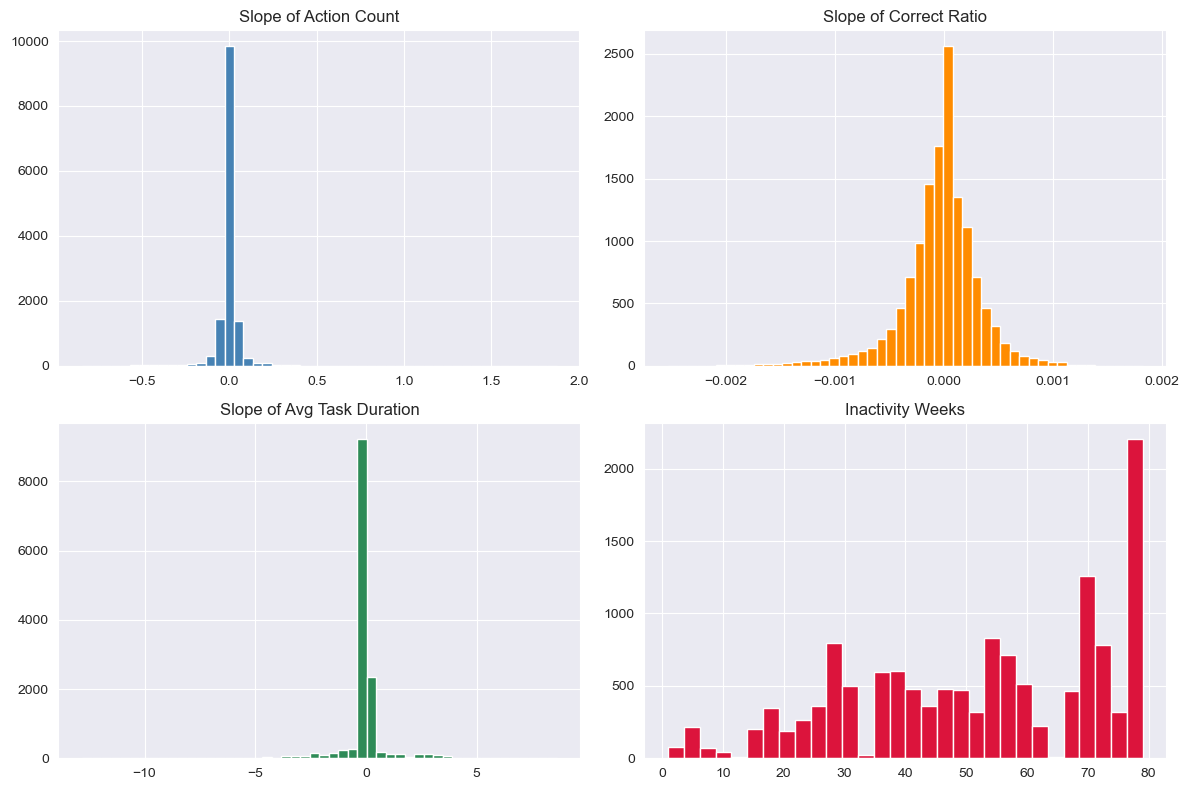

In [73]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

slope_df['slope_action_count'].hist(bins=50, ax=axs[0, 0], color='steelblue')
axs[0, 0].set_title("Slope of Action Count")

slope_df['slope_correct_ratio'].hist(bins=50, ax=axs[0, 1], color='darkorange')
axs[0, 1].set_title("Slope of Correct Ratio")

slope_df['slope_avg_task_duration'].hist(bins=50, ax=axs[1, 0], color='seagreen')
axs[1, 0].set_title("Slope of Avg Task Duration")

slope_df['inactivity_weeks'].hist(bins=30, ax=axs[1, 1], color='crimson')
axs[1, 1].set_title("Inactivity Weeks")

plt.tight_layout()
plt.show()


### Preparing DTW Input for Student Behavioral Clustering

We prepare student multivariate time series by normalizing the raw feature sequences and removing students with prolonged inactivity. Each student is represented by 92 weekly values across three features: action count, correct ratio, and task duration. This structure enables Dynamic Time Warping (DTW) clustering using the `tslearn` library.


In [74]:
# 1. Base tensor (21433 users, 92 weeks, 3 features)
n_users, n_weeks, n_features = sequence_tensor.shape

# 2. Normalize features across all users and weeks (z-score)
sequence_reshaped = sequence_tensor.reshape(-1, n_features)  # (21433 * 92, 3)
scaler = StandardScaler()
sequence_scaled = scaler.fit_transform(sequence_reshaped)
sequence_tensor_normalized = sequence_scaled.reshape(n_users, n_weeks, n_features)

# 3. Align inactivity filter to sequence_tensor
user_ids_full = seq_dict['action_count'].index  # Make sure this matches tensor
inactivity_vector = slope_df.reindex(user_ids_full)['inactivity_weeks']

# 4. Build mask for active users (e.g., inactivity < 80 weeks)
valid_mask = inactivity_vector < 80
valid_indices = valid_mask[valid_mask].index.to_numpy()

# 5. Filter tensor
df_q1 = sequence_tensor_normalized[valid_mask.values]

print("✅ Final DTW input shape:", df_q1.shape)

✅ Final DTW input shape: (13725, 92, 3)


### 3.4 Feature Engineering (RQ3): Early Prediction Features


In [75]:
# Identify the first 8 weeks in the dataset
early_weeks = sorted(weekly_activity['year_week'].unique())[:8]

# Filter weekly_activity to early window only
early_df = weekly_activity[weekly_activity['year_week'].isin(early_weeks)]


In [76]:
# Aggregate per-user stats over early weeks
agg_features = (
    early_df.groupby('user_id')
    .agg(
        mean_action_count=('action_count', 'mean'),
        std_action_count=('action_count', 'std'),
        mean_correct_ratio=('correct_ratio', 'mean'),
        std_correct_ratio=('correct_ratio', 'std'),
        mean_task_duration=('avg_task_duration', 'mean'),
        std_task_duration=('avg_task_duration', 'std'),
        mean_skip_ratio=('skip_ratio', 'mean'),
        std_skip_ratio=('skip_ratio', 'std'),
        active_weeks=('action_count', lambda x: (x > 0).sum())
    )
    .fillna(0)
)


In [77]:
# Dropout label based on inactivity duration
dropout_labels = (slope_df['inactivity_weeks'] >= 70).astype(int)

# Align to aggregated features
agg_features['dropout'] = dropout_labels.reindex(agg_features.index).fillna(0).astype(int)


In [78]:
# Final table for RQ3 modeling
df_q2 = agg_features.copy()

# Preview
df_q2.head()


,mean_action_count,std_action_count,mean_correct_ratio,std_correct_ratio,mean_task_duration,std_task_duration,mean_skip_ratio,std_skip_ratio,active_weeks,dropout
user_id,,,,,,,,,,
387605,17.0,22.605309,0.361757,0.336949,28.055225,14.134141,0.0,0.0,3,1
387742,30.0,0.000000,0.333333,0.000000,47.594600,0.000000,0.0,0.0,1,0
387744,32.0,0.000000,0.250000,0.000000,118.566813,0.000000,0.0,0.0,1,0
387747,91.0,0.000000,0.494505,0.000000,43.293758,0.000000,0.0,0.0,1,0
387758,65.0,0.000000,0.446154,0.000000,67.957015,0.000000,0.0,0.0,1,0


## 4. Modeling


In [81]:
# Store datasets
np.save('df_q1', df_q1)
np.save('df_q2', df_q2)

In [82]:
# Load datasets
df_q1 = np.load('df_q1.npy')
df_q2 = np.load('df_q2.npy')

### 4.1 Clustering for RQ1 (HDBSCAN, GMM)

### Prepare datasets for clustering
We will use different DataFrames in order to have a better overview on the clustering. Now that we have the features, we need to prepare them to be exactly on the correct format. But first, handling those big datasets eats a lot of RAM. Hence, it is a good practice to free some memory first.

In [83]:
# See memory usage
see_memory_usage(globals().items())

,Variable,Type,Size
0,df_events,DataFrame,20.06 GB
1,events,DataFrame,19.84 GB
2,filtered_events,DataFrame,3.96 GB
3,df_transactions,DataFrame,3.89 GB
4,transactions,DataFrame,3.87 GB
...,...,...,...
104,min_weeks,int,28 B
105,i,int,28 B
106,n_weeks,int,28 B
107,n_features,int,28 B


In [84]:
# Free some memory by deleting the biggest DataFrames and calling the garbage collector
del events, users, X_selected_df, features_final, df_events, df_transactions, daily_activity
gc.collect()

1306

In [85]:
# Since the least number of NaNs in a row is 12, those rows are not very important for our clustering of the entire dataset:
nan_df = X_scaled_final_clustering.isnull().sum(axis=1)
print(f'Number of row with at least one NaN: {len(nan_df)}')
print(f'Min number of NaNs in a single row: {nan_df[nan_df > 0].sort_values().iloc[0]}')
del nan_df

# Then, we drop the NaNs (the clustering algorithms does not do well on NaN values)
X_scaled_final_clustering.dropna(how='any', inplace=True)

Number of row with at least one NaN: 22470
Min number of NaNs in a single row: 12


### HDBSCAN
#### Hyperparameter tuning
In order to get good results, hyperparameter finetuning is mandatory. To do this, let's do a simple grid search: run our HDBSCAN clustering on many hyperparameters and keep the bests. The most important hyperparameters for DBSCAN are 'min_cluster_size', which decides from which number of points a cluster can be considered, and 'cluster_selection_epsilon' which decides at which point to similar clusters must be considered as one.

In [86]:
# Initialize the parameters to be tuned
min_cluster_size_list = [10, 30, 50, 70]
cluster_selection_epsilon_list = [0.0, 2.0, 4.0, 6.0, 8.0, 10.0]

# Perform hyperparameters tuning for the entire dataset
score_list, nb_clusters_list, nb_outliers_list = run_hdbscan_grid_search(X_scaled_final_clustering, min_cluster_size_list, cluster_selection_epsilon_list)

For min_cluster_size=10 and cluster_selection_epsilon=0.0:
	Nb clusters: 36
	Nb outliers: 10158
	Silhouette score: -0.10755580950551123
For min_cluster_size=10 and cluster_selection_epsilon=2.0:
	Nb clusters: 14
	Nb outliers: 2979
	Silhouette score: 0.07651244837933878
For min_cluster_size=10 and cluster_selection_epsilon=4.0:
	Nb clusters: 9
	Nb outliers: 570
	Silhouette score: 0.21985990229751393
For min_cluster_size=10 and cluster_selection_epsilon=6.0:
	Nb clusters: 6
	Nb outliers: 233
	Silhouette score: 0.32092225432549837
For min_cluster_size=10 and cluster_selection_epsilon=8.0:
	Nb clusters: 3
	Nb outliers: 151
	Silhouette score: 0.4024499993955166
For min_cluster_size=10 and cluster_selection_epsilon=10.0:
	Nb clusters: 3
	Nb outliers: 151
	Silhouette score: 0.4024499993955166
-----------------------------------
For min_cluster_size=30 and cluster_selection_epsilon=0.0:
	Nb clusters: 16
	Nb outliers: 7094
	Silhouette score: 0.029247524890149427
For min_cluster_size=30 and clus

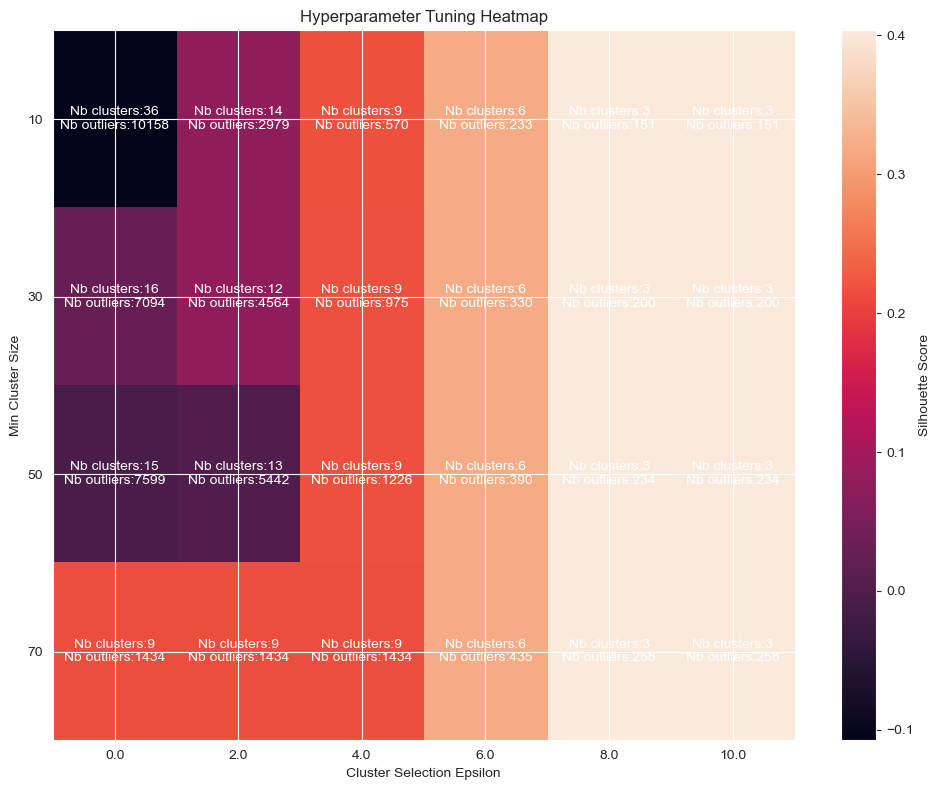

In [87]:
# Let's plot the heatmap
plot_hyperparameter_tuning_heatmap(score_list, min_cluster_size_list, cluster_selection_epsilon_list, nb_clusters_list, nb_outliers_list)

### Analysing the gridsearch
The insights given by the gridsearch analysis shows us that the min cluster size does not really influence the results for good ones. Moreover, the cluster selection epsilon permits to drastically decrease the number of clusters and increase the silhouette score. It is up to us to decide which number of clusters best represent what we want to show:
- Nb clusters 6 (with outliers): This is the most number of clusters we can have with a 'correct' silhouette score (0.32). Since this is an acceptable score, the clusters are however not really well separated.
- Nb clusters 3 (with outliers): With a silhouette score of 0.40, this is the best we could have. We have now to decide if three clusters suffices to extract interesting behaviors.

### Fit and analyse the clusters
Now that we found some good hyperparameters, let's visualize the 3 and 6 clusters and analyse those.

In [88]:
# Fit for 6 clusters
entire_dataset_6clusters, entire_dataset_6clusters_centroids = init_fit_hdbscan_clustering(X_scaled_final_clustering, min_cluster_size=30, cluster_selection_epsilon=6.0)

Model fitted. Num of clusters found: 5
Labels and probabilities added


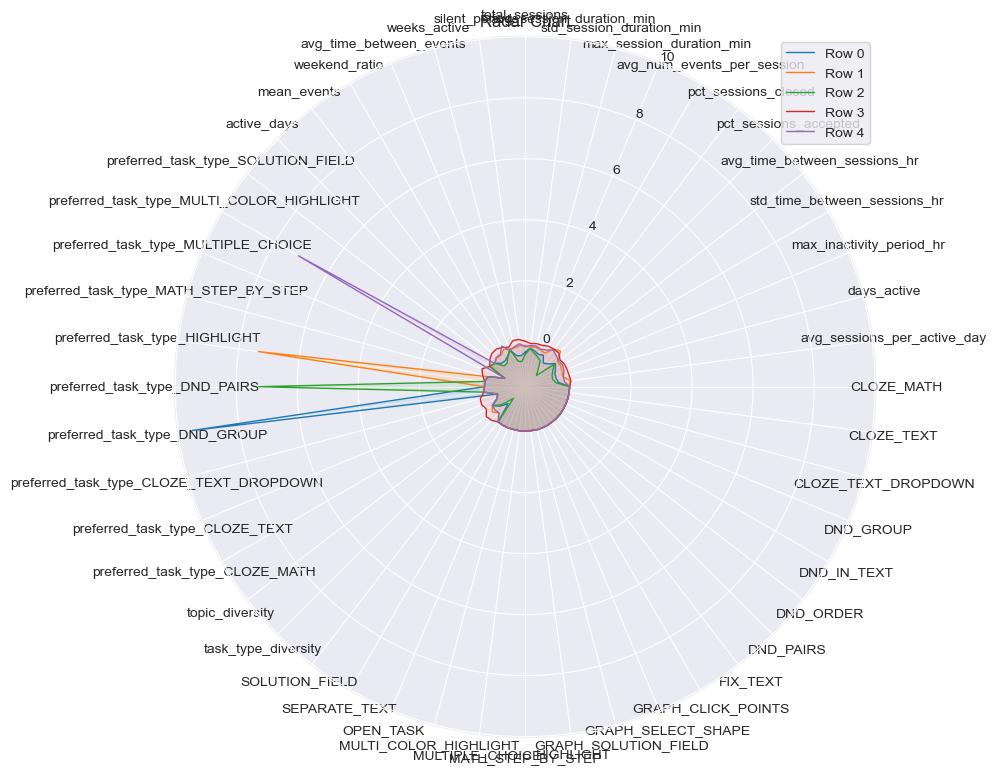

In [89]:
# Create radar chart
create_radar_chart(entire_dataset_6clusters_centroids)

In [90]:
# Count the number of samples per cluster
entire_dataset_6clusters['labels'].value_counts()

labels
 3    17430
 1      350
 2      339
-1      330
 4      315
 0      180
Name: count, dtype: int64

Model fitted. Num of clusters found: 2
Labels and probabilities added


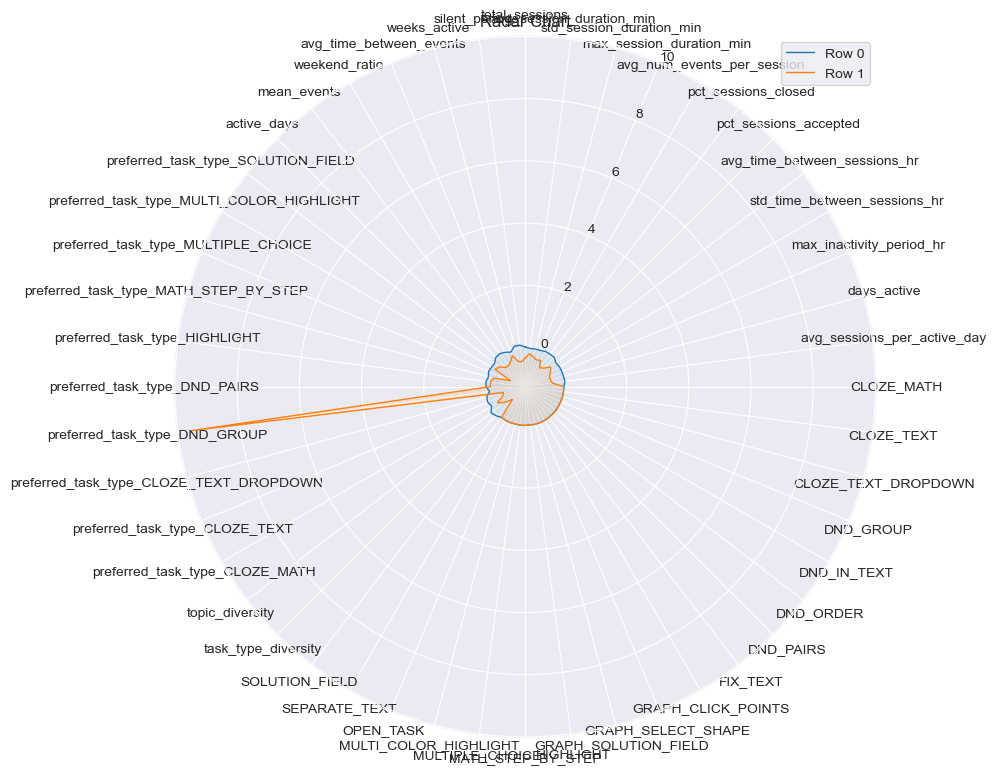

In [91]:
# Fit and plot for the 3-clusters
entire_dataset_3clusters, entire_dataset_3clusters_centroids = init_fit_hdbscan_clustering(X_scaled_final_clustering, min_cluster_size=30, cluster_selection_epsilon=8.0)
create_radar_chart(entire_dataset_3clusters_centroids)

In [92]:
# Count the number of samples in each cluster
entire_dataset_3clusters['labels'].value_counts()

labels
 0    18564
-1      200
 1      180
Name: count, dtype: int64

#### Analysis
We directly see that the clusters are defined mainly by one value. It makes sense since the 'preferred_*' columns are binary values, hence samples being similar here will have exactly the same value, which is confusing HDBSCAN. Therefore, we cannot extract a lot of meaningful information from these graphs.

### For dataset without preferred columns

We saw that the columns 'preferred_*' are mainly determining the clusters. To counter this, we could just remove these columns.

In [93]:
# We drop the 'preferred_*' columns
X_without_preferred = X_scaled_final_clustering.drop(['preferred_task_type_MULTI_COLOR_HIGHLIGHT', 'preferred_task_type_CLOZE_MATH', 'preferred_task_type_CLOZE_TEXT', 'preferred_task_type_CLOZE_TEXT_DROPDOWN', 'preferred_task_type_DND_GROUP', 'preferred_task_type_DND_PAIRS', 'preferred_task_type_HIGHLIGHT', 'preferred_task_type_MATH_STEP_BY_STEP', 'preferred_task_type_MULTIPLE_CHOICE', 'preferred_task_type_SOLUTION_FIELD'], axis=1)

In [94]:
X_without_preferred.head()

,total_sessions,avg_session_duration_min,std_session_duration_min,max_session_duration_min,avg_num_events_per_session,pct_sessions_closed,pct_sessions_accepted,avg_time_between_sessions_hr,std_time_between_sessions_hr,max_inactivity_period_hr,...,SEPARATE_TEXT,SOLUTION_FIELD,task_type_diversity,topic_diversity,active_days,mean_events,weekend_ratio,avg_time_between_events,weeks_active,silent_periods
0,2.178260,0.040976,1.091944,3.761500,0.114304,0.591600,0.156031,-0.027532,0.017587,0.189341,...,-0.009419,-0.016841,1.625654,2.142324,11.997447,5.806972,-0.183118,-0.325153,8.649997,6.477566
1,2.445658,0.468185,1.881149,4.092042,-0.519263,0.598772,0.574557,-0.088120,0.066162,0.865307,...,-0.009491,-0.016744,3.383740,4.961839,6.115191,3.930310,0.603994,-0.304138,6.354716,8.630960
2,0.841269,0.013797,0.529834,1.386367,-0.154392,0.648977,0.574557,0.226730,0.463874,0.832133,...,-0.009574,-0.016784,1.039625,1.708553,10.335071,2.354826,0.291138,-0.243549,9.415091,6.908245
3,-0.362023,-0.291957,-0.415370,-0.485347,-0.818458,-0.154303,0.574557,0.272961,0.168855,-0.102089,...,-0.009574,-0.016779,-1.304490,-0.026533,-0.150690,-0.360828,0.061465,1.484182,-0.021065,0.448063
4,-0.451156,-0.291734,-0.415368,-0.485275,0.643939,0.648977,0.574557,-0.355972,-0.507214,-0.595344,...,-0.009425,-0.016841,-1.011476,-0.677190,0.744436,0.046646,0.378964,0.410925,0.999060,0.878742


In [95]:
# Initialize the parameters to be tuned
min_cluster_size_list = [10, 20, 30, 40, 50, 60]
cluster_selection_epsilon_list = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]

# Perform hyperparameters tuning for the entire dataset
score_list, nb_clusters_list, nb_outliers_list = run_hdbscan_grid_search(X_without_preferred, min_cluster_size_list, cluster_selection_epsilon_list)

For min_cluster_size=10 and cluster_selection_epsilon=0.0:
	Nb clusters: 40
	Nb outliers: 12718
	Silhouette score: -0.1710048450387071
For min_cluster_size=10 and cluster_selection_epsilon=1.0:
	Nb clusters: 10
	Nb outliers: 10187
	Silhouette score: -0.002523759296150533
For min_cluster_size=10 and cluster_selection_epsilon=2.0:
	Nb clusters: 5
	Nb outliers: 1867
	Silhouette score: 0.502493466023574
For min_cluster_size=10 and cluster_selection_epsilon=3.0:
	Nb clusters: 3
	Nb outliers: 747
	Silhouette score: 0.5796554558214182
For min_cluster_size=10 and cluster_selection_epsilon=4.0:
	Nb clusters: 3
	Nb outliers: 747
	Silhouette score: 0.5796554558214182
For min_cluster_size=10 and cluster_selection_epsilon=5.0:
	Nb clusters: 3
	Nb outliers: 747
	Silhouette score: 0.5796554558214182
-----------------------------------
For min_cluster_size=20 and cluster_selection_epsilon=0.0:
	Nb clusters: 11
	Nb outliers: 13384
	Silhouette score: -0.1271829680965607
For min_cluster_size=20 and clust

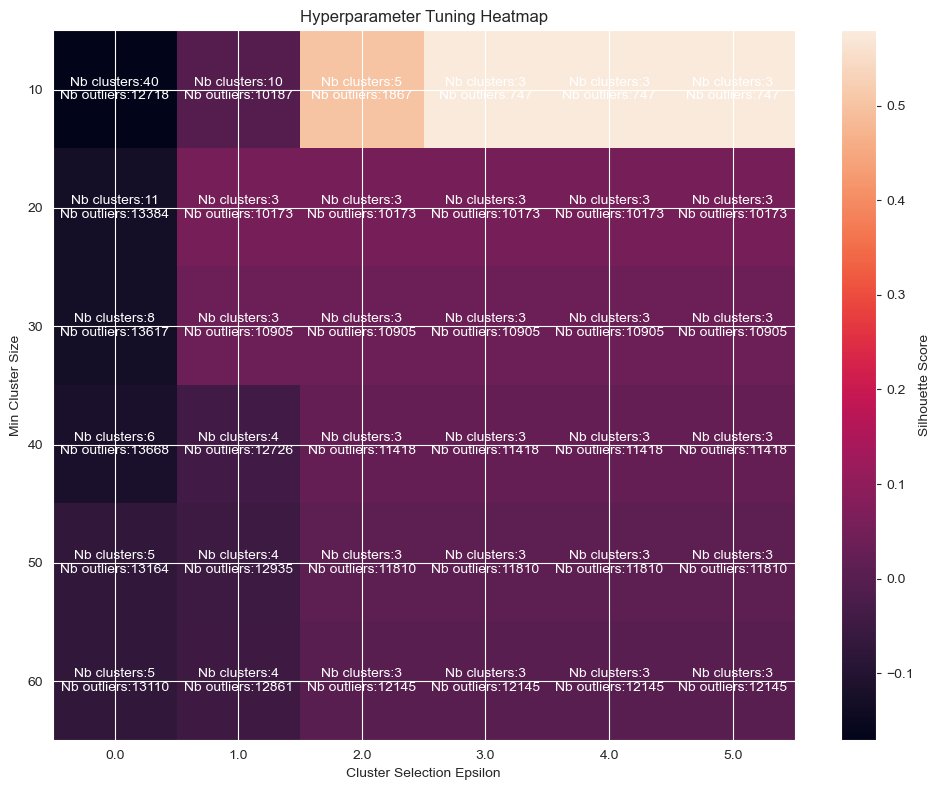

In [96]:
# Plot the hyperparameter heatmap
plot_hyperparameter_tuning_heatmap(score_list, min_cluster_size_list, cluster_selection_epsilon_list, nb_clusters_list, nb_outliers_list)

Model fitted. Num of clusters found: 4
Labels and probabilities added


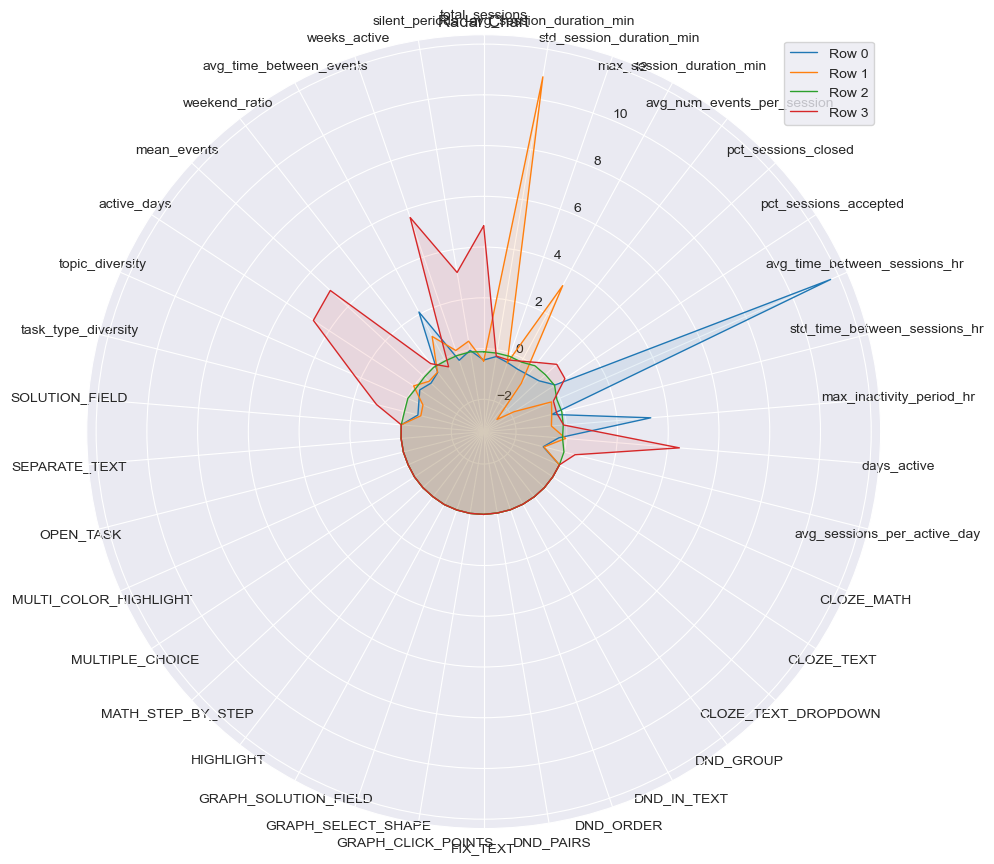

In [97]:
# Fit the data and plot the centroids
without_preferred_clusters5, without_preferred_clusters_centroids5 = init_fit_hdbscan_clustering(X_without_preferred, min_cluster_size=10, cluster_selection_epsilon=2.0)
create_radar_chart(without_preferred_clusters_centroids5)

In [98]:
# Count the number of samples in each cluster
without_preferred_clusters5['labels'].value_counts()

labels
 2    17015
-1     1867
 3       40
 1       12
 0       10
Name: count, dtype: int64

Model fitted. Num of clusters found: 2
Labels and probabilities added


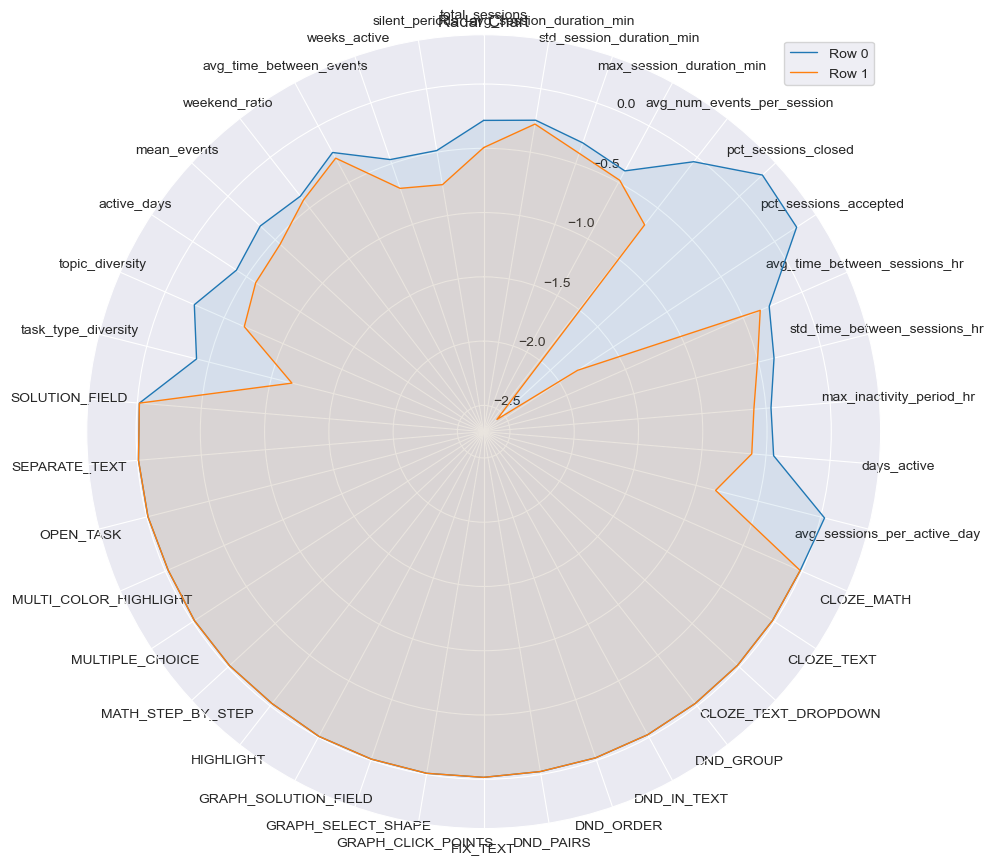

In [99]:
# Fit the data and plot the centroids
without_preferred_clusters3, without_preferred_clusters3_centroids = init_fit_hdbscan_clustering(X_without_preferred, min_cluster_size=20, cluster_selection_epsilon=1.0)
create_radar_chart(without_preferred_clusters3_centroids)

In [100]:
# Count the number of samples in each cluster
without_preferred_clusters3['labels'].value_counts()

labels
-1    10173
 0     7628
 1     1143
Name: count, dtype: int64

#### Analysis
HDBSCAN did separate some clusters. However, the clusterer often follows the same pattern: it puts all the 'standard' samples in one big cluster, declare some outliers and put small groups of quite similar outliers in some other clusters. This is not really what we are looking for. An hypothesis would be that we are clustering on too many features. Considering the curse of dimensionality, this can give a hard time to the clusterer.

### For session-based features

As the curse of dimensionality could worsen the clusterer we fit HDBSCAN on the themed features computed before. Namely : session features performance features, temporal features and consistency features.

In [101]:
session_df = final_session_features.drop(columns=['user_id'])
user_ids_session = final_session_features['user_id']
# We drop features that where dropped in the original feature selection
columns_to_drop = [
    'min_session_duration_min',
    'median_session_duration_min'
]
session_df.drop(columns=columns_to_drop, inplace=True)
# Remove very low-variance features (threshold = 0.01 is common)
selector = VarianceThreshold(threshold=0.01)
session_features_selected = selector.fit_transform(session_df)
session_column_selected = session_df.columns[selector.get_support()]
session_df = pd.DataFrame(session_features_selected, columns=session_column_selected)

session_scaled_df = scaler.fit_transform(session_df)
session_scaled_df = pd.DataFrame(session_scaled_df, columns=session_df.columns)

In [102]:
# Initialize the parameters to be tuned
min_cluster_size_list = [10, 20, 30, 40]
cluster_selection_epsilon_list = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]

# Perform hyperparameters tuning for the entire dataset
score_list, nb_clusters_list, nb_outliers_list = run_hdbscan_grid_search(session_scaled_df, min_cluster_size_list, cluster_selection_epsilon_list)

For min_cluster_size=10 and cluster_selection_epsilon=0.0:
	Nb clusters: 152
	Nb outliers: 15002
	Silhouette score: -0.339502399688464
For min_cluster_size=10 and cluster_selection_epsilon=1.0:
	Nb clusters: 7
	Nb outliers: 2793
	Silhouette score: 0.1892491510647844
For min_cluster_size=10 and cluster_selection_epsilon=2.0:
	Nb clusters: 3
	Nb outliers: 310
	Silhouette score: 0.6541428643737165
For min_cluster_size=10 and cluster_selection_epsilon=3.0:
	Nb clusters: 3
	Nb outliers: 310
	Silhouette score: 0.6541428643737165
For min_cluster_size=10 and cluster_selection_epsilon=4.0:
	Nb clusters: 3
	Nb outliers: 310
	Silhouette score: 0.6541428643737165
For min_cluster_size=10 and cluster_selection_epsilon=5.0:
	Nb clusters: 3
	Nb outliers: 310
	Silhouette score: 0.6541428643737165
-----------------------------------
For min_cluster_size=20 and cluster_selection_epsilon=0.0:
	Nb clusters: 62
	Nb outliers: 14783
	Silhouette score: -0.25009191424519084
For min_cluster_size=20 and cluster_s

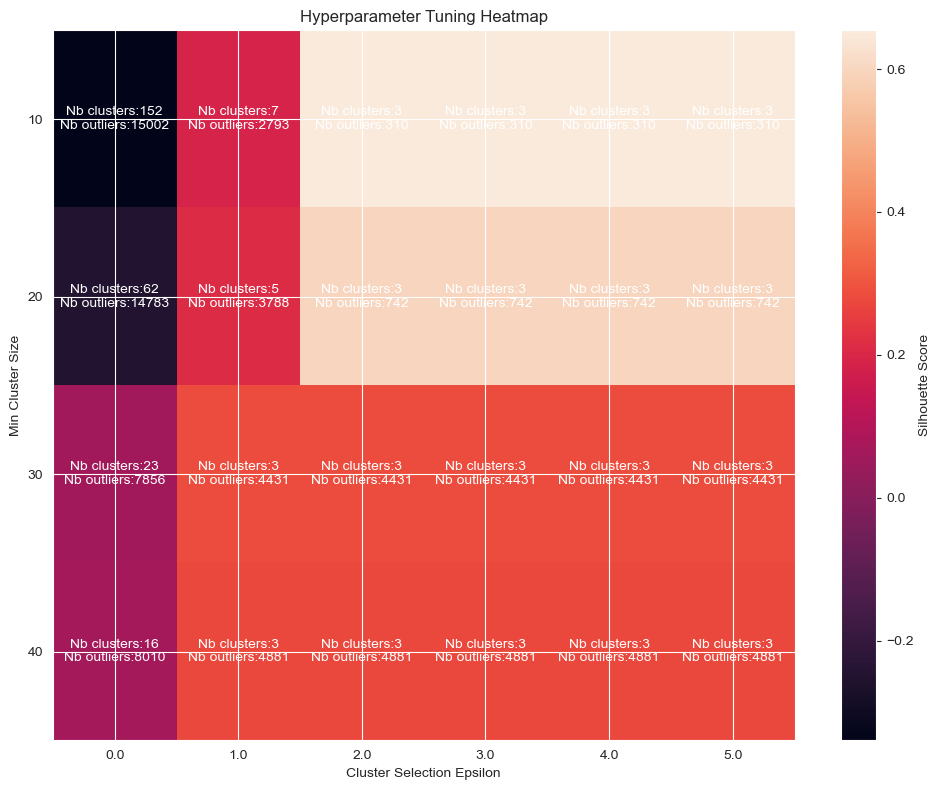

In [103]:
plot_hyperparameter_tuning_heatmap(score_list, min_cluster_size_list, cluster_selection_epsilon_list, nb_clusters_list, nb_outliers_list)

Model fitted. Num of clusters found: 4
Labels and probabilities added


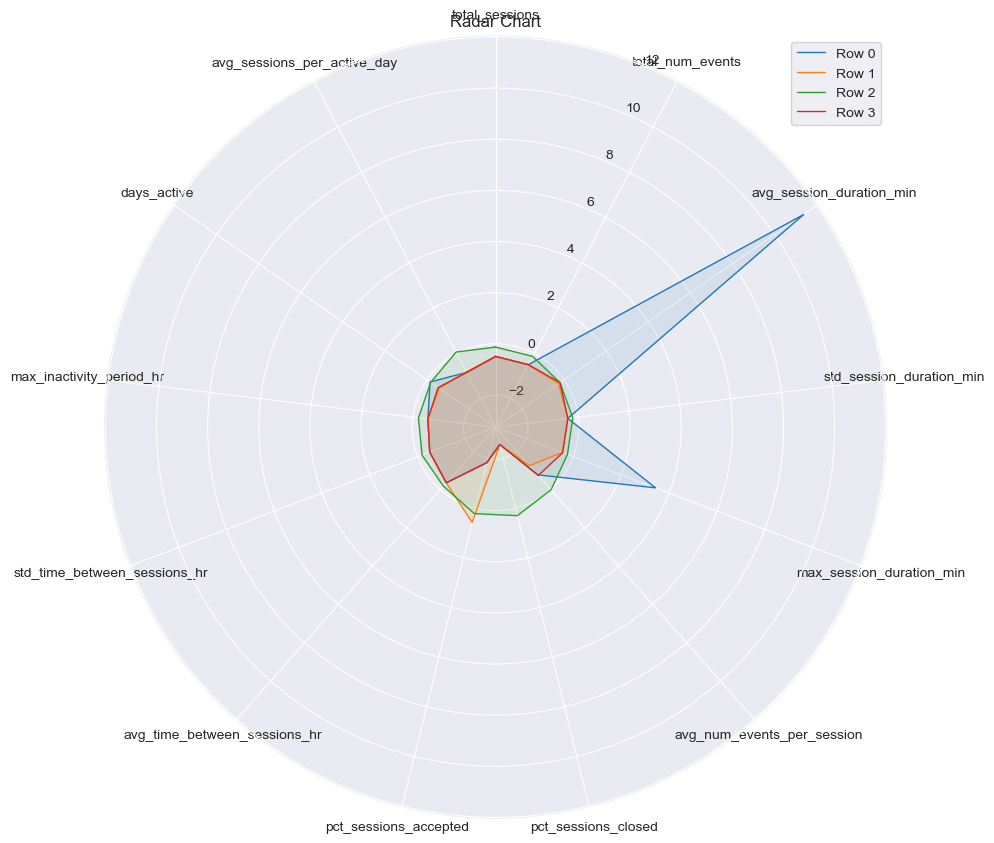

In [104]:
session_clusters5, session_clusters5_centroids = init_fit_hdbscan_clustering(session_scaled_df, min_cluster_size=20, cluster_selection_epsilon=1.0)
create_radar_chart(session_clusters5_centroids)

In [105]:
session_clusters5['labels'].value_counts()

labels
 2    13921
-1     3788
 3     1866
 0       29
 1       26
Name: count, dtype: int64

Model fitted. Num of clusters found: 2
Labels and probabilities added


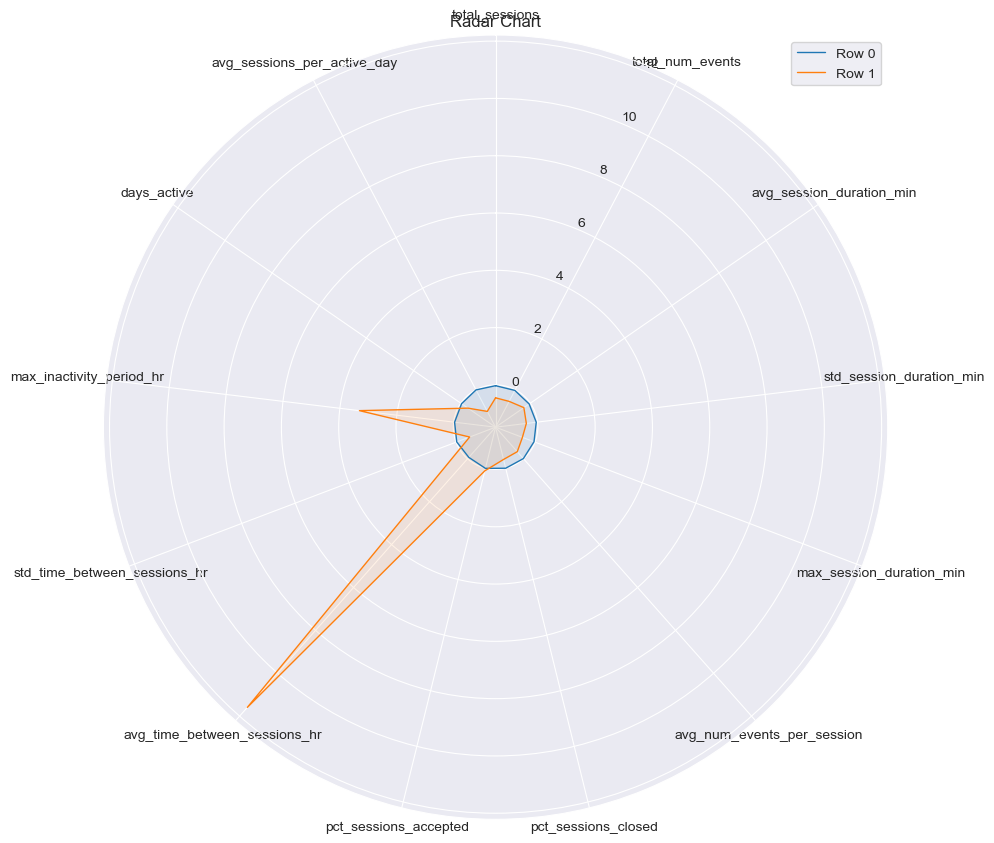

In [106]:
session_clusters3, session_clusters3_centroids = init_fit_hdbscan_clustering(session_scaled_df, min_cluster_size=10, cluster_selection_epsilon=2.0)
create_radar_chart(session_clusters3_centroids)

In [107]:
session_clusters3['labels'].value_counts()

labels
 0    19310
-1      310
 1       10
Name: count, dtype: int64

#### Analysis
The same pattern occured. The most of the samples are inside a big cluster and the outliers are sometimes in small groups...
However, the model still found a quite interesting cluster. One of the five clusters the clusterer found contains a non negligible number of people who tends to have some smaller values for the ensemble of the features, particularly for the percentage of closed et accepted sessions.

### For Transaction Features

In [108]:
performance_df = performance_features.drop(columns=['user_id'])
user_ids_performance = performance_features['user_id']
performance_df = process_features(performance_df)

# Initialize the parameters to be tuned
min_cluster_size_list = [10, 20, 30, 40]
cluster_selection_epsilon_list = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]

# Perform hyperparameters tuning for the entire dataset
score_list, nb_clusters_list, nb_outliers_list = run_hdbscan_grid_search(performance_df, min_cluster_size_list, cluster_selection_epsilon_list)

For min_cluster_size=10 and cluster_selection_epsilon=0.0:
	Nb clusters: 487
	Nb outliers: 3245
	Silhouette score: 0.6693500679076234
For min_cluster_size=10 and cluster_selection_epsilon=1.0:
	Nb clusters: 12
	Nb outliers: 258
	Silhouette score: 0.49114737509194106
For min_cluster_size=10 and cluster_selection_epsilon=2.0:
	Nb clusters: 12
	Nb outliers: 258
	Silhouette score: 0.49114737509194106
For min_cluster_size=10 and cluster_selection_epsilon=3.0:
	Nb clusters: 9
	Nb outliers: 188
	Silhouette score: 0.5022342345638834
For min_cluster_size=10 and cluster_selection_epsilon=4.0:
	Nb clusters: 9
	Nb outliers: 188
	Silhouette score: 0.5022342345638834
For min_cluster_size=10 and cluster_selection_epsilon=5.0:
	Nb clusters: 7
	Nb outliers: 182
	Silhouette score: 0.4468564862574535
-----------------------------------
For min_cluster_size=20 and cluster_selection_epsilon=0.0:
	Nb clusters: 298
	Nb outliers: 4972
	Silhouette score: 0.48840042444544296
For min_cluster_size=20 and cluster_

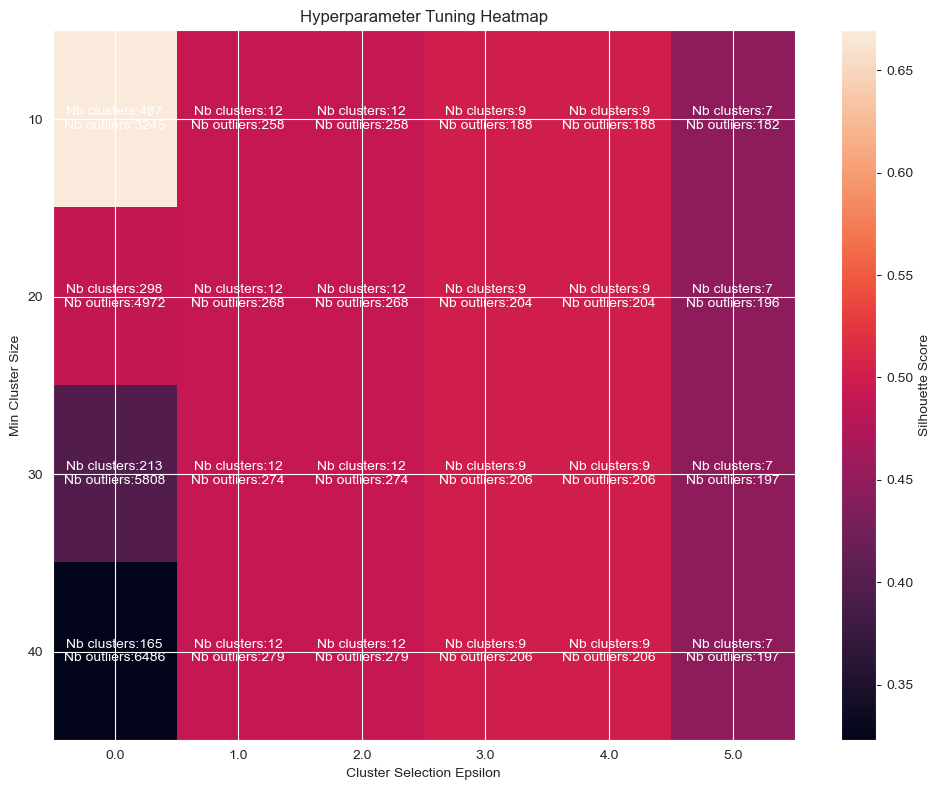

In [109]:
plot_hyperparameter_tuning_heatmap(score_list, min_cluster_size_list, cluster_selection_epsilon_list, nb_clusters_list, nb_outliers_list)

Model fitted. Num of clusters found: 8
Labels and probabilities added


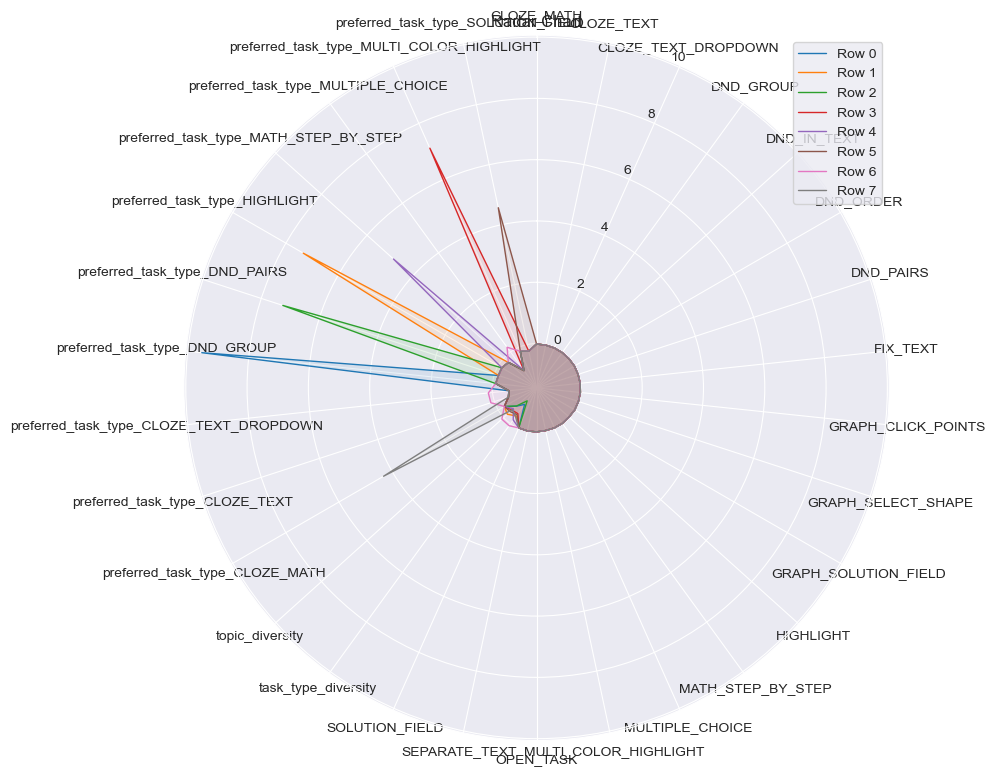

In [110]:
performance_clusters9, performance_clusters9_centroids = init_fit_hdbscan_clustering(performance_df, min_cluster_size=10, cluster_selection_epsilon=3.0)
create_radar_chart(performance_clusters9_centroids)

In [111]:
performance_clusters9['labels'].value_counts()

labels
 6    16905
 7     1077
 5      973
 4      870
 3      410
 2      392
 1      387
 0      231
-1      188
Name: count, dtype: int64

#### Analysis
No surprise here, the results are even worse since this set contains some binary values. However, the clusters contains more sample than previously which is a good beginning.

### Using Temporal Features

In [112]:
temporal_df = temporal_final_clean.drop(columns=['user_id'])
user_ids_temporal = temporal_final_clean['user_id']
temporal_df = process_features(temporal_df)

# Initialize the parameters to be tuned
min_cluster_size_list = [10, 30, 50, 70]
cluster_selection_epsilon_list = [0.0, 0.5, 1.0, 1.5, 2.0]

# Perform hyperparameters tuning for the entire dataset
score_list, nb_clusters_list, nb_outliers_list = run_hdbscan_grid_search(temporal_df, min_cluster_size_list, cluster_selection_epsilon_list)

For min_cluster_size=10 and cluster_selection_epsilon=0.0:
	Nb clusters: 222
	Nb outliers: 10846
	Silhouette score: -0.3236068395560973
For min_cluster_size=10 and cluster_selection_epsilon=0.5:
	Nb clusters: 3
	Nb outliers: 2636
	Silhouette score: 0.3778855573284578
For min_cluster_size=10 and cluster_selection_epsilon=1.0:
	Nb clusters: 3
	Nb outliers: 2636
	Silhouette score: 0.3778855573284578
For min_cluster_size=10 and cluster_selection_epsilon=1.5:
	Nb clusters: 3
	Nb outliers: 2636
	Silhouette score: 0.3778855573284578
For min_cluster_size=10 and cluster_selection_epsilon=2.0:
	Nb clusters: 3
	Nb outliers: 2636
	Silhouette score: 0.3778855573284578
-----------------------------------
For min_cluster_size=30 and cluster_selection_epsilon=0.0:
	Nb clusters: 18
	Nb outliers: 12225
	Silhouette score: -0.26226258810261416
For min_cluster_size=30 and cluster_selection_epsilon=0.5:
	Nb clusters: 3
	Nb outliers: 3891
	Silhouette score: 0.5458800518642958
For min_cluster_size=30 and clus

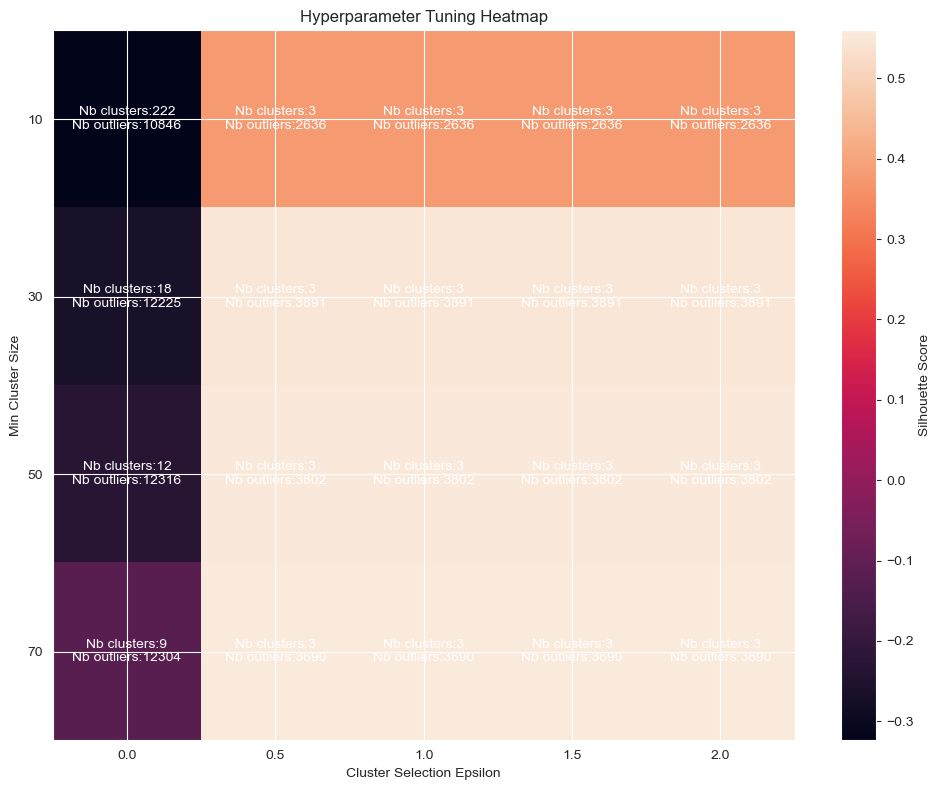

In [113]:
plot_hyperparameter_tuning_heatmap(score_list, min_cluster_size_list, cluster_selection_epsilon_list, nb_clusters_list, nb_outliers_list)

Model fitted. Num of clusters found: 2
Labels and probabilities added


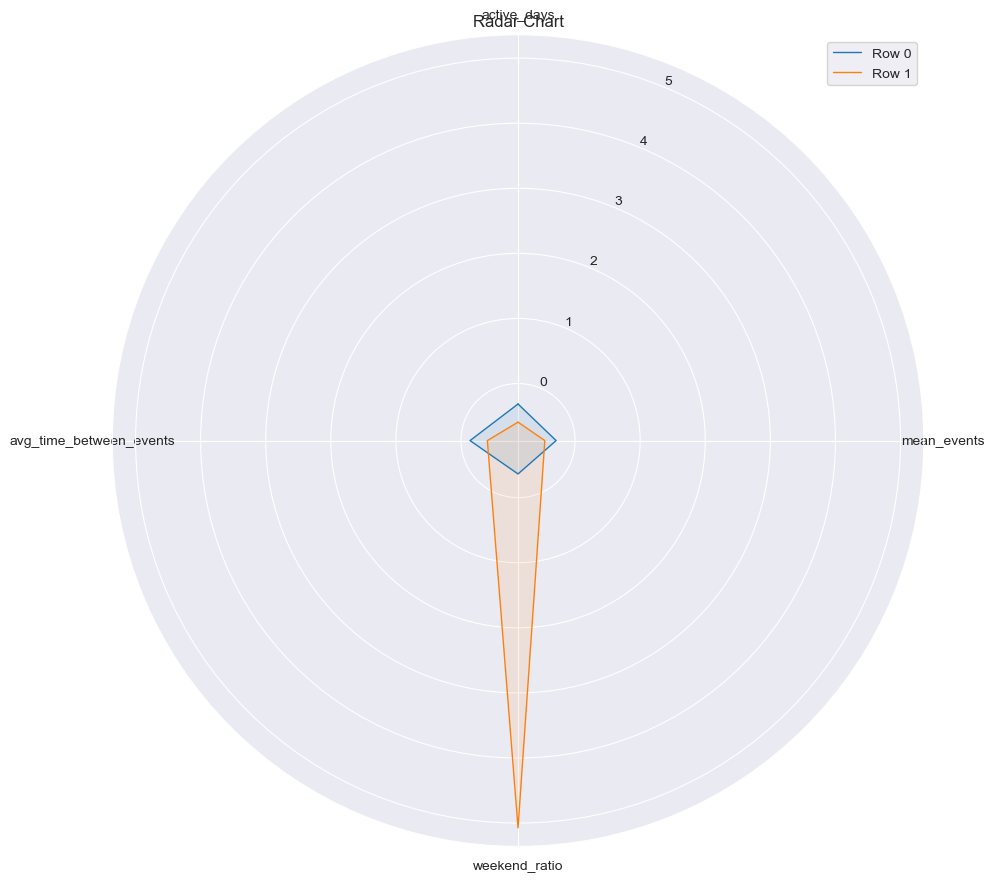

In [114]:
temporal_clusters3, temporal_clusters3_centroids = init_fit_hdbscan_clustering(temporal_df, min_cluster_size=70, cluster_selection_epsilon=0.5)
create_radar_chart(temporal_clusters3_centroids)

In [115]:
temporal_clusters3['labels'].value_counts()

labels
 0    18613
-1     3690
 1      167
Name: count, dtype: int64

#### Analysis
Again the same...

### Using consistency features

In [116]:
consistency_df = consistency_features.drop(columns=['user_id'])
user_ids_consistency = consistency_features['user_id']
consistency_df = process_features(consistency_df)

# Initialize the parameters to be tuned
min_cluster_size_list = [10, 30, 50, 70]
cluster_selection_epsilon_list = [0.0, 0.5, 1.0, 1.5, 2.0]

# Perform hyperparameters tuning for the entire dataset
score_list, nb_clusters_list, nb_outliers_list = run_hdbscan_grid_search(consistency_df, min_cluster_size_list, cluster_selection_epsilon_list)

For min_cluster_size=10 and cluster_selection_epsilon=0.0:
	Nb clusters: 100
	Nb outliers: 306
	Silhouette score: 0.9675339818531676
For min_cluster_size=10 and cluster_selection_epsilon=0.5:
	Nb clusters: 3
	Nb outliers: 110
	Silhouette score: 0.7672264954453613
For min_cluster_size=10 and cluster_selection_epsilon=1.0:
	Nb clusters: 3
	Nb outliers: 110
	Silhouette score: 0.7672264954453613
For min_cluster_size=10 and cluster_selection_epsilon=1.5:
	Nb clusters: 3
	Nb outliers: 110
	Silhouette score: 0.7672264954453613
For min_cluster_size=10 and cluster_selection_epsilon=2.0:
	Nb clusters: 3
	Nb outliers: 110
	Silhouette score: 0.7672264954453613
-----------------------------------
For min_cluster_size=30 and cluster_selection_epsilon=0.0:
	Nb clusters: 58
	Nb outliers: 698
	Silhouette score: 0.9264990590703964
For min_cluster_size=30 and cluster_selection_epsilon=0.5:
	Nb clusters: 3
	Nb outliers: 147
	Silhouette score: 0.7672931273655291
For min_cluster_size=30 and cluster_selectio

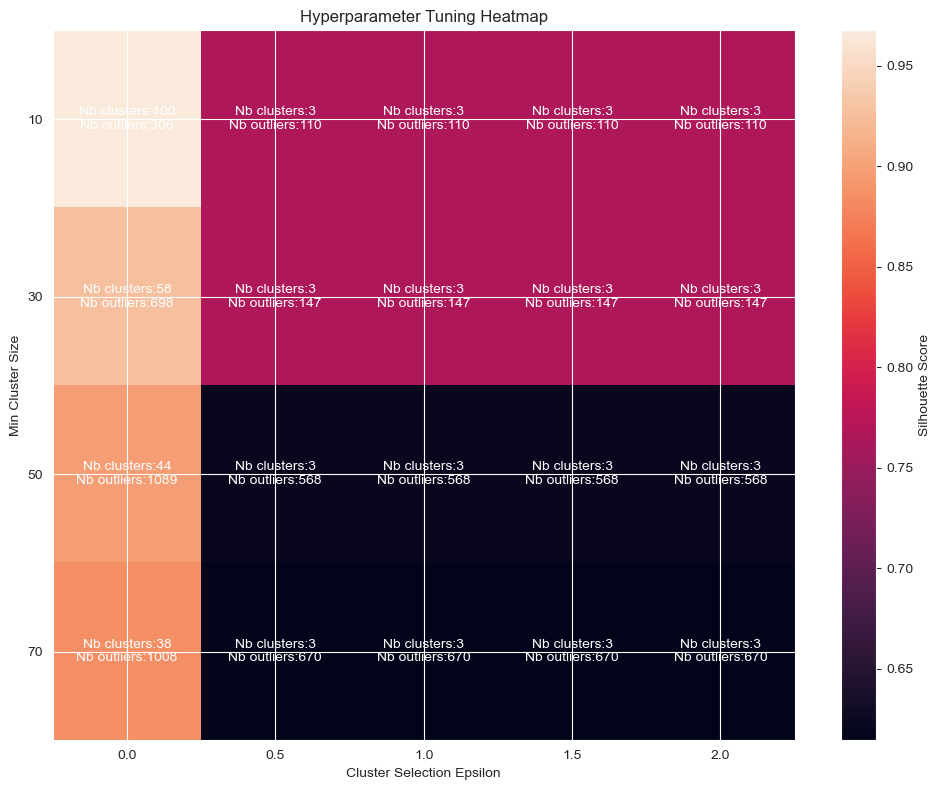

In [117]:
plot_hyperparameter_tuning_heatmap(score_list, min_cluster_size_list, cluster_selection_epsilon_list, nb_clusters_list, nb_outliers_list)

In [118]:
# Consistency only has 2 features, so radar chart is not great, we will use scatterplots instead.
consistency_df.head()

,weeks_active,silent_periods
0,8.649997,6.477566
1,6.354716,8.630960
2,9.415091,6.908245
3,-0.021065,0.448063
4,0.999060,0.878742


Model fitted. Num of clusters found: 2
Labels and probabilities added


[Text(0.5, 1.0, 'cluster distribution for consistency features')]

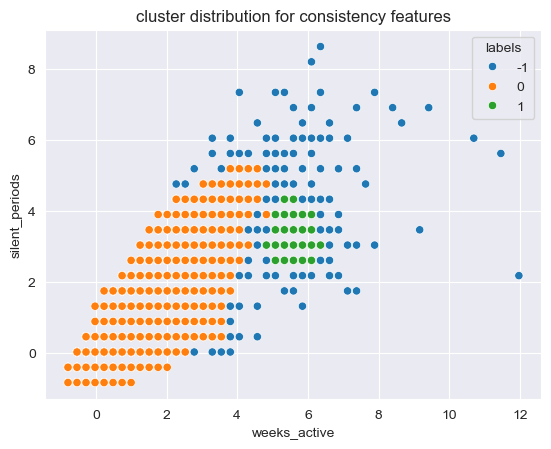

In [119]:
consistency_clusters3, consistency_clusters3_centroids = init_fit_hdbscan_clustering(consistency_df, min_cluster_size=20, cluster_selection_epsilon=1.0)
sns.scatterplot(x = 'weeks_active', y='silent_periods', hue='labels', data = consistency_clusters3.drop('probabilities', axis=1), palette = 'tab10').set(title='cluster distribution for consistency features')

In [120]:
consistency_clusters3['labels'].value_counts()

labels
 0    22267
-1      141
 1       62
Name: count, dtype: int64

In [121]:
consistency_clusters76, consistency_clusters76_centroids = init_fit_hdbscan_clustering(consistency_df, min_cluster_size=20, cluster_selection_epsilon=0.0)

Model fitted. Num of clusters found: 75
Labels and probabilities added


C:\Users\fleur\AppData\Local\Temp\ipykernel_86060\1496467413.py:2: UserWarning: 
The palette list has fewer values (25) than needed (76) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(x = 'weeks_active', y='silent_periods', hue='labels', data = consistency_clusters76.drop('probabilities', axis=1), palette=custom_palette).set(title='cluster distribution for consistency features')


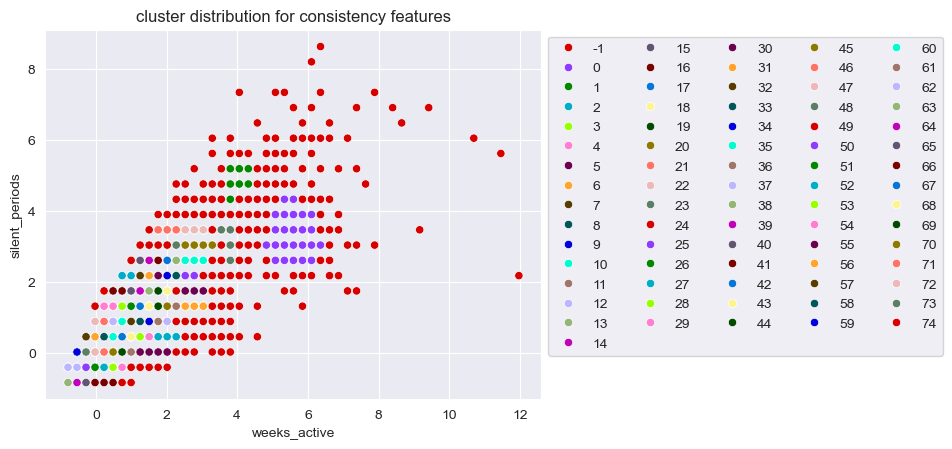

In [122]:
custom_palette = sns.color_palette(cc.glasbey, n_colors=25)
sns.scatterplot(x = 'weeks_active', y='silent_periods', hue='labels', data = consistency_clusters76.drop('probabilities', axis=1), palette=custom_palette).set(title='cluster distribution for consistency features')
plt.legend(ncol=5, bbox_to_anchor=(1, 1))
plt.show()

In [123]:
consistency_clusters76['labels'].value_counts()

labels
13    5355
12    3312
23    1734
25    1347
14    1236
      ... 
48      20
74      20
1       20
7       20
62      20
Name: count, Length: 76, dtype: int64

#### Analysis
The model is again not finding really meaningful clusters. We can see that the cluster 1 from the case with 3 cluster is still there, but the big cluster is now split into a lot of sub-clusters.

## Reducing the number of features, PCA approach
We saw previously that the curse of dimensionality is quite annoying. We need to reduce the dimensionality of our set by a meaningful manner. A good way to do this is PCA. We will use PCA to get the principal components of our data and use only the most meaningful ones.

In [124]:
# Declare the model and fit our data
pca = PCA()
pca_result = pca.fit_transform(X_scaled_final_clustering)

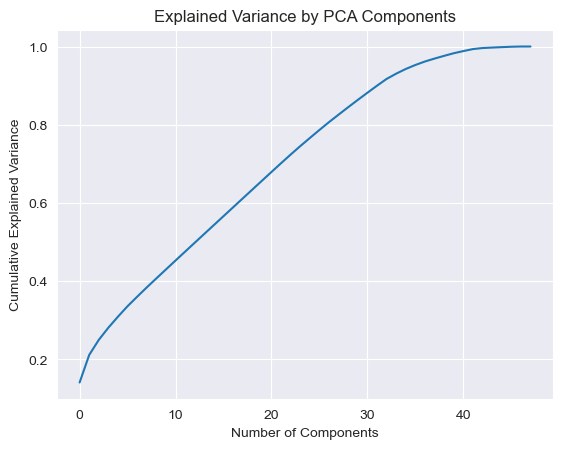

In [125]:
# Plot the variance by PCA components
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.show()

No elbow, it needs around 25 components to explain 80% of the variance, it is approx. linear until 30 components then it gets a bit more flat => clustering on the 30 PC to get rid of a few features

In [126]:
# We load the principal components composition
loadings = pd.DataFrame(
    pca.components_.T,  # shape: [n_features, n_components]
    columns=[f'PC{i+1}' for i in range(X_scaled_final_clustering.shape[1])],
    index=X_scaled_final_clustering.columns
)

In [127]:
loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC39,PC40,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48
total_sessions,0.281145,-0.197447,-0.008217,0.009022,0.191788,-0.027200,-0.044071,0.165169,-0.107200,0.036052,...,0.044140,0.079821,0.151241,-0.395572,-0.013764,-0.043647,-0.461822,-0.391583,0.010335,2.453917e-15
avg_session_duration_min,0.040385,0.321418,-0.140242,-0.098529,0.322948,-0.192350,-0.076320,-0.094993,0.074407,0.024192,...,0.273891,0.616024,0.018495,0.047914,-0.056070,-0.140847,0.011272,-0.009170,0.001174,4.311326e-16
std_session_duration_min,0.120211,0.408352,0.046098,-0.079662,0.218674,-0.118493,-0.079981,-0.052338,-0.031021,-0.052528,...,-0.180078,-0.427943,-0.091119,-0.048489,-0.414020,-0.451668,0.046938,-0.037280,0.004095,-7.843388e-16
max_session_duration_min,0.175213,0.363395,0.019662,-0.062941,0.277528,-0.141912,-0.096900,-0.059384,-0.009324,-0.017276,...,-0.064601,-0.138217,0.044904,0.009438,0.452908,0.574617,-0.062030,0.051436,-0.003634,6.049093e-16
avg_num_events_per_session,0.041923,-0.061378,0.222234,-0.392608,-0.190105,-0.137720,-0.011500,-0.121469,0.209183,-0.037276,...,-0.163978,-0.034957,0.132962,0.141773,-0.012704,-0.004562,-0.039199,-0.012734,0.003357,7.390958e-17
pct_sessions_closed,0.143162,-0.085293,0.398811,-0.008767,-0.044754,-0.050164,0.015512,-0.052989,0.059490,-0.005538,...,-0.544295,0.400604,-0.097400,-0.047899,0.016680,0.012913,0.002282,-0.004256,0.001714,4.729706e-16
pct_sessions_accepted,0.135630,-0.065796,0.446984,-0.057678,-0.072631,-0.070613,0.001250,-0.081636,0.083162,0.001024,...,0.699632,-0.202043,0.097806,-0.059190,0.027640,-0.006371,0.028132,0.007500,-0.007063,-3.629572e-16
avg_time_between_sessions_hr,0.076603,0.361724,0.091285,0.000374,-0.218808,0.143695,0.058385,0.126187,-0.057282,0.028616,...,-0.092624,-0.218908,0.081565,0.065190,0.026417,0.196883,-0.016967,-0.005747,-0.003275,-4.496375e-17
std_time_between_sessions_hr,0.143028,0.366942,0.191629,0.038212,-0.222399,0.168078,0.035292,0.106854,-0.034342,0.039749,...,0.115631,0.254798,-0.147131,-0.067710,-0.515343,0.341346,-0.024689,-0.032674,-0.007376,4.211015e-16
max_inactivity_period_hr,0.206594,0.327195,0.194406,0.046687,-0.182595,0.160659,0.038462,0.125281,-0.057875,0.035966,...,0.026889,0.143339,0.034231,0.043781,0.538746,-0.530588,0.030142,0.060463,0.006719,-3.663787e-16


In [128]:
# We apply PCA with 30 components on our dataset
pca30 = PCA(n_components=30)
pca30_result = pca30.fit_transform(X_scaled_final_clustering)

In [129]:
pca30_result

array([[ 1.75697810e+01, -1.82466200e+00, -8.67863435e+00, ...,
         3.96636970e-01, -1.19158178e+00,  9.67247434e-01],
       [ 1.45030608e+01, -1.66534937e-01, -4.79708340e+00, ...,
        -2.23078946e+00, -2.67620204e+00,  3.17064212e+00],
       [ 1.48062770e+01, -1.03448198e+00, -7.54437622e+00, ...,
         4.16729597e-01, -9.26825410e-01,  8.43206498e-01],
       ...,
       [-2.08967278e+00, -4.59643616e-01,  7.77451778e-01, ...,
         1.97261533e-01, -2.09750376e-01,  1.35953826e-01],
       [-2.79142292e+00, -9.50105933e-02, -1.22633584e+00, ...,
         1.53321003e-02, -1.14714542e-01, -3.98474340e-01],
       [-2.41458302e+00, -4.94424903e-01, -1.46827184e-01, ...,
        -3.89169189e-01, -3.08435495e-01,  2.80067691e-01]],
      shape=(18944, 30))

In [130]:
# Initialize the parameters to be tuned
min_cluster_size_list = [10, 30, 50, 70]
cluster_selection_epsilon_list = [0.0, 2.0, 4.0, 6.0, 8.0, 10.0]

# Perform hyperparameters tuning for the entire dataset
score_list, nb_clusters_list, nb_outliers_list = run_hdbscan_grid_search(pca30_result, min_cluster_size_list, cluster_selection_epsilon_list)

For min_cluster_size=10 and cluster_selection_epsilon=0.0:
	Nb clusters: 23
	Nb outliers: 5924
	Silhouette score: -0.03408751090743878
For min_cluster_size=10 and cluster_selection_epsilon=2.0:
	Nb clusters: 7
	Nb outliers: 475
	Silhouette score: 0.2290655974134945
For min_cluster_size=10 and cluster_selection_epsilon=4.0:
	Nb clusters: 6
	Nb outliers: 359
	Silhouette score: 0.2179677397290849
For min_cluster_size=10 and cluster_selection_epsilon=6.0:
	Nb clusters: 4
	Nb outliers: 202
	Silhouette score: 0.3351848855504773
For min_cluster_size=10 and cluster_selection_epsilon=8.0:
	Nb clusters: 3
	Nb outliers: 172
	Silhouette score: 0.36256409121744393
For min_cluster_size=10 and cluster_selection_epsilon=10.0:
	Nb clusters: 3
	Nb outliers: 172
	Silhouette score: 0.36256409121744393
-----------------------------------
For min_cluster_size=30 and cluster_selection_epsilon=0.0:
	Nb clusters: 11
	Nb outliers: 3858
	Silhouette score: 0.10157669974541712
For min_cluster_size=30 and cluster_s

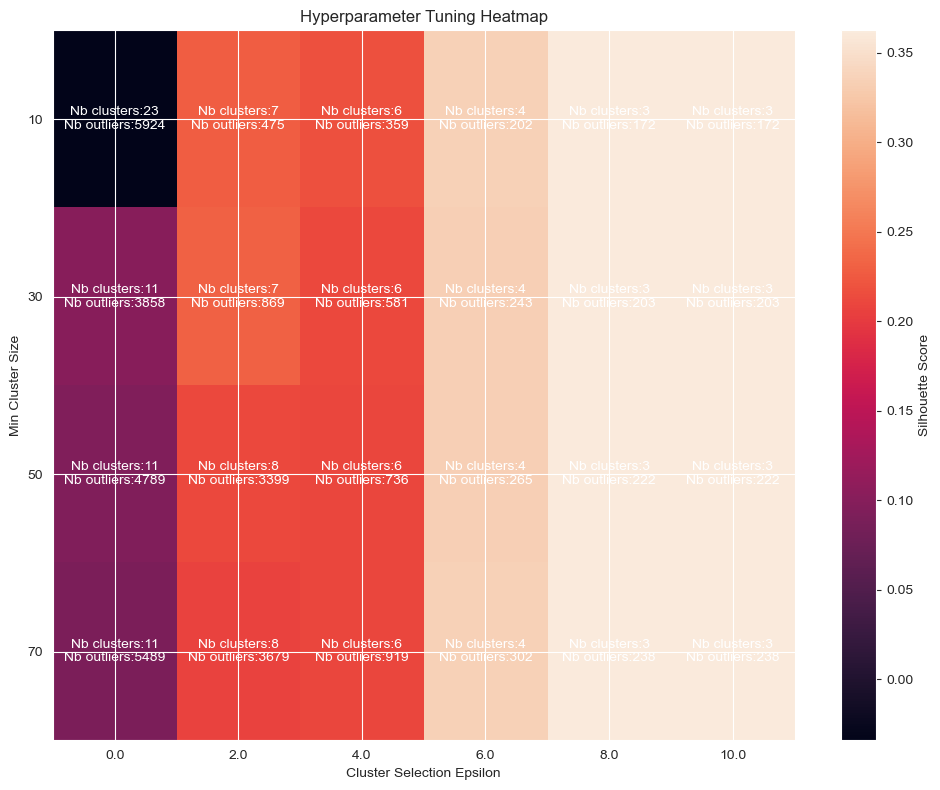

In [131]:
plot_hyperparameter_tuning_heatmap(score_list, min_cluster_size_list, cluster_selection_epsilon_list, nb_clusters_list, nb_outliers_list)

In [132]:
pca30_result_df = pd.DataFrame(pca30_result.T, [f'PC{i+1}' for i in np.arange(30)]).T
pca30_result_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30
0,17.569781,-1.824662,-8.678634,-0.682631,-1.184183,1.421139,0.612461,-1.985799,0.973956,-0.836440,...,0.679990,-0.232654,-1.473760,1.664760,-1.143253,0.059796,-1.398308,0.396637,-1.191582,0.967247
1,14.503061,-0.166535,-4.797083,0.225965,0.074511,-0.160290,-0.306235,-0.833661,-0.175830,-0.885689,...,0.222235,-0.205875,-0.007891,1.143853,-0.487160,0.447662,1.335142,-2.230789,-2.676202,3.170642
2,14.806277,-1.034482,-7.544376,1.737591,-3.522586,0.013071,0.817667,-1.906895,1.143408,-0.760937,...,0.315598,-0.447361,-1.441761,2.274915,-0.397912,0.731637,-1.276801,0.416730,-0.926825,0.843206
3,-1.039394,0.482316,-0.981767,0.451824,-0.548082,0.720363,0.041306,-0.216891,-0.287586,0.212173,...,0.225019,-0.032370,0.305084,0.328837,0.251645,0.360708,0.622271,-0.465113,-0.282027,0.049435
4,0.163972,-0.654488,-0.606474,1.097351,-1.054807,-0.622392,0.267624,-0.780184,0.635070,-0.276577,...,-0.024807,-0.128967,-0.763597,1.032737,-0.268146,0.398309,-0.433107,-0.028178,0.076579,0.070569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18939,-2.476631,-0.391075,-0.547444,1.887075,0.454478,-0.345260,0.085313,0.156640,-0.244161,0.040923,...,-0.146137,0.227696,-0.032444,-0.623885,-0.029015,-0.383288,-0.222004,0.050735,-0.139350,-0.304976
18940,-2.660875,-0.142655,-0.647441,1.704210,-0.110138,-0.324313,0.181345,-0.173593,0.025147,-0.071873,...,-0.104677,0.112015,-0.279600,-0.171915,-0.082445,-0.198229,-0.343049,0.036006,-0.144469,-0.149427
18941,-2.089673,-0.459644,0.777452,1.361665,-0.248148,-0.615029,0.151406,-0.384241,0.315846,-0.056089,...,-0.109753,-0.009024,-0.460429,0.256950,-0.105264,0.041482,-0.336517,0.197262,-0.209750,0.135954
18942,-2.791423,-0.095011,-1.226336,1.938263,0.223926,-0.209573,0.132271,0.062288,-0.230048,-0.010869,...,-0.118006,0.240049,-0.079770,-0.613260,-0.062285,-0.416486,-0.319093,0.015332,-0.114715,-0.398474


Model fitted. Num of clusters found: 4
Labels and probabilities added


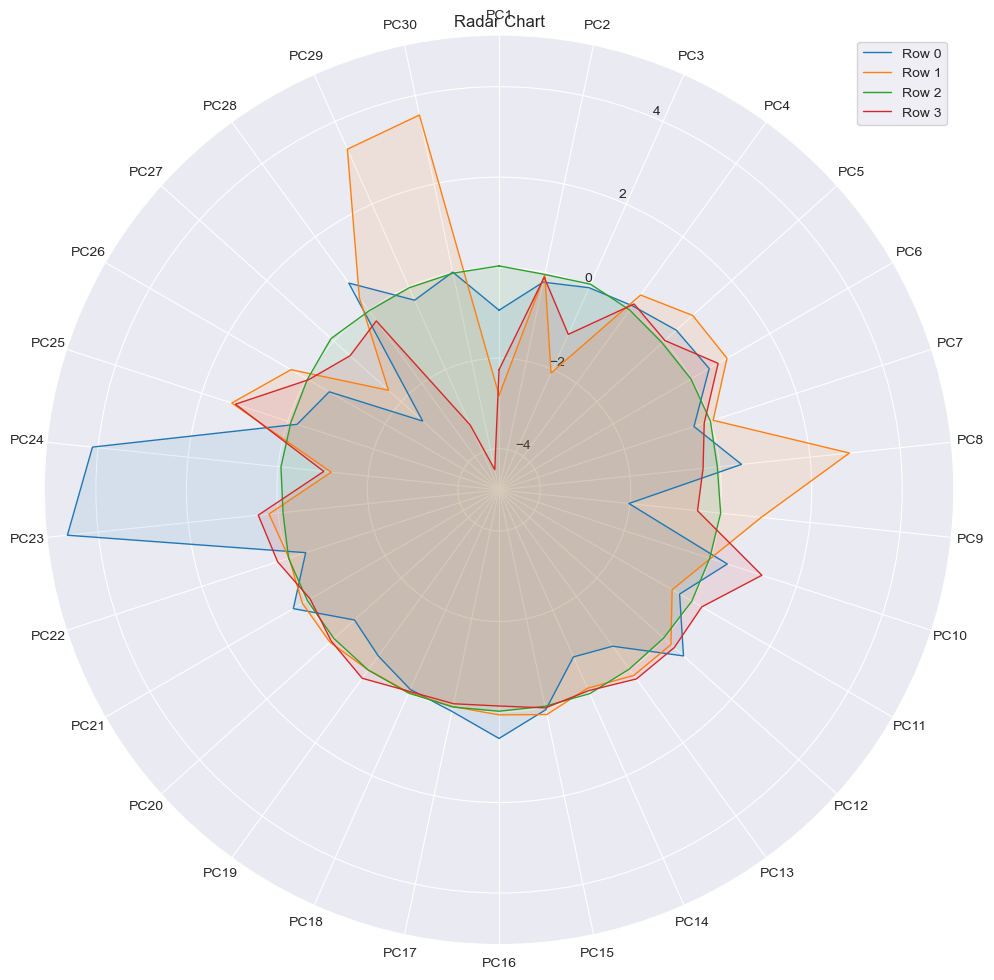

In [133]:
pca30_clusters5, pca30_clusters5_centroids = init_fit_hdbscan_clustering(pca30_result_df, min_cluster_size=10, cluster_selection_epsilon=5.0)
create_radar_chart(pca30_clusters5_centroids)

In [134]:
pca30_clusters5['labels'].value_counts()

labels
 2    17813
 0      358
 1      342
-1      251
 3      180
Name: count, dtype: int64

#### Analysis
This clustering seems more interesting. It appears that the PCA did generalize the binary features, most likely because those were highly correlated. However, the cluster sizes are still really low and after looking at the representation of the component compositions, the binary features problem is still present. For example, cluster 0, PC23 and PC24 are high and these two components are mainly determined by 'preferred_task_type_HIGHLIGHT'

### Custom features
Let's now try to take some well chosen features. We emitted this hypothesis: 'People working during the weekend tends to be hard workers, hence have more active days and spend more time on a session.' We will try to validate or reject it by clustering those features.

In [135]:
X_custom = X_scaled_final_clustering[['active_days', 'weekend_ratio', 'avg_sessions_per_active_day', 'topic_diversity', 'avg_session_duration_min']]

In [136]:
# Initialize the parameters to be tuned
min_cluster_size_list = [10, 30, 50, 70]
cluster_selection_epsilon_list = [0.15, 0.2, 0.25, 0.3]

# Perform hyperparameters tuning for the entire dataset
score_list, nb_clusters_list, nb_outliers_list = run_hdbscan_grid_search(X_custom, min_cluster_size_list, cluster_selection_epsilon_list)

For min_cluster_size=10 and cluster_selection_epsilon=0.15:
	Nb clusters: 44
	Nb outliers: 9576
	Silhouette score: -0.2633079661058202
For min_cluster_size=10 and cluster_selection_epsilon=0.2:
	Nb clusters: 27
	Nb outliers: 8883
	Silhouette score: -0.24314359101441285
For min_cluster_size=10 and cluster_selection_epsilon=0.25:
	Nb clusters: 13
	Nb outliers: 7690
	Silhouette score: -0.11942989527896103
For min_cluster_size=10 and cluster_selection_epsilon=0.3:
	Nb clusters: 8
	Nb outliers: 6272
	Silhouette score: 0.10814772210014725
-----------------------------------
For min_cluster_size=30 and cluster_selection_epsilon=0.15:
	Nb clusters: 19
	Nb outliers: 11958
	Silhouette score: -0.20740382862730025
For min_cluster_size=30 and cluster_selection_epsilon=0.2:
	Nb clusters: 9
	Nb outliers: 11154
	Silhouette score: -0.18561109079333282
For min_cluster_size=30 and cluster_selection_epsilon=0.25:
	Nb clusters: 3
	Nb outliers: 5010
	Silhouette score: 0.399996370322566
For min_cluster_size=

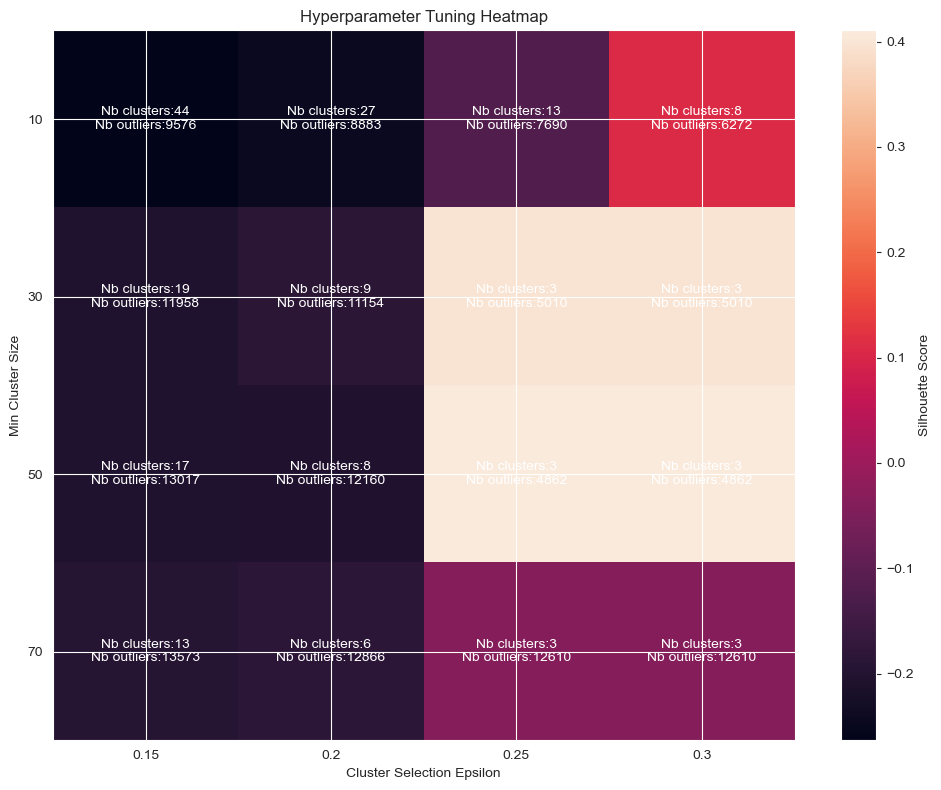

In [137]:
plot_hyperparameter_tuning_heatmap(score_list, min_cluster_size_list, cluster_selection_epsilon_list, nb_clusters_list, nb_outliers_list)

Model fitted. Num of clusters found: 2
Labels and probabilities added


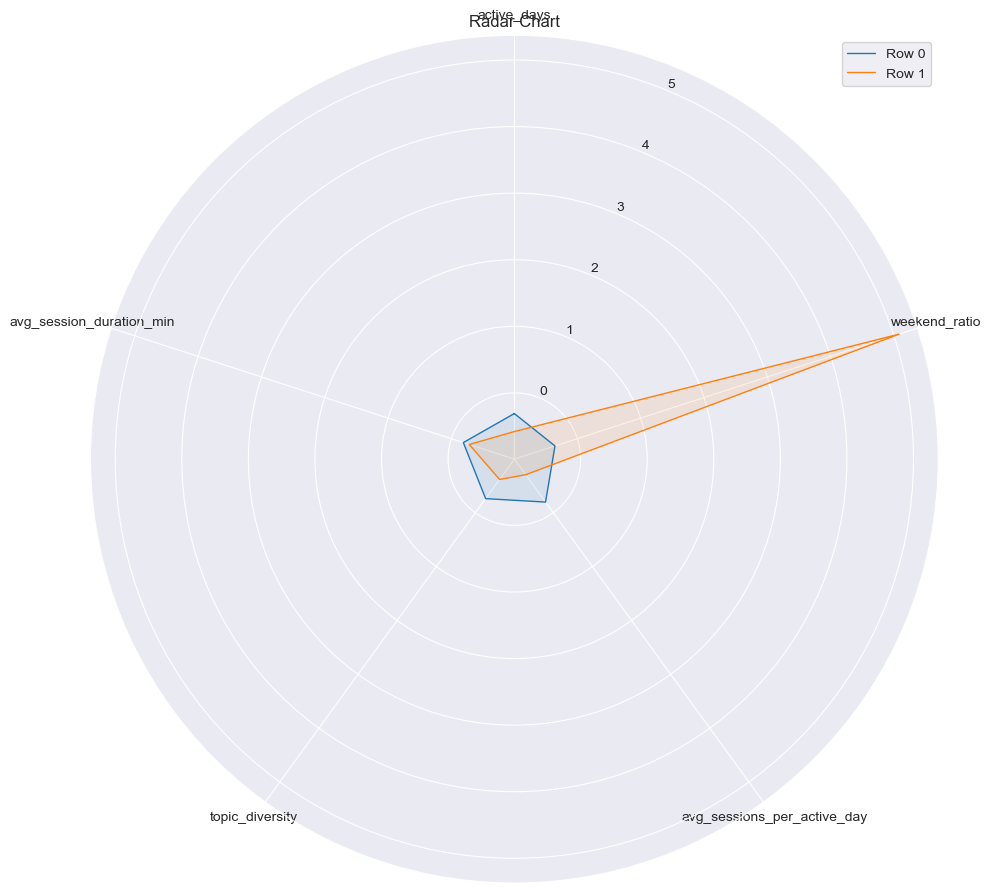

In [138]:
custom_features_clusters3, custom_features_clusters5_centroids = init_fit_hdbscan_clustering(X_custom, min_cluster_size=50, cluster_selection_epsilon=0.25)
create_radar_chart(custom_features_clusters5_centroids)

In [139]:
custom_features_clusters3['labels'].value_counts()

labels
 0    14015
-1     4862
 1       67
Name: count, dtype: int64

#### Analysis
Unfortunately, the same problem occurred. We cannot say anything about our hypothesis since there are way too many outliers and a cluster on 66 people is really not representative.

## Gaussian mixture model

HDBSCAN gave some results. Even if some of the clusters made sense, the results were not really meaningful. Hence, we decided to use another method: Gaussian mixture model. GMM is an upgraded version of kNN, hence there can not be any outliers and the number of clusters are defined by ourselves.

#### For the entire dataset

C:\Users\fleur\miniconda3\envs\DataWhisperers\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Le fichier spécifié est introuvable
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\fleur\miniconda3\envs\DataWhisperers\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\fleur\miniconda3\envs\DataWhisperers\Lib\subprocess.py", line 550, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\fleur\miniconda3\envs\DataWhisperers\Lib\subprocess.py", line 1028, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\fleur\miniconda3\envs\DataW

n_comp: 2, score: 0.4687042062945404
n_comp: 3, score: 0.08792447475616977
n_comp: 4, score: 0.061006613564814426
n_comp: 5, score: 0.063724183934072
n_comp: 6, score: 0.06513502266611054
n_comp: 7, score: 0.10140645336344783
n_comp: 8, score: 0.07553907782180753
n_comp: 9, score: 0.06346835762242037


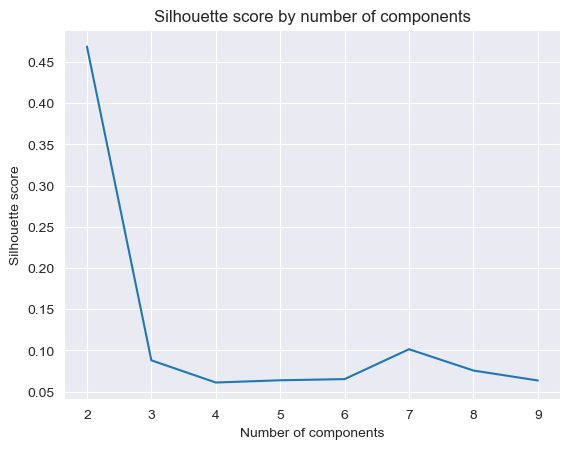

In [140]:
# Let's directly do a grid search on the best number of clusters in function of the silhouette score
grid_search_GMM(X_scaled_final_clustering, range(2,10))

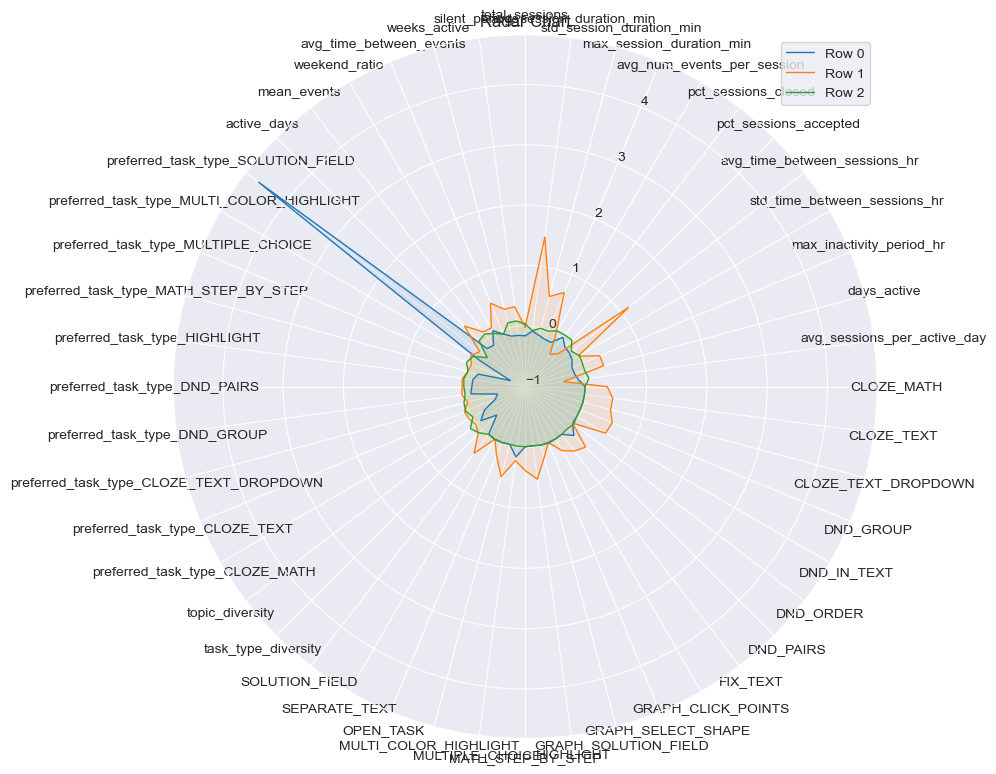

       0
0    753
1    903
2  17288


In [141]:
# We can fit the model with a good number of clusters, plot it and show the number of samples per cluster
fit_and_plot_GMM(X_scaled_final_clustering, 3)

#### Analysis
We can already see an improvement on the number of samples per cluster. For a dataset that suffers a lot from the curse of dimensionality and the binary features, this is not bad at all. We can see that a non negligible number of people are in the cluster 2. This persona is globally explained by people prefering the task type DND_PAIRS and DND_GROUP, having a low topic and task type diversity and those people also have a high average session duration and average time between session, but a low overall number of sessions.
This is a big improvement from HDBSCAN.

### For session features
In order to fix the curse of dimensionality and binary features problems, let's try GMM with the session features.

n_comp: 2, score: 0.06229657772083433
n_comp: 3, score: 0.07773823176659635
n_comp: 4, score: 0.09160986156221228
n_comp: 5, score: 0.057521987824004854
n_comp: 6, score: 0.06666957534429917
n_comp: 7, score: 0.047048501426288414
n_comp: 8, score: 0.028864969762041257
n_comp: 9, score: -0.00648092111800032


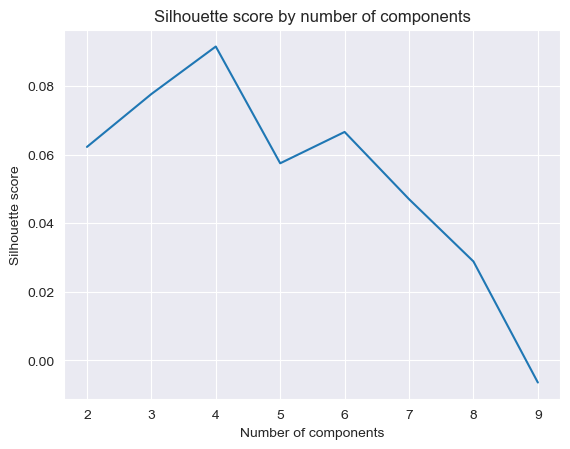

In [142]:
grid_search_GMM(session_scaled_df, range(2,10))

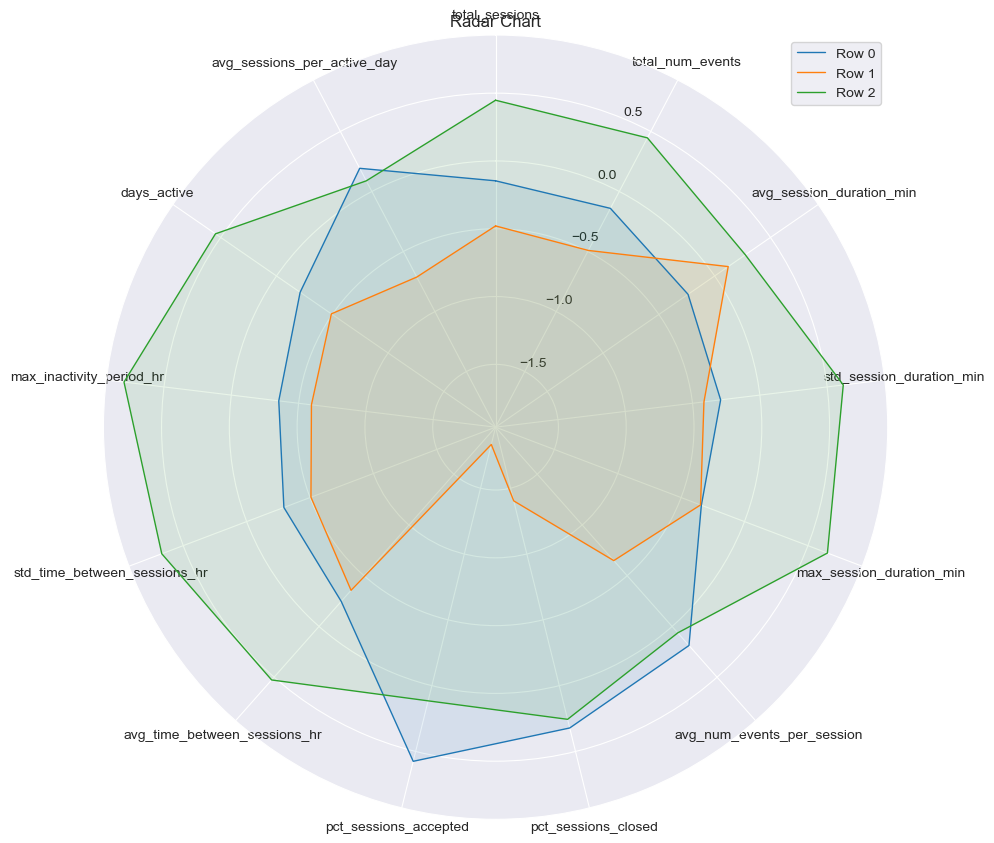

      0
0  9514
1  3400
2  6716


In [143]:
fit_and_plot_GMM(session_scaled_df, 3)

#### Analysis
We finally have a meaningful clustering. Three personas have been extracted by GMM (The order may change):
- First persona: The people in this persona generally have low values for the average time between sessions or average sessions duration. However, they have high values in term of total sessions or average sessions per active day as well as the percentage of session accepted of closed. This persona represents the people doing a lot of sessions.
- Second persona: The people in this persona generally have low values for the number of sessions or average sessions per active days. However, they have high values in term of biggest inactivity period or time between sessions as well as the average session duration. This persona represents the people not doing a lot of sessions but long ones when they do.
- Third persona: The people in this persona generally have low values in the set. They have a low percentage of accepted or closed sessions, a low total number of events or sessions, etc... This persona represents the people not being very active.
This represents a big step. However, let's keep in mind that we have a silhouette score of 0.22 which is not a really good one but stays acceptable.

#### With PCA
It is time to try GMM with PCA in order to cluster the dataset on the principal components.

In [144]:
# We declare and fit the PCA on the dataset
pca10 = PCA(n_components=10)
pca10_result = pca10.fit_transform(X_scaled_final_clustering)
pca10_result_df = pd.DataFrame(pca10_result.T, [f'PC{i+1}' for i in np.arange(10)]).T
pca10_result_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,17.569781,-1.824662,-8.678634,-0.682631,-1.184183,1.421139,0.612461,-1.985799,0.973956,-0.836440
1,14.503061,-0.166535,-4.797083,0.225965,0.074511,-0.160290,-0.306235,-0.833661,-0.175830,-0.885689
2,14.806277,-1.034482,-7.544376,1.737591,-3.522586,0.013071,0.817667,-1.906895,1.143408,-0.760937
3,-1.039394,0.482316,-0.981767,0.451824,-0.548082,0.720363,0.041306,-0.216891,-0.287586,0.212173
4,0.163972,-0.654488,-0.606474,1.097351,-1.054807,-0.622392,0.267624,-0.780184,0.635070,-0.276577
...,...,...,...,...,...,...,...,...,...,...
18939,-2.476631,-0.391075,-0.547444,1.887075,0.454478,-0.345260,0.085313,0.156640,-0.244161,0.040923
18940,-2.660875,-0.142655,-0.647441,1.704210,-0.110138,-0.324313,0.181345,-0.173593,0.025147,-0.071873
18941,-2.089673,-0.459644,0.777452,1.361665,-0.248148,-0.615029,0.151406,-0.384241,0.315846,-0.056089
18942,-2.791423,-0.095011,-1.226336,1.938263,0.223926,-0.209573,0.132271,0.062288,-0.230048,-0.010869


n_comp: 2, score: 0.363065056900873
n_comp: 3, score: -0.017902035701122403
n_comp: 4, score: 0.0030083608448018347
n_comp: 5, score: 0.016505699992138145
n_comp: 6, score: 0.01793757993586325
n_comp: 7, score: 0.03333690679336572
n_comp: 8, score: 0.06003047707761697
n_comp: 9, score: 0.008531146602092208


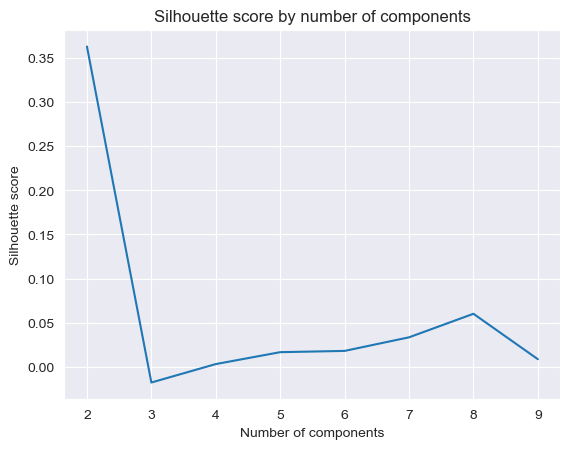

In [145]:
# Perform a grid search
grid_search_GMM(pca10_result_df, range(2,10))

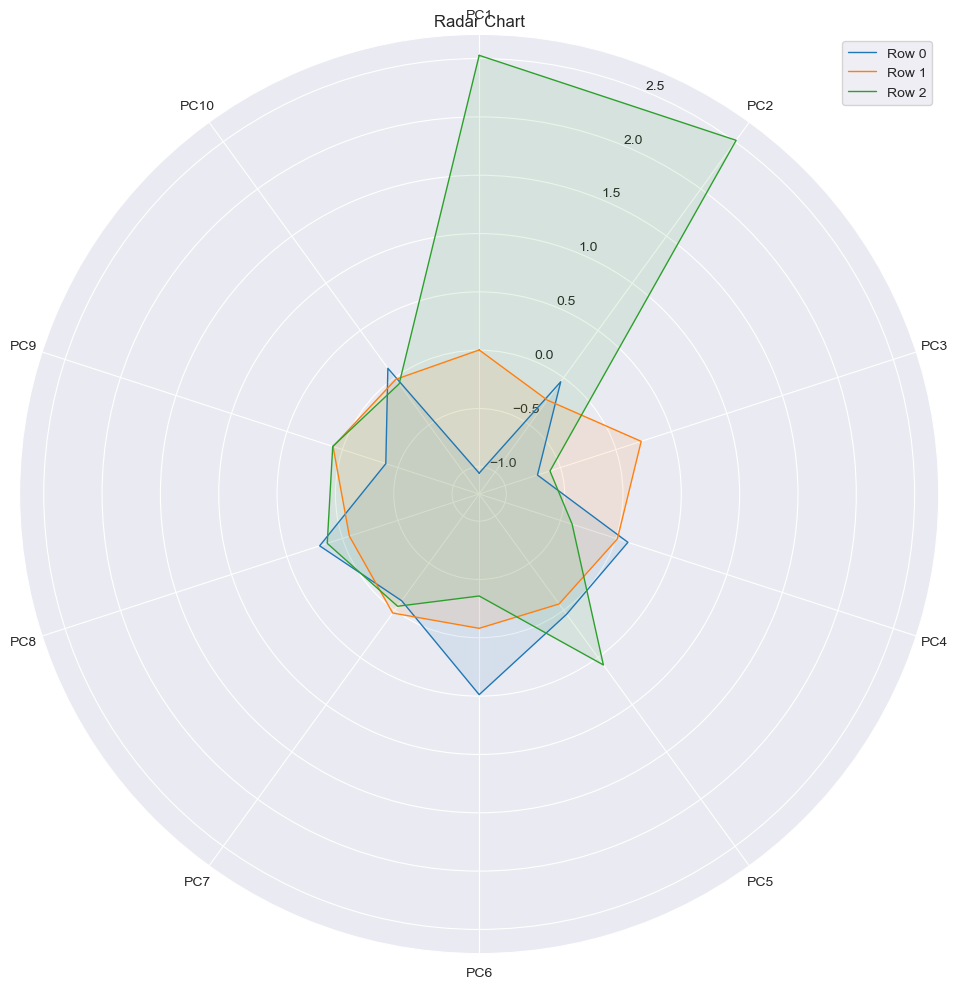

       0
0   3390
1  14166
2   1388


In [146]:
# Plot the centroids
fit_and_plot_GMM(pca10_result_df, 3)

Here are the biggest weigths of the principal components (Order can change):
- PC1: most represented by weeks_active, active_days, mean_events, days_active and silent_periods
- PC2: most represented by std_session_duration_min, std_time_between_sessions_hr, max_session_duration_min, avg_time_between_sessions_hr, max_inactivity_period_hr and avg_session_duration_min
- PC3: most represented by pct_sessions_accepted, pct_sessions_closed and avg_sessions_per_active_day
- PC6: most represented by preferred_task_type_CLOZE_TEXT_DROPDOWN

Unfortunately, we still have a 'main cluster' which groups a lot of samples. However, we can see some patterns in the others:
- The first persona represents the people having high active days or weeks and high time between sessions or session duration. They are doing long sessions from a long time
- The second persona represents the people having low active days or weeks as well as a low percentage of sessions accepted and average number of sessions per active days. They are apparently not very active.

#### For custom features
Remember our previous hypothesis: 'People working during the weekend tends to be hard workers, hence have more active days and spend more time on a session.' We will now try again to validate or reject it by clustering those features with GMM.

In [147]:
X_scaled_final_clustering.head()

,total_sessions,avg_session_duration_min,std_session_duration_min,max_session_duration_min,avg_num_events_per_session,pct_sessions_closed,pct_sessions_accepted,avg_time_between_sessions_hr,std_time_between_sessions_hr,max_inactivity_period_hr,...,preferred_task_type_MATH_STEP_BY_STEP,preferred_task_type_MULTIPLE_CHOICE,preferred_task_type_MULTI_COLOR_HIGHLIGHT,preferred_task_type_SOLUTION_FIELD,active_days,mean_events,weekend_ratio,avg_time_between_events,weeks_active,silent_periods
0,2.178260,0.040976,1.091944,3.761500,0.114304,0.591600,0.156031,-0.027532,0.017587,0.189341,...,-0.206675,-0.747050,-0.140517,-0.219128,11.997447,5.806972,-0.183118,-0.325153,8.649997,6.477566
1,2.445658,0.468185,1.881149,4.092042,-0.519263,0.598772,0.574557,-0.088120,0.066162,0.865307,...,-0.206675,-0.747050,-0.140517,4.563537,6.115191,3.930310,0.603994,-0.304138,6.354716,8.630960
2,0.841269,0.013797,0.529834,1.386367,-0.154392,0.648977,0.574557,0.226730,0.463874,0.832133,...,-0.206675,1.338598,-0.140517,-0.219128,10.335071,2.354826,0.291138,-0.243549,9.415091,6.908245
3,-0.362023,-0.291957,-0.415370,-0.485347,-0.818458,-0.154303,0.574557,0.272961,0.168855,-0.102089,...,4.838508,-0.747050,-0.140517,-0.219128,-0.150690,-0.360828,0.061465,1.484182,-0.021065,0.448063
4,-0.451156,-0.291734,-0.415368,-0.485275,0.643939,0.648977,0.574557,-0.355972,-0.507214,-0.595344,...,-0.206675,1.338598,-0.140517,-0.219128,0.744436,0.046646,0.378964,0.410925,0.999060,0.878742


In [148]:
X_custom_GMM = X_scaled_final_df[['active_days', 'weekend_ratio', 'avg_sessions_per_active_day', 'topic_diversity', 'avg_session_duration_min']].dropna()
user_ids_custom = X_scaled_final_df['user_id']

n_comp: 2, score: 0.24735939416368485
n_comp: 3, score: 0.19079929377621457
n_comp: 4, score: 0.012845060229304988
n_comp: 5, score: 0.18251610883244201
n_comp: 6, score: 0.04161977296229169
n_comp: 7, score: 0.04629134487368531
n_comp: 8, score: 0.014946503286113223
n_comp: 9, score: 0.03868279114279336


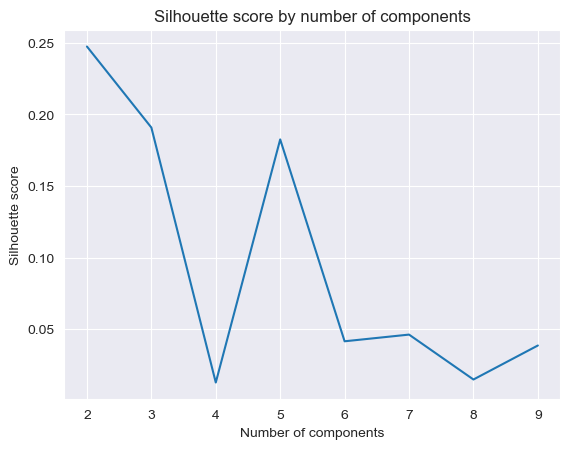

In [149]:
grid_search_GMM(X_custom_GMM, range(2,10))

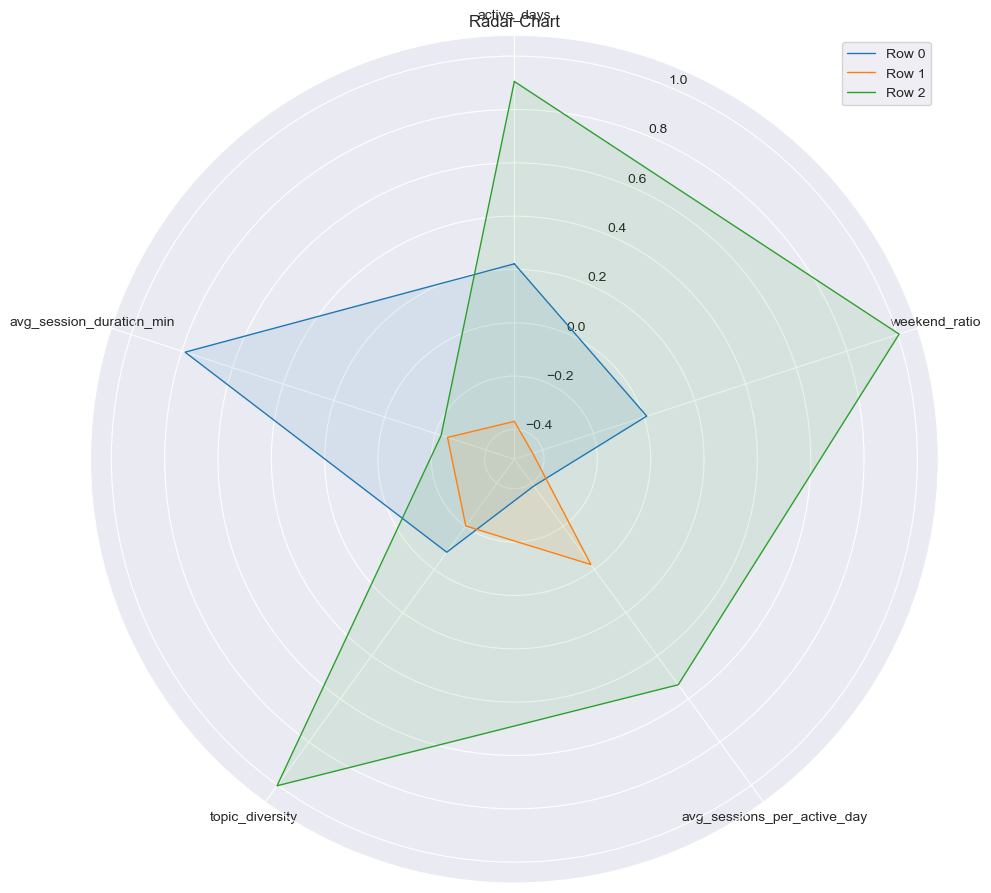

      0
0  4531
1  9980
2  4433


In [150]:
fit_and_plot_GMM(X_custom_GMM, 3)

#### Analysis
We first see that the samples are well distributed whitin the cluster. A silhouette score of 0.21 is really not crazy but is still acceptable. Let's first describe all the personas we found (order can change):
- Persona 1: People in this persona have some high values. They have a lot of active days, high weekend ratio and topic diversity. However, they have a low average session duration. This persona could represent studious students doing a lot of short sessions on many topics, even during the weekend.
- Persona 2: In this persona, people have some standard values, apart form the average session duration, which is very high, and the average session per active day, which is very low. This persona could represent people doing a few sessions but long ones when they do.
- Persona 3: This is the biggest persona. In this persona, values are relatively low. Very low weekend ratio, active days, average session duration and topic diversity. The average sessions number per active day is the only value in the mean. They are most likely the students that do not engaged much in the platform and do only when it is mandatory.

Hence, we can conclude that the hypothesis is not completely true. People working on weekends tends indeed to have more active days than the others. However, the persona 2, containing a lot of people, have a high weekend ratio but a low average session duration. People in this persona tends to work on the weekend but do a lot of short sessions.

### Add evaluation to the sessions features
Before, we saw a fascinating clustering with the sessions data. Now, let's analyse the performance of each cluster in order to unraveling the best behaviors.

In [151]:
# We get the eval for each user
eva_df = (
    transactions.groupby(['user_id']).agg(
        correct_ratio=('evaluation', lambda x: ((x == 'CORRECT').sum() + 0.5*(x == 'PARTIAL').sum()) / x.count())
    )
    .reset_index()
)

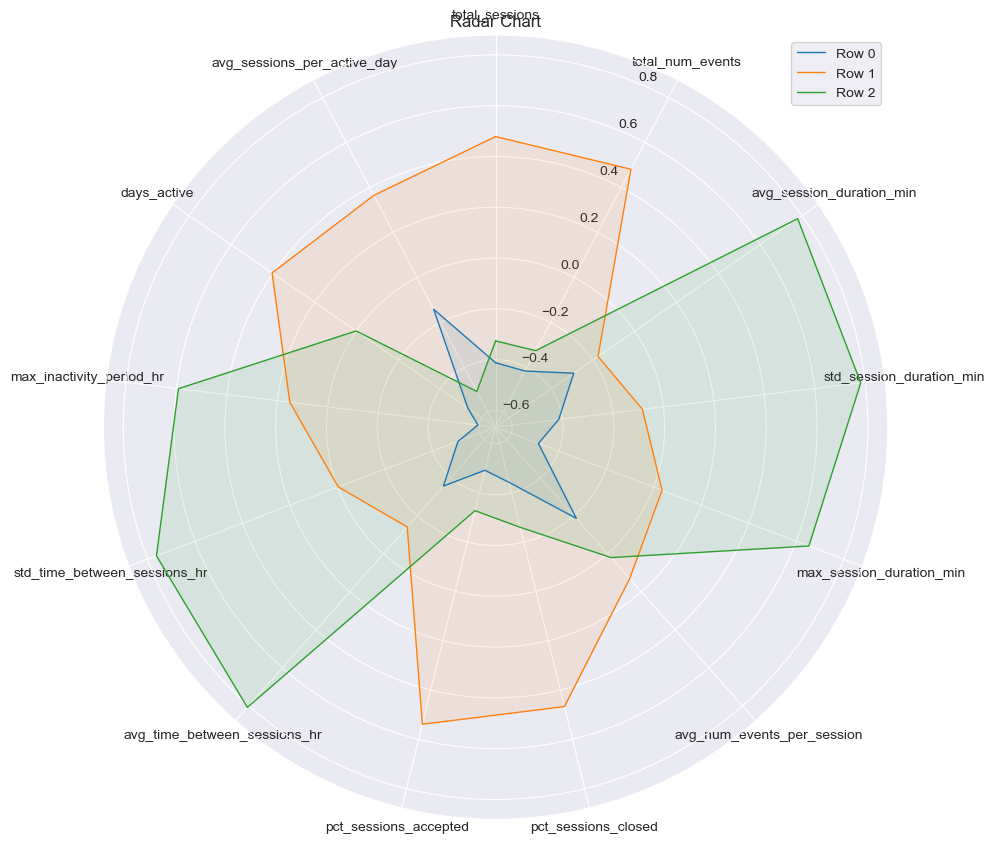

      0
0  6567
1  8672
2  4391


In [152]:
# We cluster the data again
gm = GaussianMixture(n_components=3, random_state=43).fit(session_scaled_df)
clusters = pd.DataFrame(gm.means_)
clusters.columns = session_scaled_df.columns
create_radar_chart(clusters)
print(pd.DataFrame(np.unique_counts(gm.predict(session_scaled_df)).counts))

In [153]:
# We infer the labels and the user ids
labels = gm.predict(session_scaled_df)
labels_df = session_scaled_df.copy()
labels_df['label'] = labels
labels_df['user_id'] = user_ids_session

lab_eva_df = pd.merge(left=labels_df, right=eva_df, on='user_id', how='outer')

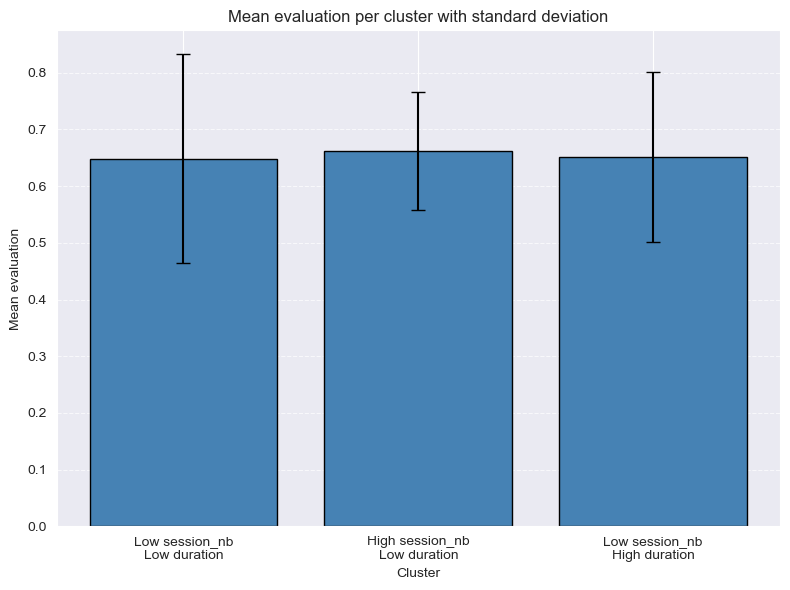

In [154]:
# Compute the performances, number of sessions and duration, standard deviation and mean
mean_std_df = lab_eva_df[['correct_ratio', 'label', 'total_sessions', 'avg_session_duration_min']].groupby(['label']).agg(
    result_std=('correct_ratio', 'std'),
    result_mean=('correct_ratio', 'mean'),
    nb_sessions_mean=('total_sessions', 'mean'),
    nb_sessions_std=('total_sessions', 'std'),
    duration_mean=('avg_session_duration_min', 'mean'),
    duration_std=('avg_session_duration_min', 'std')
).reset_index()

# Name the rows
mean_std_df['name'] = ['Low session_nb\nLow duration', 'High session_nb\nLow duration', 'Low session_nb\nHigh duration']

# Plotting
plt.figure(figsize=(8, 6))
plt.bar(mean_std_df['label'], mean_std_df['result_mean'], yerr=mean_std_df['result_std'], capsize=5, color='steelblue', edgecolor='black')
plt.xlabel('Cluster')
plt.ylabel('Mean evaluation')
plt.title('Mean evaluation per cluster with standard deviation')
plt.xticks(mean_std_df['label'], mean_std_df['name'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Analysis
We see that the performance differences are negligible among the clusters. The mean stands around 0.66 (Remember: CORRECT = 1, PARTIAL = 0.5, WRONG = 0). However, the standard deviation is a little more changing. People doing a low number of quick sessions tend to be quite unstable. It could be explained by the fact that this cluster probably contains the students not being really interested by the platform and thus having a bad evaluation and the people doing quick tests on the platform (like professors) having good evaluation. On the contrary, the people present in the cluster having a high number of quick sessions tend to be more constant in their evaluations.

However, since this is difficult to make the difference between professors and students, we cannot really conclude anything from this graph.

### Add evaluation to the custom features

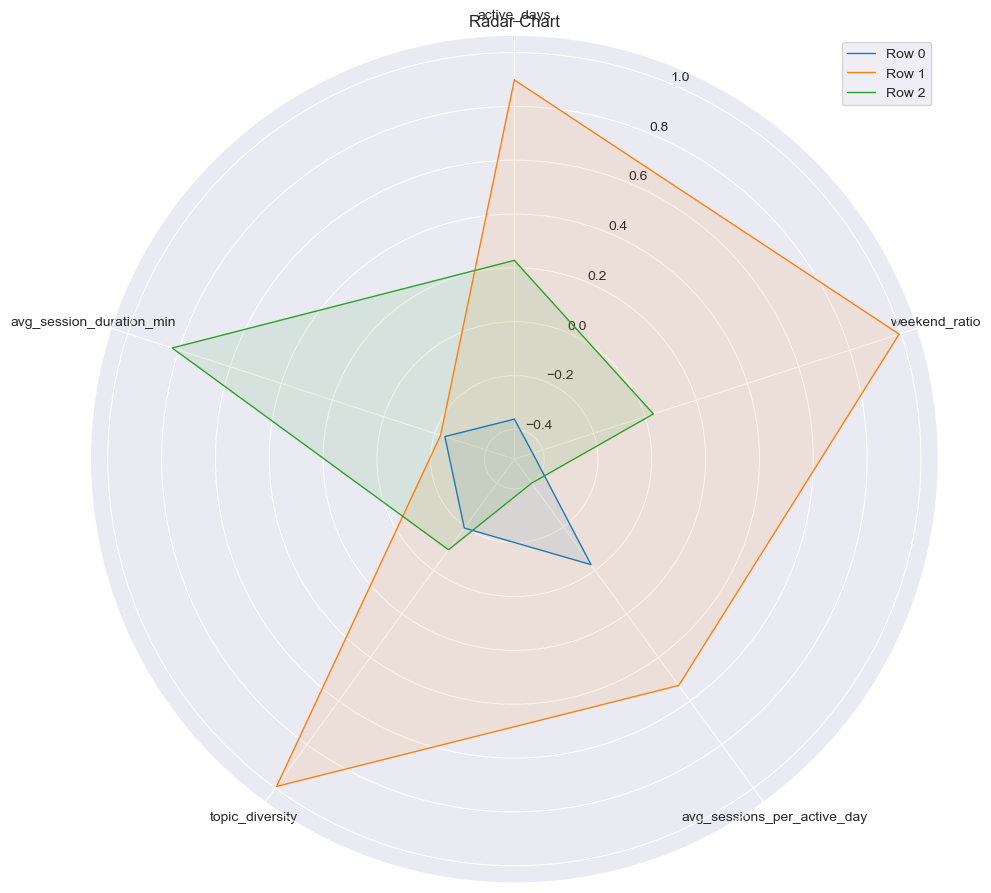

       0
0  10176
1   4504
2   4264
Silhouette score: 0.17791478956088697


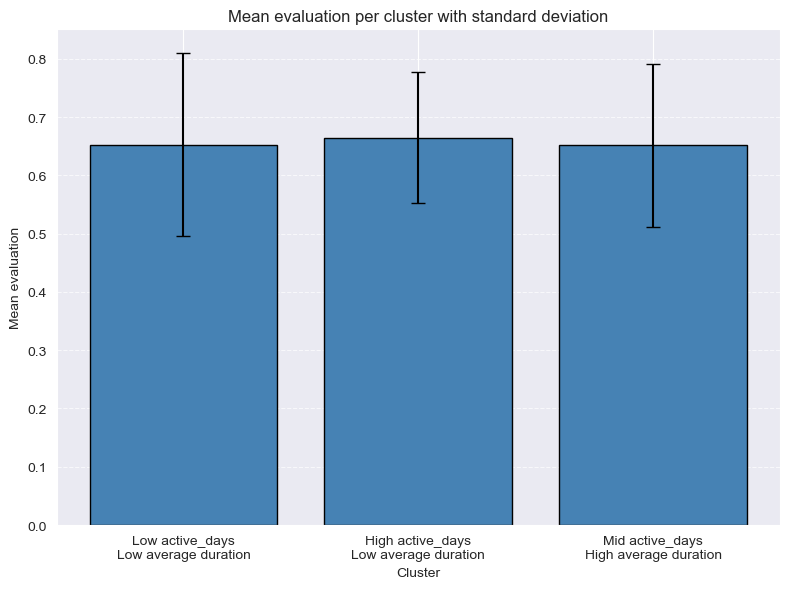

In [155]:
# We cluster the data again
gm = GaussianMixture(n_components=3, random_state=42).fit(X_custom_GMM)
clusters = pd.DataFrame(gm.means_)
clusters.columns = X_custom_GMM.columns
create_radar_chart(clusters)
print(pd.DataFrame(np.unique_counts(gm.predict(X_custom_GMM)).counts))

# We infer the labels and the user ids
labels = gm.predict(X_custom_GMM)
labels_df = X_custom_GMM.copy()
labels_df['label'] = labels
labels_df['user_id'] = user_ids_custom

print(f'Silhouette score: {silhouette_score(X_custom_GMM, labels)}')

lab_eva_df = pd.merge(left=labels_df, right=eva_df, on='user_id', how='outer')

# Compute the performances, number of sessions and duration, standard deviation and mean
mean_std_df = lab_eva_df[['correct_ratio', 'label', 'weekend_ratio', 'avg_session_duration_min']].groupby(['label']).agg(
    result_std=('correct_ratio', 'std'),
    result_mean=('correct_ratio', 'mean'),
    nb_sessions_mean=('weekend_ratio', 'mean'),
    nb_sessions_std=('weekend_ratio', 'std'),
    duration_mean=('avg_session_duration_min', 'mean'),
    duration_std=('avg_session_duration_min', 'std')
).reset_index()

# Name the rows
mean_std_df['name'] = ['Low active_days\nLow average duration', 'High active_days\nLow average duration', 'Mid active_days\nHigh average duration']

# Plotting
plt.figure(figsize=(8, 6))
plt.bar(mean_std_df['label'], mean_std_df['result_mean'], yerr=mean_std_df['result_std'], capsize=5, color='steelblue', edgecolor='black')
plt.xlabel('Cluster')
plt.ylabel('Mean evaluation')
plt.title('Mean evaluation per cluster with standard deviation')
plt.xticks(mean_std_df['label'], mean_std_df['name'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Analyse
Unfortunately, nothing can be concluded with the evaluation of the people in the clusters. All means stand at around 0.66 and the standard deviation is not remarkable.

### 4.2 Clustering for RQ2 (DTW, Spectral, HMM)


The approach for this research question is to use Dynamic Time Warping (DTW) clustering to identify student clusters based on their behavioral sequences. To tackle this task, we use Kmeans clustering with DTW as the distance metric. An important parameter is the k of kmeans. A grid search on k ranging from 2 to 9 (included) was run and the one with the best silhouette score is selected.

In [156]:
# this cell takes a few hours (2h32 in the previous run) to run, do not unccoment the following line unless you want to recompute the matrix.
# distance_matrix = cdist_dtw(df_q1)
# np.save('distance_matrix_all_feat.npy', distance_matrix)

In [158]:
# result of previous cell is saved in a file, we can load it here.
distance_matrix = np.load('distance_matrix_all_feat.npy')

In [159]:
# this cell takes a few hours (16h24 in the previous run) to run, do not uncomment the following line unless you want to recompute the grid search.
# grid_search_dtw(list(np.arange(2, 10)), 50, 4, df_q1, distance_matrix)

In [160]:
# this is the grid search result obtained in the previous cell.
grid_search_results = [np.float64(0.5498242626277999),
 np.float64(0.5536233546750368),
 np.float64(0.355717416195596),
 np.float64(0.3679833751081339),
 np.float64(0.2177929131378528),
 np.float64(0.3758529399939967),
 np.float64(0.2488927168661695),
 np.float64(0.2594434057755429)]

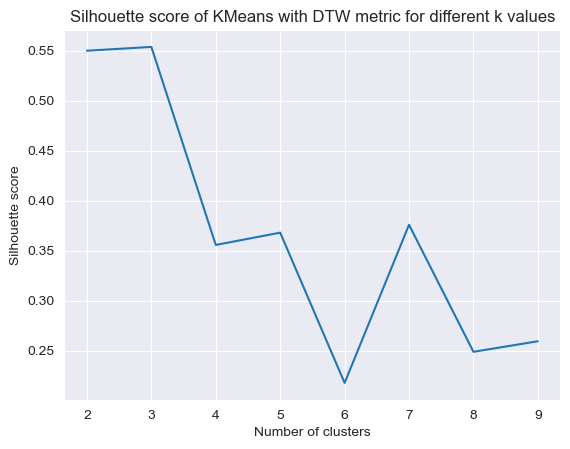

In [161]:
import matplotlib.pyplot as plt
plt.plot(list(range(2, 10)), grid_search_results)
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.title('Silhouette score of KMeans with DTW metric for different k values')
plt.show()


we can see that the best silhouette score is obtained with 3 clusters. So the following analyses are done with k=3. (However, it isn't much higher than 2 clusters)

In [162]:
from tslearn.clustering import TimeSeriesKMeans

model = TimeSeriesKMeans(n_clusters=3, metric="dtw",
                         max_iter=10, n_init=4)

In [163]:
preds = model.fit_predict(df_q1)

C:\Users\fleur\miniconda3\envs\DataWhisperers\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\fleur\miniconda3\envs\DataWhisperers\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [164]:
len(preds)

13725

In [165]:
labels_unique, counts = np.unique(preds, return_counts=True)

for label, count in zip(labels_unique, counts):
    print(f'Cluster {label}: {count} samples')

Cluster 0: 11169 samples
Cluster 1: 2094 samples
Cluster 2: 462 samples


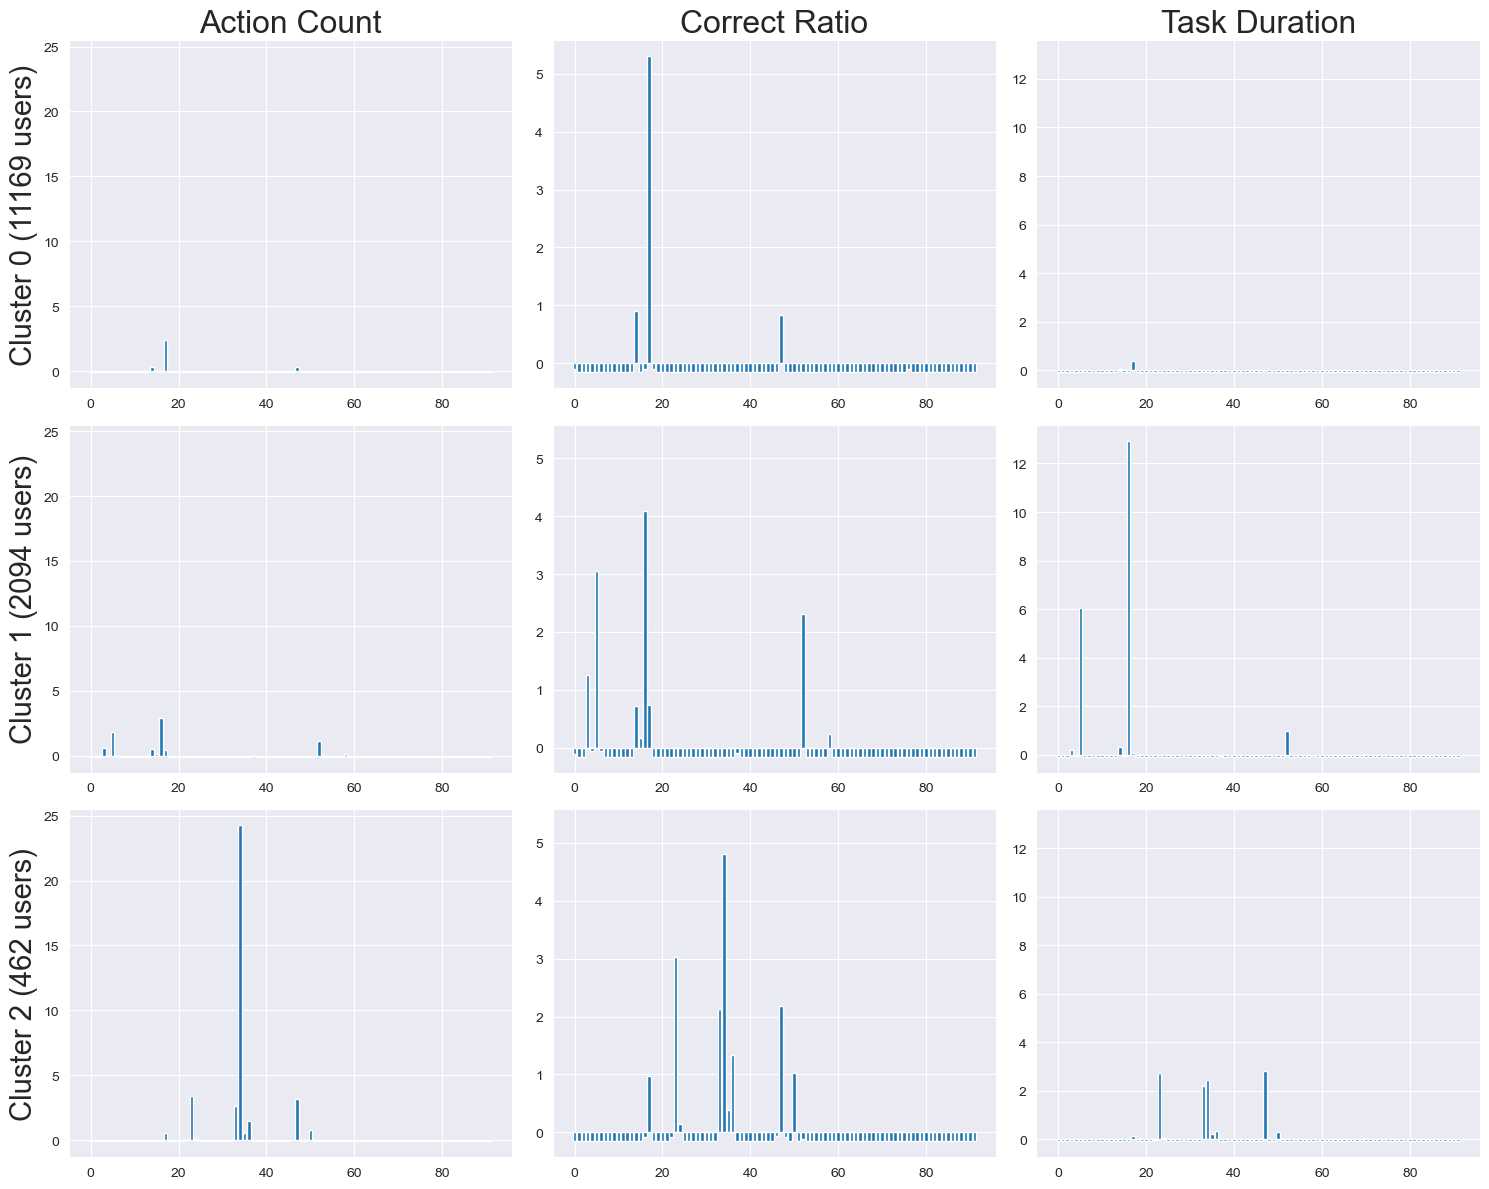

In [166]:
n_clusters = len(model.cluster_centers_)
n_features = len(model.cluster_centers_[0])
n_dims = len(model.cluster_centers_[0][0])

fig, axes = plt.subplots(n_clusters, n_dims, figsize=(5 * n_dims, 4 * n_clusters), sharey='col')
#plt.rcParams.update({'font.size': 16})

feature_names = ['Action Count', 'Correct Ratio', 'Task Duration']

row_names = [f'Cluster {label} ({count} users)' for label, count in zip(labels_unique, counts)]

for cluster_idx, cluster in enumerate(row_names):
    axes[cluster_idx, 0].set_ylabel(cluster, fontsize=21)
for feature_idx, feature in enumerate(feature_names):
    axes[0, feature_idx].set_title(feature, fontsize=23)

for cluster_idx in range(n_clusters):
    for dim_idx in range(n_dims):
        row = model.cluster_centers_[cluster_idx]
        values = [i[dim_idx] for i in row]
        ax = axes[cluster_idx, dim_idx]
        ax.bar(range(len(values)), values)

plt.tight_layout()
plt.show()

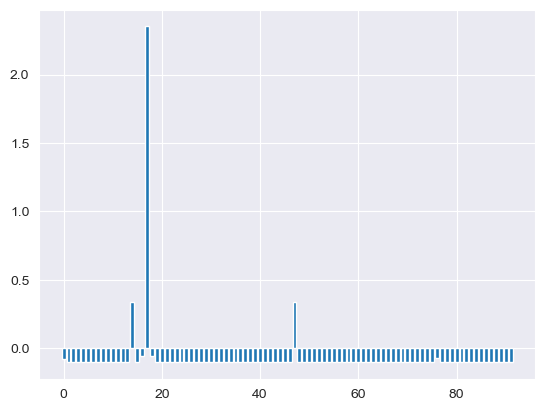

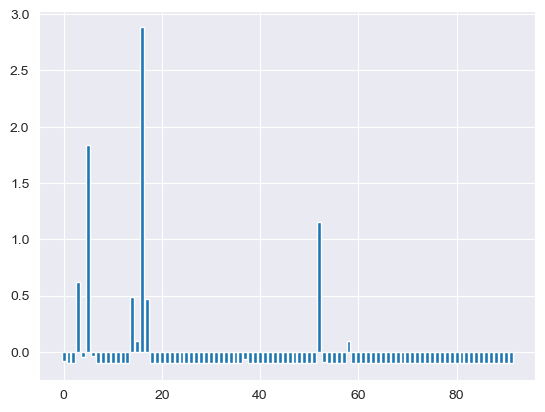

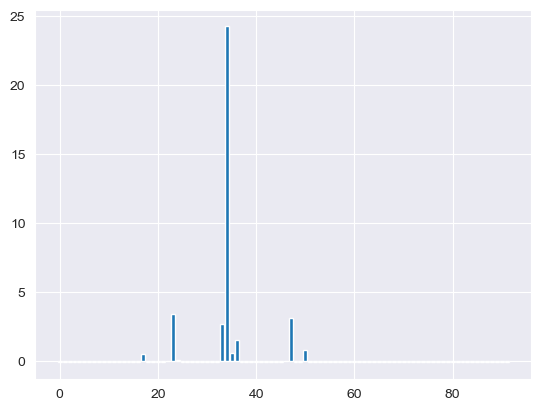

In [168]:
for row in model.cluster_centers_:
    row = [i[0] for i in row]
    plt.bar(list(range(len(row))), row)
    plt.show()

### 4.2 Supervised Prediction for RQ3 (RF, LR, LSTM)

For RQ3, we tried to predict the performance of a user through the time using LSTM.

In [169]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
#from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input

We prepare the data

In [170]:
data = df_q1

n_samples, n_timesteps, n_features = data.shape
scaled_data = np.zeros_like(data)

for feature in range(n_features):
    # Reshape to 2D for scaling
    feature_data = data[:, :, feature].reshape(-1, 1)

    # Scale the feature
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_feature = scaler.fit_transform(feature_data)

    # Reshape back and assign
    scaled_data[:, :, feature] = scaled_feature.reshape(n_samples, n_timesteps)

We take a window size of 40 and we prepare the test/train data

In [171]:
# Set window size
window_size = 40

# Set target for training
X = []
y = []
target_dates = np.arange(data.shape[1])[window_size:]

# Fill the input/output arrays
for sample_id in range(scaled_data.shape[0]):
    for i in range(window_size, scaled_data.shape[1]):
        X.append(scaled_data[sample_id, i - window_size:i])
        y.append(scaled_data[sample_id, i, 1])

X = np.array(X)
y = np.array(y)

# Split in test/train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

dates_train, dates_test = train_test_split(target_dates, test_size=0.2, shuffle=False)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 3))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 3))

In [172]:
print(f'y: {y.shape}')
print(f'X: {X.shape}')
print(f'target_dates: {target_dates.shape}')

y: (713700,)
X: (713700, 40, 3)
target_dates: (52,)


We declare the LSTMs

In [173]:
model = Sequential()
model.add(Input(shape=(X_train.shape[1], 3)))
model.add(LSTM(units=128, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=128))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

In [174]:
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_train.shape}')

y_train: (570960,)
X_test: (570960, 40, 3)


We fit it and evaluate it

In [175]:
history = model.fit(X_train[:1000], y_train[:1000], epochs=20, batch_size=32, validation_split=0.1)
print('Model fitted')

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0039 - val_loss: 0.0026
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0055 - val_loss: 0.0029
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0062 - val_loss: 0.0026
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0053 - val_loss: 0.0027
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0029 - val_loss: 0.0026
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0048 - val_loss: 0.0027
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0071 - val_loss: 0.0026
Epoch 9/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0040 - val_loss: 0.0026
Epoch 10/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0071 - val_loss: 0.0026
Epoch 11/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0072 - val_loss: 0.0025
Epoch 12/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0

In [176]:
X_sample_test = []
y_sample_test = []
sample_id = 6500

for i in range(window_size, scaled_data.shape[1]):
        X_sample_test.append(scaled_data[sample_id, i - window_size:i])
        y_sample_test.append(scaled_data[sample_id, i, 1])

X_sample_test = np.array(X_sample_test)
y_sample_test = np.array(y_sample_test)

In [177]:
predictions = model.predict(X_sample_test)
print('Predictions made')

rmse = np.sqrt(np.mean((y_sample_test - predictions)**2))
print(f'RMSE: {rmse:.2f}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
Predictions made
RMSE: 0.05


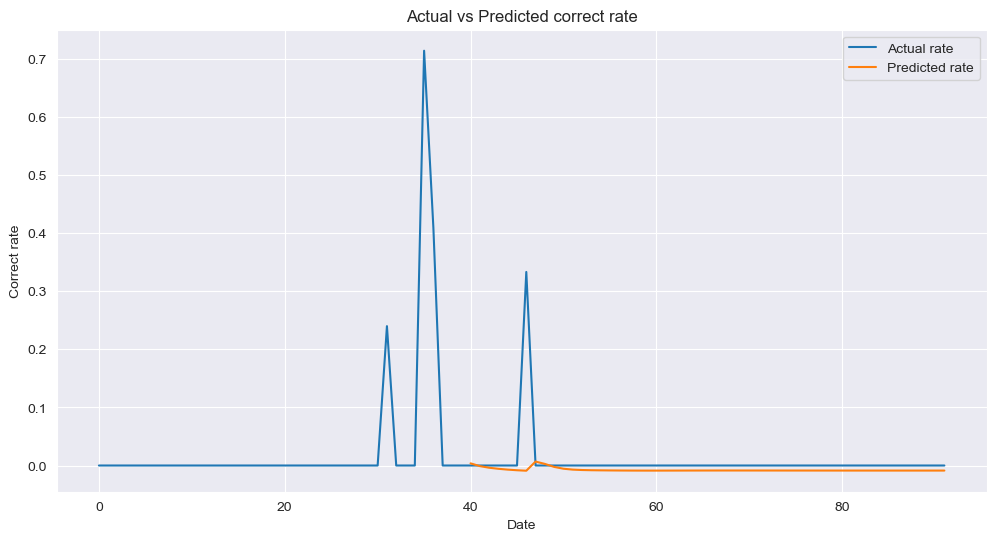

In [178]:
plt.figure(figsize=(12, 6))
#plt.plot(range(window_size, scaled_data.shape[1]), y_sample_test, label='Actual rate')
plt.plot(scaled_data[sample_id, :, 1], label='Actual rate')
plt.plot(range(window_size, scaled_data.shape[1]), predictions, label='Predicted rate')
plt.title('Actual vs Predicted correct rate')
plt.xlabel('Date')
plt.ylabel('Correct rate')
plt.legend()
plt.show()

### Analysis
We cannot see a lot on the graph and for now, the results are too random. Moreover, this RQ was not really related to the other and so we decided to stop our progress here.

## 6. Conclusion
### Insights
The key insight we extracted from this data is the finding of some distinct clusters.
- With GMM on session features, we found three personas: The persona representing the users who is not very active on the plateform, with a low number of quick sessions, the persona representing users who tend to do a lot of sessions but quick ones, and the persona representing users who, on the contrary, tend to do a small number of sessions but long ones when they do.

- With GMM on custom features, we found some similar results: People working infrequently and quickly, people working frequently and quickly, who seem to work also during the weekend and cover many topics, and people working with long sessions.

- With DTW, we found a persona representing people that do a
relatively low amount of action spread over a long
time, however they are making long sessions. Users in the second persona show a high number
of actions, also spread over time. Their task duration
is much shorter than that of Persona 0, but their
performance is similar. The last persona is characterized by a low num-
ber of actions and short task durations. They also have
a single peak, indicating low activity on the platform.
### Next steps
This project is now finished, although, a lot of improvement potential remmain. First, we could continue the work with GMMs. We only analyzed some subsets of all the possibilites in the data. A lot of feature combinations stay to be viewed.
Second, we can continue on dropout prediction. This RQ did not really represented our main work, hence we decided to give this up. However, the first results gave a little something, hence with more work on the data choice, preprocessing and LSTM implementation, we could go toward some useful predictions.